## 9.3 Python Preparation Layer

The purpose of this step is to prepare the daily analytical files for Python-based analysis, data quality assessment, exploratory data analysis, feature engineering, and forecasting.

At this stage, the data has already been converted from Parquet to CSV, prepared at the daily product-store-date level, and loaded into MySQL for validation. The Python preparation layer focuses on making sure the daily analytical data is correctly loaded, properly typed, sorted chronologically, and structured for downstream analytical work.

In [2]:
import pandas as pd
from pathlib import Path

# Define project folders
project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

print("Project folder:", project_folder)
print("Processed folder:", processed_folder)

Project folder: C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail
Processed folder: C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail\processed


### 9.3.1 Load Prepared Daily Files

The prepared daily CSV files are loaded into Python. These files represent the daily analytical layer created earlier from the original FreshRetailNet-50K dataset.

The training file will be used for historical analysis, data quality assessment, EDA, feature engineering, and forecasting model development. The evaluation file will be kept as a future-period dataset for later validation and forecasting assessment.

In [3]:
import pandas as pd
from pathlib import Path

processed_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail\processed")

daily_train = pd.read_csv(processed_folder / "freshretail_daily_train.csv")
daily_eval = pd.read_csv(processed_folder / "freshretail_daily_eval.csv")

print("Daily train shape:", daily_train.shape)
print("Daily eval shape:", daily_eval.shape)

display(daily_train.head())

Daily train shape: (4500000, 17)
Daily eval shape: (350000, 17)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,0,1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,1,1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,0,1.0,1,0,2.0942,15.91,76.47,1.73
3,0,0,0,5,6,65,38,2024-03-31,0.1,11,1.0,1,0,1.5618,16.13,77.40,1.76
4,0,0,0,5,6,65,38,2024-04-01,0.2,8,1.0,0,0,3.5386,15.37,78.26,1.25


### 9.3.2 Convert Date Column

The `dt` column is converted from text format into a proper datetime format. This is necessary for time series analysis, date filtering, trend analysis, backtesting, and forecasting workflows.

Correct date formatting is especially important because the project depends on chronological order and time-based validation.

In [4]:
daily_train["dt"] = pd.to_datetime(daily_train["dt"])
daily_eval["dt"] = pd.to_datetime(daily_eval["dt"])

print("Train date range:", daily_train["dt"].min(), "to", daily_train["dt"].max())
print("Eval date range:", daily_eval["dt"].min(), "to", daily_eval["dt"].max())

Train date range: 2024-03-28 00:00:00 to 2024-06-25 00:00:00
Eval date range: 2024-06-26 00:00:00 to 2024-07-02 00:00:00


### 9.3.3 Sort Data by Store, Product, and Date

The data is sorted by `store_id`, `product_id`, and `dt`.

This ordering is important because the project will later create time-dependent features such as lag variables and rolling averages. Sorting ensures that each product-store time series is arranged chronologically before feature engineering and forecasting.

In [5]:
daily_train = daily_train.sort_values(
    by=["store_id", "product_id", "dt"]
).reset_index(drop=True)

daily_eval = daily_eval.sort_values(
    by=["store_id", "product_id", "dt"]
).reset_index(drop=True)

display(daily_train.head())

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,2,29,78,82,4,2024-03-28,0.5,13,0.882,0,1,1.6999,15.48,73.54,1.97
1,0,0,2,29,78,82,4,2024-03-29,1.3,5,0.882,0,1,3.0190,15.08,76.56,1.71
2,0,0,2,29,78,82,4,2024-03-30,5.3,0,0.882,1,1,2.0942,15.91,76.47,1.73
3,0,0,2,29,78,82,4,2024-03-31,4.2,0,0.879,1,1,1.5618,16.13,77.40,1.76
4,0,0,2,29,78,82,4,2024-04-01,0.7,0,0.882,0,1,3.5386,15.37,78.26,1.25


### 9.3.4 Confirm Product-Store-Date Grain

The dataset is expected to be structured at the product-store-date grain.

This means that each row should represent one unique combination of:

`store_id + product_id + dt`

A duplicate check is performed to confirm that there are no repeated rows at this analytical grain.

In [6]:
train_grain_duplicates = daily_train.duplicated(
    subset=["store_id", "product_id", "dt"]
).sum()

eval_grain_duplicates = daily_eval.duplicated(
    subset=["store_id", "product_id", "dt"]
).sum()

print("Train duplicate store-product-date rows:", train_grain_duplicates)
print("Eval duplicate store-product-date rows:", eval_grain_duplicates)

Train duplicate store-product-date rows: 0
Eval duplicate store-product-date rows: 0


### 9.3.5 Review Final Data Types

The final data types are reviewed to confirm that the dataset is ready for downstream analysis.

The expected structure is:

- `dt` as datetime
- identifier columns as integers
- `sale_amount` as numeric
- `stock_hour6_22_cnt` as integer
- `discount` as numeric
- binary flags as integer
- weather variables as numeric

In [7]:
daily_train.dtypes

city_id                         int64
store_id                        int64
management_group_id             int64
first_category_id               int64
second_category_id              int64
third_category_id               int64
product_id                      int64
dt                     datetime64[us]
sale_amount                   float64
stock_hour6_22_cnt              int64
discount                      float64
holiday_flag                    int64
activity_flag                   int64
precpt                        float64
avg_temperature               float64
avg_humidity                  float64
avg_wind_level                float64
dtype: object

### 9.3.6 Basic Prepared Data Summary

A final summary is created to document the prepared Python analytical layer. This summary confirms the row counts, column counts, date coverage, and main entity counts after preparation.

This output will be used later in the final project report.

In [8]:
python_preparation_summary = {
    "daily_train_rows": daily_train.shape[0],
    "daily_train_columns": daily_train.shape[1],
    "daily_eval_rows": daily_eval.shape[0],
    "daily_eval_columns": daily_eval.shape[1],
    "train_start_date": daily_train["dt"].min(),
    "train_end_date": daily_train["dt"].max(),
    "eval_start_date": daily_eval["dt"].min(),
    "eval_end_date": daily_eval["dt"].max(),
    "unique_cities": daily_train["city_id"].nunique(),
    "unique_stores": daily_train["store_id"].nunique(),
    "unique_products": daily_train["product_id"].nunique(),
    "train_grain_duplicates": train_grain_duplicates,
    "eval_grain_duplicates": eval_grain_duplicates
}

python_preparation_summary

{'daily_train_rows': 4500000,
 'daily_train_columns': 17,
 'daily_eval_rows': 350000,
 'daily_eval_columns': 17,
 'train_start_date': Timestamp('2024-03-28 00:00:00'),
 'train_end_date': Timestamp('2024-06-25 00:00:00'),
 'eval_start_date': Timestamp('2024-06-26 00:00:00'),
 'eval_end_date': Timestamp('2024-07-02 00:00:00'),
 'unique_cities': 18,
 'unique_stores': 898,
 'unique_products': 865,
 'train_grain_duplicates': 0,
 'eval_grain_duplicates': 0}

### 9.3.7 Save Prepared Python Files

After date conversion, sorting, and grain validation, the prepared daily datasets are saved as local files.

These files will be used in later project stages, including data quality assessment, exploratory data analysis, feature engineering, and forecasting.

The prepared files are local project outputs and should not be uploaded to GitHub because they are derived from the original dataset.

In [9]:
daily_train.to_csv(
    processed_folder / "freshretail_daily_train_prepared.csv",
    index=False,
    encoding="utf-8-sig"
)

daily_eval.to_csv(
    processed_folder / "freshretail_daily_eval_prepared.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Prepared CSV files saved successfully.")

Prepared CSV files saved successfully.


### 9.3 Python Preparation Layer Summary

The Python preparation layer successfully loaded the daily analytical files, converted the date field into datetime format, sorted the data at the product-store-date level, confirmed the analytical grain, reviewed final data types, and saved prepared local files for downstream analysis.

This prepared Python layer provides the foundation for the next stages of the project:

- Data Quality Assessment
- Exploratory Data Analysis
- Feature Engineering
- Forecasting Models
- Backtesting and Evaluation

## 10. Data Quality Assessment

The purpose of this section is to evaluate whether the prepared daily analytical dataset is reliable and suitable for exploratory analysis, feature engineering, forecasting, and dashboard development.

This assessment goes beyond confirming that the data was loaded correctly. It checks whether the dataset contains missing values, duplicate records, temporal gaps, invalid values, inconsistent flags, unusual numeric ranges, and potential business logic issues related to sales and stockout behavior.

### 10.1 Missing Value Assessment

The first data quality check evaluates whether any columns contain missing values. Missing values can affect EDA, dashboard metrics, feature engineering, and forecasting model performance.

The check is performed separately for the training and evaluation datasets.

In [10]:
# Missing values in train dataset
missing_train = pd.DataFrame({
    "missing_count": daily_train.isna().sum(),
    "missing_percent": daily_train.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_train)

,missing_count,missing_percent
city_id,0,0.0
stock_hour6_22_cnt,0,0.0
avg_humidity,0,0.0
avg_temperature,0,0.0
precpt,0,0.0
activity_flag,0,0.0
holiday_flag,0,0.0
discount,0,0.0
sale_amount,0,0.0
store_id,0,0.0


In [11]:
# Missing values in eval dataset
missing_eval = pd.DataFrame({
    "missing_count": daily_eval.isna().sum(),
    "missing_percent": daily_eval.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_eval)

,missing_count,missing_percent
city_id,0,0.0
stock_hour6_22_cnt,0,0.0
avg_humidity,0,0.0
avg_temperature,0,0.0
precpt,0,0.0
activity_flag,0,0.0
holiday_flag,0,0.0
discount,0,0.0
sale_amount,0,0.0
store_id,0,0.0


### 10.2 Duplicate Grain Check

The dataset is expected to be structured at the product-store-date grain.

This means that each row should represent one unique combination of:

`store_id + product_id + dt`

A duplicate check is performed to confirm that there are no repeated rows at this grain in either the training or evaluation dataset. Duplicate records at this level could inflate sales, stockout hours, and forecasting features, leading to inaccurate analysis and model outputs.

In [12]:
# Duplicate check at product-store-date grain

train_duplicate_count = daily_train.duplicated(
    subset=["store_id", "product_id", "dt"]
).sum()

eval_duplicate_count = daily_eval.duplicated(
    subset=["store_id", "product_id", "dt"]
).sum()

print("Train duplicate store-product-date rows:", train_duplicate_count)
print("Eval duplicate store-product-date rows:", eval_duplicate_count)

Train duplicate store-product-date rows: 0
Eval duplicate store-product-date rows: 0


In [13]:
# Inspect duplicate records if any exist

train_duplicates = daily_train[
    daily_train.duplicated(
        subset=["store_id", "product_id", "dt"],
        keep=False
    )
].sort_values(["store_id", "product_id", "dt"])

eval_duplicates = daily_eval[
    daily_eval.duplicated(
        subset=["store_id", "product_id", "dt"],
        keep=False
    )
].sort_values(["store_id", "product_id", "dt"])

print("Train duplicate records shape:", train_duplicates.shape)
print("Eval duplicate records shape:", eval_duplicates.shape)

display(train_duplicates.head())
display(eval_duplicates.head())

Train duplicate records shape: (0, 17)
Eval duplicate records shape: (0, 17)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level


### 10.3 Date Continuity Check

This check evaluates whether each product-store time series has a complete sequence of dates within the expected training period.

Since the training data covers the period from 2024-03-28 to 2024-06-25, each product-store combination is expected to have one row for each day in that period. Missing dates may indicate gaps in the time series, which could affect trend analysis, rolling features, lag features, and forecasting model development.

This check is important because time series forecasting depends on correctly ordered and continuous historical observations.

In [14]:
# Calculate expected number of training days

train_start_date = daily_train["dt"].min()
train_end_date = daily_train["dt"].max()

expected_train_days = pd.date_range(
    start=train_start_date,
    end=train_end_date,
    freq="D"
)

print("Train start date:", train_start_date)
print("Train end date:", train_end_date)
print("Expected number of days:", len(expected_train_days))

Train start date: 2024-03-28 00:00:00
Train end date: 2024-06-25 00:00:00
Expected number of days: 90


In [15]:
# Count number of unique dates per store-product combination

series_date_counts = (
    daily_train
    .groupby(["store_id", "product_id"])["dt"]
    .nunique()
    .reset_index(name="observed_days")
)

display(series_date_counts.head())

print("Minimum observed days:", series_date_counts["observed_days"].min())
print("Maximum observed days:", series_date_counts["observed_days"].max())

,store_id,product_id,observed_days
0,0,4,90
1,0,6,90
2,0,18,90
3,0,19,90
4,0,21,90


Minimum observed days: 90
Maximum observed days: 90


In [16]:
# Identify store-product combinations with missing dates

incomplete_series = series_date_counts[
    series_date_counts["observed_days"] < len(expected_train_days)
].copy()

print("Number of incomplete store-product series:", incomplete_series.shape[0])

display(incomplete_series.head())

Number of incomplete store-product series: 0


,store_id,product_id,observed_days


In [17]:
# Date continuity summary

total_series = series_date_counts.shape[0]
complete_series = total_series - incomplete_series.shape[0]
incomplete_series_count = incomplete_series.shape[0]

date_continuity_summary = pd.DataFrame({
    "metric": [
        "total_store_product_series",
        "expected_days_per_series",
        "complete_series",
        "incomplete_series",
        "complete_series_percent",
        "incomplete_series_percent"
    ],
    "value": [
        total_series,
        len(expected_train_days),
        complete_series,
        incomplete_series_count,
        complete_series / total_series * 100,
        incomplete_series_count / total_series * 100
    ]
})

display(date_continuity_summary)

,metric,value
0,total_store_product_series,50000.0
1,expected_days_per_series,90.0
2,complete_series,50000.0
3,incomplete_series,0.0
4,complete_series_percent,100.0
5,incomplete_series_percent,0.0


In [18]:
# Save date continuity summary locally

date_continuity_summary.to_csv(
    processed_folder / "date_continuity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Date continuity summary saved successfully.")

Date continuity summary saved successfully.


The duplicate grain check confirmed that there were no duplicate records at the store-product-date level in either the training or evaluation dataset. This validates that each row represents one unique product-store-date observation.

The date continuity assessment showed that the training dataset covers 90 consecutive days from 2024-03-28 to 2024-06-25. Each of the 50,000 store-product time series contains exactly 90 observed days, resulting in 100% complete time series coverage and 0 incomplete product-store series. This confirms that the dataset is well-structured for time series analysis, lag feature creation, rolling window calculations, and forecasting model development.

### 10.4 Value Range Validation

This step validates the numeric ranges of the main analytical columns in the dataset.

The goal is to check whether key variables fall within reasonable and expected ranges before moving into exploratory analysis, feature engineering, and forecasting.

The main fields reviewed in this step are:

- `sale_amount`
- `stock_hour6_22_cnt`
- `discount`
- `precpt`
- `avg_temperature`
- `avg_humidity`
- `avg_wind_level`

This check helps identify invalid values, extreme values, or unexpected distributions that may require further investigation.

In [19]:
numeric_cols = [
    "sale_amount",
    "stock_hour6_22_cnt",
    "discount",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level"
]

value_range_summary = daily_train[numeric_cols].agg([
    "min",
    "max",
    "mean",
    "median",
    "std"
]).T.reset_index()

value_range_summary = value_range_summary.rename(columns={"index": "column"})

display(value_range_summary)

,column,min,max,mean,median,std
0,sale_amount,0.00,44.900,0.998591,0.7000,1.406738
1,stock_hour6_22_cnt,0.00,16.000,3.180341,0.0000,4.596586
2,discount,0.00,1.088,0.911141,0.9890,0.128173
3,precpt,0.00,42.500,3.698385,2.2977,3.683960
4,avg_temperature,12.06,30.880,22.279108,22.5000,3.593264
5,avg_humidity,27.35,100.000,74.450463,76.3600,10.098311
6,avg_wind_level,0.97,3.850,1.724542,1.6400,0.384573


#### Sales Value Validation

The `sale_amount` field represents the normalized daily sales amount. Since sales cannot be negative, this check identifies whether any negative sales values exist in the training data.

In [20]:
negative_sales_count = (daily_train["sale_amount"] < 0).sum()
zero_sales_count = (daily_train["sale_amount"] == 0).sum()
positive_sales_count = (daily_train["sale_amount"] > 0).sum()

sales_validation_summary = pd.DataFrame({
    "metric": [
        "negative_sales_count",
        "zero_sales_count",
        "positive_sales_count"
    ],
    "value": [
        negative_sales_count,
        zero_sales_count,
        positive_sales_count
    ]
})

display(sales_validation_summary)

,metric,value
0,negative_sales_count,0
1,zero_sales_count,200760
2,positive_sales_count,4299240


#### Stockout Hours Validation

The `stock_hour6_22_cnt` field represents the number of out-of-stock hours between 6:00 and 22:00.

Since this window contains 16 hours, valid values should fall between 0 and 16.

In [21]:
invalid_stockout_count = (
    (daily_train["stock_hour6_22_cnt"] < 0) |
    (daily_train["stock_hour6_22_cnt"] > 16)
).sum()

stockout_range_summary = pd.DataFrame({
    "metric": [
        "min_stockout_hours",
        "max_stockout_hours",
        "invalid_stockout_count"
    ],
    "value": [
        daily_train["stock_hour6_22_cnt"].min(),
        daily_train["stock_hour6_22_cnt"].max(),
        invalid_stockout_count
    ]
})

display(stockout_range_summary)

,metric,value
0,min_stockout_hours,0
1,max_stockout_hours,16
2,invalid_stockout_count,0


#### Discount Value Validation

The `discount` field represents the discount or price adjustment factor. Values around 1 usually indicate no discount or standard pricing.

This check reviews the minimum and maximum discount values and counts observations where discount values are below 0 or unusually above 1.

In [22]:
discount_summary = pd.DataFrame({
    "metric": [
        "min_discount",
        "max_discount",
        "discount_below_0_count",
        "discount_equal_1_count",
        "discount_above_1_count"
    ],
    "value": [
        daily_train["discount"].min(),
        daily_train["discount"].max(),
        (daily_train["discount"] < 0).sum(),
        (daily_train["discount"] == 1).sum(),
        (daily_train["discount"] > 1).sum()
    ]
})

display(discount_summary)

,metric,value
0,min_discount,0.000
1,max_discount,1.088
2,discount_below_0_count,0.000
3,discount_equal_1_count,2181121.000
4,discount_above_1_count,34.000


#### Weather Variables Validation

Weather-related variables are reviewed to detect unrealistic or invalid values.

The reviewed fields are:

- `precpt`
- `avg_temperature`
- `avg_humidity`
- `avg_wind_level`

This step helps confirm that weather variables are suitable for later use in exploratory analysis and forecasting features.

In [23]:
weather_cols = [
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level"
]

weather_range_summary = daily_train[weather_cols].agg([
    "min",
    "max",
    "mean",
    "median",
    "std"
]).T.reset_index()

weather_range_summary = weather_range_summary.rename(columns={"index": "weather_column"})

display(weather_range_summary)

,weather_column,min,max,mean,median,std
0,precpt,0.00,42.50,3.698385,2.2977,3.683960
1,avg_temperature,12.06,30.88,22.279108,22.5000,3.593264
2,avg_humidity,27.35,100.00,74.450463,76.3600,10.098311
3,avg_wind_level,0.97,3.85,1.724542,1.6400,0.384573


#### Save Value Range Validation Outputs

The value range validation outputs are saved locally to support reporting and reproducibility.

In [24]:
value_range_summary.to_csv(
    processed_folder / "value_range_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_validation_summary.to_csv(
    processed_folder / "sales_validation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stockout_range_summary.to_csv(
    processed_folder / "stockout_range_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

discount_summary.to_csv(
    processed_folder / "discount_validation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

weather_range_summary.to_csv(
    processed_folder / "weather_range_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Value range validation summaries saved successfully.")

Value range validation summaries saved successfully.


The value range validation confirmed that the main numeric fields are suitable for downstream analysis. The `sale_amount` field ranges from 0 to 44.9 with no negative sales values detected. The `stock_hour6_22_cnt` field ranges from 0 to 16, which is consistent with the expected 16-hour stockout monitoring window between 6:00 and 22:00, and no invalid stockout values were found. The `discount` field ranges from 0 to 1.088, with no negative discount values. Only 34 observations had discount values above 1, which will be monitored during exploratory analysis but does not represent a major data quality issue. Weather variables also showed reasonable ranges and were retained for later demand analysis and forecasting feature development.

### 10.5 Flag Validation

This step validates the binary flag columns in the prepared daily dataset.

The reviewed fields are:

- `holiday_flag`
- `activity_flag`

These columns are expected to contain only binary values:

- `0` = condition not active
- `1` = condition active

Validating these columns is important because they will be used later in exploratory analysis, feature engineering, and forecasting models to evaluate the impact of holidays and activity periods on demand behavior.

In [25]:
# Check unique values in binary flag columns

flag_cols = ["holiday_flag", "activity_flag"]

for col in flag_cols:
    print(f"{col} unique values:")
    print(sorted(daily_train[col].unique()))
    print("-" * 40)

holiday_flag unique values:
[0, 1]
----------------------------------------
activity_flag unique values:
[0, 1]
----------------------------------------


In [26]:
# Count distribution of binary flag values

holiday_flag_counts = daily_train["holiday_flag"].value_counts().sort_index()
activity_flag_counts = daily_train["activity_flag"].value_counts().sort_index()

print("holiday_flag distribution:")
display(holiday_flag_counts)

print("activity_flag distribution:")
display(activity_flag_counts)

holiday_flag distribution:


holiday_flag
0    2950000
1    1550000
Name: count, dtype: int64

activity_flag distribution:


activity_flag
0    2797107
1    1702893
Name: count, dtype: int64

#### Invalid Flag Value Check

This check identifies whether any values outside the expected binary range `[0, 1]` exist in the flag columns.

Any values other than 0 or 1 would require investigation before using these fields in analysis or modeling.

In [27]:
# Check for invalid values in binary flag columns

invalid_holiday_flag_count = (~daily_train["holiday_flag"].isin([0, 1])).sum()
invalid_activity_flag_count = (~daily_train["activity_flag"].isin([0, 1])).sum()

flag_validation_summary = pd.DataFrame({
    "flag_column": [
        "holiday_flag",
        "activity_flag"
    ],
    "valid_expected_values": [
        "[0, 1]",
        "[0, 1]"
    ],
    "invalid_value_count": [
        invalid_holiday_flag_count,
        invalid_activity_flag_count
    ]
})

display(flag_validation_summary)

,flag_column,valid_expected_values,invalid_value_count
0,holiday_flag,"[0, 1]",0
1,activity_flag,"[0, 1]",0


#### Flag Percentage Distribution

This step converts the binary flag counts into percentages to better understand how common holidays and activity periods are in the training dataset.

In [28]:
# Calculate percentage distribution for flag columns

holiday_flag_percent = (
    daily_train["holiday_flag"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

activity_flag_percent = (
    daily_train["activity_flag"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("holiday_flag percentage distribution:")
display(holiday_flag_percent)

print("activity_flag percentage distribution:")
display(activity_flag_percent)

holiday_flag percentage distribution:


holiday_flag
0    65.555556
1    34.444444
Name: proportion, dtype: float64

activity_flag percentage distribution:


activity_flag
0    62.157933
1    37.842067
Name: proportion, dtype: float64

#### Save Flag Validation Summary

The flag validation outputs are saved locally to support reporting and reproducibility.

In [29]:
# Save flag validation summary locally

flag_validation_summary.to_csv(
    processed_folder / "flag_validation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

holiday_flag_counts.to_csv(
    processed_folder / "holiday_flag_distribution.csv",
    encoding="utf-8-sig"
)

activity_flag_counts.to_csv(
    processed_folder / "activity_flag_distribution.csv",
    encoding="utf-8-sig"
)

print("Flag validation summaries saved successfully.")

Flag validation summaries saved successfully.


The binary flag validation confirmed that both `holiday_flag` and `activity_flag` contain only valid binary values: 0 and 1. No invalid values were detected in either field. In the training dataset, 34.44% of observations were marked as holiday records, while 37.84% were associated with activity periods. These validated flag fields will be used later to analyze holiday effects, activity-related demand changes, and forecasting model features.

### 10.6 Zero Sales and Stockout Relationship

This step investigates the relationship between zero sales and stockout behavior.

In fresh retail, zero sales do not always mean that there was no customer demand. A product may record zero sales because it was unavailable for part of the day or most of the day. Therefore, this check separates zero-sales observations into two groups:

- Zero sales with no stockout
- Zero sales with stockout

This distinction is important because zero sales caused by stockouts may represent censored demand, where true customer demand is not fully observed due to product unavailability.

In [30]:
# Create flags for zero sales and stockout presence

daily_train["is_zero_sales"] = (daily_train["sale_amount"] == 0).astype(int)
daily_train["has_stockout"] = (daily_train["stock_hour6_22_cnt"] > 0).astype(int)

display(daily_train[[
    "store_id",
    "product_id",
    "dt",
    "sale_amount",
    "stock_hour6_22_cnt",
    "is_zero_sales",
    "has_stockout"
]].head())

,store_id,product_id,dt,sale_amount,stock_hour6_22_cnt,is_zero_sales,has_stockout
0,0,4,2024-03-28,0.5,13,0,1
1,0,4,2024-03-29,1.3,5,0,1
2,0,4,2024-03-30,5.3,0,0,0
3,0,4,2024-03-31,4.2,0,0,0
4,0,4,2024-04-01,0.7,0,0,0


#### Zero Sales Summary

This summary counts how many observations recorded zero sales and compares them with observations that recorded positive sales.

In [31]:
zero_sales_summary = pd.DataFrame({
    "metric": [
        "total_observations",
        "zero_sales_observations",
        "positive_sales_observations",
        "zero_sales_percent",
        "positive_sales_percent"
    ],
    "value": [
        len(daily_train),
        daily_train["is_zero_sales"].sum(),
        (daily_train["is_zero_sales"] == 0).sum(),
        daily_train["is_zero_sales"].mean() * 100,
        (1 - daily_train["is_zero_sales"].mean()) * 100
    ]
})

display(zero_sales_summary)

,metric,value
0,total_observations,4.500000e+06
1,zero_sales_observations,2.007600e+05
2,positive_sales_observations,4.299240e+06
3,zero_sales_percent,4.461333e+00
4,positive_sales_percent,9.553867e+01


#### Zero Sales vs Stockout Cross-Tab

This cross-tab compares zero sales behavior with stockout presence.

It helps distinguish between:

- Days with zero sales and no stockout
- Days with zero sales and stockout
- Days with positive sales and no stockout
- Days with positive sales and stockout

In [32]:
zero_sales_stockout_crosstab = pd.crosstab(
    daily_train["is_zero_sales"],
    daily_train["has_stockout"],
    margins=True
)

zero_sales_stockout_crosstab.index = ["Positive Sales", "Zero Sales", "Total"]
zero_sales_stockout_crosstab.columns = ["No Stockout", "Stockout", "Total"]

display(zero_sales_stockout_crosstab)

,No Stockout,Stockout,Total
Positive Sales,2461050,1838190,4299240
Zero Sales,46944,153816,200760
Total,2507994,1992006,4500000


#### Zero Sales with Stockout Ratio

This step calculates the percentage of zero-sales observations that also had stockout hours.

A high percentage would indicate that many zero-sales cases may be related to product unavailability rather than weak demand.

In [33]:
zero_sales_only = daily_train[daily_train["is_zero_sales"] == 1]

zero_sales_with_stockout_count = (
    zero_sales_only["has_stockout"] == 1
).sum()

zero_sales_without_stockout_count = (
    zero_sales_only["has_stockout"] == 0
).sum()

zero_sales_with_stockout_percent = (
    zero_sales_with_stockout_count / len(zero_sales_only) * 100
)

zero_sales_without_stockout_percent = (
    zero_sales_without_stockout_count / len(zero_sales_only) * 100
)

zero_sales_stockout_summary = pd.DataFrame({
    "metric": [
        "zero_sales_observations",
        "zero_sales_with_stockout",
        "zero_sales_without_stockout",
        "zero_sales_with_stockout_percent",
        "zero_sales_without_stockout_percent"
    ],
    "value": [
        len(zero_sales_only),
        zero_sales_with_stockout_count,
        zero_sales_without_stockout_count,
        zero_sales_with_stockout_percent,
        zero_sales_without_stockout_percent
    ]
})

display(zero_sales_stockout_summary)

,metric,value
0,zero_sales_observations,200760.000000
1,zero_sales_with_stockout,153816.000000
2,zero_sales_without_stockout,46944.000000
3,zero_sales_with_stockout_percent,76.616856
4,zero_sales_without_stockout_percent,23.383144


#### Average Stockout Hours by Sales Status

This step compares the average stockout hours for zero-sales observations versus positive-sales observations.

If zero-sales observations have higher average stockout hours, this may suggest that stockouts contribute to some zero-sales cases.

In [34]:
avg_stockout_by_sales_status = (
    daily_train
    .groupby("is_zero_sales")["stock_hour6_22_cnt"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

avg_stockout_by_sales_status["sales_status"] = avg_stockout_by_sales_status["is_zero_sales"].map({
    0: "Positive Sales",
    1: "Zero Sales"
})

avg_stockout_by_sales_status = avg_stockout_by_sales_status[
    ["sales_status", "count", "mean", "median", "max"]
]

display(avg_stockout_by_sales_status)

,sales_status,count,mean,median,max
0,Positive Sales,4299240,2.766921,0.0,16
1,Zero Sales,200760,12.033657,16.0,16


#### Save Zero Sales and Stockout Validation Outputs

The generated summaries are saved locally to support reporting and reproducibility.

In [35]:
zero_sales_summary.to_csv(
    processed_folder / "zero_sales_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

zero_sales_stockout_crosstab.to_csv(
    processed_folder / "zero_sales_stockout_crosstab.csv",
    encoding="utf-8-sig"
)

zero_sales_stockout_summary.to_csv(
    processed_folder / "zero_sales_stockout_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

avg_stockout_by_sales_status.to_csv(
    processed_folder / "avg_stockout_by_sales_status.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Zero sales and stockout validation outputs saved successfully.")

Zero sales and stockout validation outputs saved successfully.


The zero-sales and stockout relationship analysis showed that 200,760 observations, representing 4.46% of the training dataset, recorded zero sales. Among these zero-sales observations, 153,816 records, or 76.62%, also had stockout hours. This indicates that a large share of zero-sales cases may be related to product unavailability rather than purely weak demand.

The comparison of average stockout hours further supports this finding. Positive-sales observations had an average of 2.77 stockout hours, while zero-sales observations had an average of 12.03 stockout hours. The median stockout hours for zero-sales observations was 16, indicating that many zero-sales cases occurred when products were unavailable for the full monitored stockout window. This finding is important for the forecasting phase because treating all zero-sales observations as true zero demand could lead to demand underestimation.

### 10.7 Train vs Eval Consistency

This step evaluates whether the training and evaluation datasets are structurally and logically consistent.

Because the evaluation dataset represents a future time period, it should follow the training dataset chronologically and should remain compatible in terms of schema, data types, and key business entities. This consistency is essential for future-period validation, forecasting, and business reporting.

The checks in this section compare the prepared training and evaluation datasets in terms of:
- shape
- column names
- data types
- date ranges
- entity coverage
- product-store pair coverage
- time-series continuity

In [44]:
import pandas as pd
from pathlib import Path

project_folder = Path(r"C:\Users\safwatr\IntelGraphicsProfiles\Fresh Retail")
processed_folder = project_folder / "processed"

# Load prepared files
daily_train = pd.read_csv(processed_folder / "freshretail_daily_train_prepared.csv")
daily_eval = pd.read_csv(processed_folder / "freshretail_daily_eval_prepared.csv")

print("Train shape:", daily_train.shape)
print("Eval shape:", daily_eval.shape)

display(daily_train.head())
display(daily_eval.head())

Train shape: (4500000, 17)
Eval shape: (350000, 17)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,2,29,78,82,4,2024-03-28,0.5,13,0.882,0,1,1.6999,15.48,73.54,1.97
1,0,0,2,29,78,82,4,2024-03-29,1.3,5,0.882,0,1,3.0190,15.08,76.56,1.71
2,0,0,2,29,78,82,4,2024-03-30,5.3,0,0.882,1,1,2.0942,15.91,76.47,1.73
3,0,0,2,29,78,82,4,2024-03-31,4.2,0,0.879,1,1,1.5618,16.13,77.40,1.76
4,0,0,2,29,78,82,4,2024-04-01,0.7,0,0.882,0,1,3.5386,15.37,78.26,1.25


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,2,29,78,82,4,2024-06-26,0.0,0,0.949947,0,0,8.8076,27.42,81.70,1.55
1,0,0,2,29,78,82,4,2024-06-27,0.2,0,1.000000,0,0,6.7032,28.91,80.34,1.57
2,0,0,2,29,78,82,4,2024-06-28,0.8,6,0.957000,0,0,5.9756,28.03,80.37,1.50
3,0,0,2,29,78,82,4,2024-06-29,0.0,16,0.949947,1,0,3.0101,29.68,80.35,1.86
4,0,0,2,29,78,82,4,2024-06-30,1.6,0,0.925000,1,0,6.4410,28.28,78.61,1.40


#### Shape Consistency Check

This check compares the number of rows and columns in the prepared training and evaluation datasets.
`

In [45]:
train_shape = daily_train.shape
eval_shape = daily_eval.shape

shape_summary = pd.DataFrame({
    "dataset": ["train", "eval"],
    "rows": [train_shape[0], eval_shape[0]],
    "columns": [train_shape[1], eval_shape[1]]
})

display(shape_summary)

,dataset,rows,columns
0,train,4500000,17
1,eval,350000,17


#### Schema Consistency Check

This check compares the column names in both prepared datasets to ensure that they follow the same schema.

In [46]:
train_columns = list(daily_train.columns)
eval_columns = list(daily_eval.columns)

columns_match = train_columns == eval_columns

print("Columns match:", columns_match)

print("\nTrain columns:")
print(train_columns)

print("\nEval columns:")
print(eval_columns)

Columns match: True

Train columns:
['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'stock_hour6_22_cnt', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']

Eval columns:
['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'stock_hour6_22_cnt', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']


#### Data Type Consistency Check

This check compares the data types of the prepared training and evaluation datasets.

Matching data types are important because inconsistent types can cause issues during analysis, feature engineering, and forecasting preparation.

In [55]:
daily_train["dt"] = pd.to_datetime(daily_train["dt"])
daily_eval["dt"] = pd.to_datetime(daily_eval["dt"])

dtype_comparison = pd.DataFrame({
    "train_dtype": daily_train.dtypes.astype(str),
    "eval_dtype": daily_eval.dtypes.astype(str)
})

dtype_comparison["dtype_match"] = (
    dtype_comparison["train_dtype"] == dtype_comparison["eval_dtype"]
)

display(dtype_comparison)

,train_dtype,eval_dtype,dtype_match
city_id,int64,int64,True
store_id,int64,int64,True
management_group_id,int64,int64,True
first_category_id,int64,int64,True
second_category_id,int64,int64,True
third_category_id,int64,int64,True
product_id,int64,int64,True
dt,datetime64[us],datetime64[us],True
sale_amount,float64,float64,True
stock_hour6_22_cnt,int64,int64,True


#### Date Range Consistency Check

This check confirms that the evaluation dataset starts after the training dataset ends and that there is no overlap between them.

In [48]:
train_min_date = pd.to_datetime(daily_train["dt"]).min()
train_max_date = pd.to_datetime(daily_train["dt"]).max()

eval_min_date = pd.to_datetime(daily_eval["dt"]).min()
eval_max_date = pd.to_datetime(daily_eval["dt"]).max()

date_range_consistency = pd.DataFrame({
    "dataset": ["train", "eval"],
    "min_date": [train_min_date, eval_min_date],
    "max_date": [train_max_date, eval_max_date]
})

display(date_range_consistency)

print("Eval starts after train ends:", eval_min_date > train_max_date)
print("Gap between train end and eval start:", eval_min_date - train_max_date)

,dataset,min_date,max_date
0,train,2024-03-28,2024-06-25
1,eval,2024-06-26,2024-07-02


Eval starts after train ends: True
Gap between train end and eval start: 1 days 00:00:00


#### Entity Coverage Check

This check compares the number of unique cities, stores, and products in the prepared training and evaluation datasets.

It helps verify whether both datasets belong to the same business universe.

In [49]:
entity_coverage_summary = pd.DataFrame({
    "entity": ["city_id", "store_id", "product_id"],
    "train_unique_count": [
        daily_train["city_id"].nunique(),
        daily_train["store_id"].nunique(),
        daily_train["product_id"].nunique()
    ],
    "eval_unique_count": [
        daily_eval["city_id"].nunique(),
        daily_eval["store_id"].nunique(),
        daily_eval["product_id"].nunique()
    ]
})

entity_coverage_summary["count_match"] = (
    entity_coverage_summary["train_unique_count"] ==
    entity_coverage_summary["eval_unique_count"]
)

display(entity_coverage_summary)

,entity,train_unique_count,eval_unique_count,count_match
0,city_id,18,18,True
1,store_id,898,898,True
2,product_id,865,865,True


#### New Entity Check

This check identifies whether the evaluation dataset contains any cities, stores, or products that were not present in the training dataset.

The presence of unseen entities may require special handling during forecasting because lag-based features would not exist for them.

In [50]:
new_cities_in_eval = set(daily_eval["city_id"].unique()) - set(daily_train["city_id"].unique())
new_stores_in_eval = set(daily_eval["store_id"].unique()) - set(daily_train["store_id"].unique())
new_products_in_eval = set(daily_eval["product_id"].unique()) - set(daily_train["product_id"].unique())

new_entity_summary = pd.DataFrame({
    "entity": ["city_id", "store_id", "product_id"],
    "new_entities_in_eval_count": [
        len(new_cities_in_eval),
        len(new_stores_in_eval),
        len(new_products_in_eval)
    ]
})

display(new_entity_summary)

,entity,new_entities_in_eval_count
0,city_id,0
1,store_id,0
2,product_id,0


#### Product-Store Pair Coverage Check

This check compares the product-store combinations observed in the prepared training and evaluation datasets.

The purpose is to determine whether the evaluation period contains the same product-store universe as the training period.

In [51]:
train_pairs = daily_train[["store_id", "product_id"]].drop_duplicates()
eval_pairs = daily_eval[["store_id", "product_id"]].drop_duplicates()

train_pairs_set = set(map(tuple, train_pairs.values))
eval_pairs_set = set(map(tuple, eval_pairs.values))

new_pairs_in_eval = eval_pairs_set - train_pairs_set
missing_pairs_from_eval = train_pairs_set - eval_pairs_set

pair_coverage_summary = pd.DataFrame({
    "metric": [
        "train_product_store_pairs",
        "eval_product_store_pairs",
        "new_pairs_in_eval",
        "train_pairs_missing_from_eval"
    ],
    "value": [
        len(train_pairs_set),
        len(eval_pairs_set),
        len(new_pairs_in_eval),
        len(missing_pairs_from_eval)
    ]
})

display(pair_coverage_summary)

,metric,value
0,train_product_store_pairs,50000
1,eval_product_store_pairs,50000
2,new_pairs_in_eval,0
3,train_pairs_missing_from_eval,0


#### Eval Date Continuity Check

This check verifies whether the evaluation dataset covers the expected future time window and whether each product-store pair has the expected number of evaluation records.

In [52]:
expected_eval_days = pd.date_range(
    start=eval_min_date,
    end=eval_max_date,
    freq="D"
)

eval_series_date_counts = (
    daily_eval
    .groupby(["store_id", "product_id"])["dt"]
    .nunique()
    .reset_index(name="observed_eval_days")
)

incomplete_eval_series = eval_series_date_counts[
    eval_series_date_counts["observed_eval_days"] < len(expected_eval_days)
]

eval_continuity_summary = pd.DataFrame({
    "metric": [
        "eval_start_date",
        "eval_end_date",
        "expected_eval_days",
        "eval_product_store_series",
        "complete_eval_series",
        "incomplete_eval_series"
    ],
    "value": [
        eval_min_date,
        eval_max_date,
        len(expected_eval_days),
        eval_series_date_counts.shape[0],
        eval_series_date_counts.shape[0] - incomplete_eval_series.shape[0],
        incomplete_eval_series.shape[0]
    ]
})

display(eval_continuity_summary)

,metric,value
0,eval_start_date,2024-06-26 00:00:00
1,eval_end_date,2024-07-02 00:00:00
2,expected_eval_days,7
3,eval_product_store_series,50000
4,complete_eval_series,50000
5,incomplete_eval_series,0


#### Final Train vs Eval Consistency Summary

This final summary consolidates the main consistency checks between the prepared training and evaluation datasets.

In [53]:
train_eval_consistency_summary = pd.DataFrame({
    "check": [
        "columns_match",
        "eval_starts_after_train",
        "new_cities_in_eval",
        "new_stores_in_eval",
        "new_products_in_eval",
        "new_product_store_pairs_in_eval",
        "incomplete_eval_series"
    ],
    "result": [
        columns_match,
        eval_min_date > train_max_date,
        len(new_cities_in_eval),
        len(new_stores_in_eval),
        len(new_products_in_eval),
        len(new_pairs_in_eval),
        incomplete_eval_series.shape[0]
    ]
})

display(train_eval_consistency_summary)

,check,result
0,columns_match,True
1,eval_starts_after_train,True
2,new_cities_in_eval,0
3,new_stores_in_eval,0
4,new_products_in_eval,0
5,new_product_store_pairs_in_eval,0
6,incomplete_eval_series,0


#### Save Train vs Eval Consistency Outputs

The train vs eval consistency outputs are saved locally to support documentation and reproducibility.

In [54]:
entity_coverage_summary.to_csv(
    processed_folder / "train_eval_entity_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

new_entity_summary.to_csv(
    processed_folder / "new_entities_in_eval_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

pair_coverage_summary.to_csv(
    processed_folder / "product_store_pair_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

eval_continuity_summary.to_csv(
    processed_folder / "eval_date_continuity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

train_eval_consistency_summary.to_csv(
    processed_folder / "train_eval_consistency_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Train vs eval consistency outputs saved successfully.")

Train vs eval consistency outputs saved successfully.


### 10.7 Train vs Eval Consistency

The prepared training and evaluation datasets were assessed to confirm structural and logical consistency before moving into exploratory analysis, feature engineering, and forecasting.

The prepared training dataset contains **4,500,000 observations and 17 columns**, while the prepared evaluation dataset contains **350,000 observations and 17 columns**. Both datasets share an identical schema, confirming full column-level consistency.

A schema validation check confirmed that all 17 analytical fields are present in both datasets and appear in the same order. Key fields include product hierarchy levels, store identifiers, sales metrics, stockout indicators, pricing variables, calendar flags, and weather variables.

Data type validation showed complete consistency between the two datasets. All identifier columns are stored as integers, sales and weather-related variables are stored as numeric fields, and the `dt` column was successfully converted to a datetime format in both datasets. No data type mismatches were detected.

Date range validation confirmed that the training period covers **2024-03-28 to 2024-06-25**, while the evaluation period covers **2024-06-26 to 2024-07-02**. The evaluation period begins exactly one day after the training period ends, creating a clean chronological separation with no overlap or data leakage.

Entity coverage was also fully aligned between the two datasets. Both the training and evaluation datasets contain:

- 18 unique cities
- 898 unique stores
- 865 unique products

No new cities, stores, or products were introduced in the evaluation dataset.

A product-store coverage assessment confirmed that the two datasets share the exact same analytical universe. Both datasets contain **50,000 unique product-store combinations**, with no new product-store pairs appearing in the evaluation period and no product-store pairs from the training period missing in the evaluation dataset.

Evaluation time-series continuity was also validated. The evaluation dataset spans **7 consecutive days**, and every product-store combination contains the expected 7 observations. As a result, all **50,000 product-store series are fully complete**, with **0 incomplete evaluation series detected**.

Overall, the consistency assessment confirmed that the prepared training and evaluation datasets are fully aligned in terms of structure, data types, business entities, product-store coverage, and temporal continuity. These results provide a reliable foundation for subsequent stages of the project, including exploratory data analysis, feature engineering, forecasting model development, and forecast evaluation.

## 11. Exploratory Data Analysis (EDA)

The purpose of this section is to explore historical demand behavior, stockout patterns, product and store performance, and the impact of business and external factors such as discounts, holidays, activity periods, and weather.

The EDA stage is designed to translate the prepared analytical dataset into business insights before moving into feature engineering and forecasting model development.

### 11.1 Overall Demand Trends

This step analyzes the overall daily demand trend in the prepared training dataset.

The objective is to understand how total sales, average sales, and stockout exposure change over time before moving into more detailed product, store, category, and forecasting analysis.

This analysis provides a high-level view of demand behavior across the full training period and helps identify whether the dataset contains meaningful temporal variation, demand growth, demand drops, or stockout-related operational pressure.

#### Daily Demand Summary

The daily demand summary aggregates the prepared training dataset at the date level.

For each date, the analysis calculates:

- Total daily sales
- Average sales per observation
- Median sales
- Total number of product-store observations
- Number of active products
- Number of active stores
- Total stockout hours
- Average stockout hours
- Average discount

This summary helps evaluate overall demand behavior and stockout exposure across the training period.

In [56]:
daily_demand_summary = (
    daily_train
    .groupby("dt")
    .agg(
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_observations=("sale_amount", "count"),
        active_products=("product_id", "nunique"),
        active_stores=("store_id", "nunique"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

display(daily_demand_summary.head())
display(daily_demand_summary.tail())

,dt,total_sales,avg_sales,median_sales,total_observations,active_products,active_stores,total_stockout_hours,avg_stockout_hours,avg_discount
0,2024-03-28,35787.337,0.715747,0.5,50000,865,898,202760,4.05520,0.938340
1,2024-03-29,34893.476,0.697870,0.5,50000,865,898,156239,3.12478,0.941142
2,2024-03-30,47995.157,0.959903,0.7,50000,865,898,148289,2.96578,0.933432
3,2024-03-31,49950.534,0.999011,0.7,50000,865,898,178697,3.57394,0.932243
4,2024-04-01,35607.989,0.712160,0.5,50000,865,898,159387,3.18774,0.935254


,dt,total_sales,avg_sales,median_sales,total_observations,active_products,active_stores,total_stockout_hours,avg_stockout_hours,avg_discount
85,2024-06-21,58356.629,1.167133,0.77,50000,865,898,118293,2.36586,0.892559
86,2024-06-22,70919.014,1.418380,0.90,50000,865,898,145876,2.91752,0.882432
87,2024-06-23,70770.293,1.415406,0.90,50000,865,898,179043,3.58086,0.911593
88,2024-06-24,51491.231,1.029825,0.70,50000,865,898,152195,3.04390,0.913991
89,2024-06-25,58473.343,1.169467,0.80,50000,865,898,156570,3.13140,0.918337


#### Overall Demand Statistics

This section summarizes the main demand and stockout metrics across the full training period.

The key metrics include:

- Total sales during the training period
- Average daily total sales
- Minimum daily total sales
- Maximum daily total sales
- Average sales per product-store observation
- Total stockout hours
- Average daily stockout hours

These metrics provide a high-level baseline for understanding the scale of demand and the level of inventory availability risk in the dataset.

In [57]:
overall_demand_stats = pd.DataFrame({
    "metric": [
        "total_train_sales",
        "avg_daily_total_sales",
        "min_daily_total_sales",
        "max_daily_total_sales",
        "avg_sales_per_observation",
        "total_stockout_hours",
        "avg_daily_stockout_hours"
    ],
    "value": [
        daily_train["sale_amount"].sum(),
        daily_demand_summary["total_sales"].mean(),
        daily_demand_summary["total_sales"].min(),
        daily_demand_summary["total_sales"].max(),
        daily_train["sale_amount"].mean(),
        daily_train["stock_hour6_22_cnt"].sum(),
        daily_demand_summary["total_stockout_hours"].mean()
    ]
})

display(overall_demand_stats)

,metric,value
0,total_train_sales,4.493661e+06
1,avg_daily_total_sales,4.992956e+04
2,min_daily_total_sales,3.489348e+04
3,max_daily_total_sales,7.293882e+04
4,avg_sales_per_observation,9.985913e-01
5,total_stockout_hours,1.431154e+07
6,avg_daily_stockout_hours,1.590171e+05


#### Daily Total Sales Trend

The daily total sales trend chart visualizes how total demand changes over time.

This chart helps identify:

- Overall demand direction
- High-demand days
- Low-demand days
- Potential weekly or seasonal patterns
- Demand spikes or drops that may require further investigation

Understanding this trend is important before building forecasting models because it shows whether demand is stable, increasing, decreasing, or highly variable.

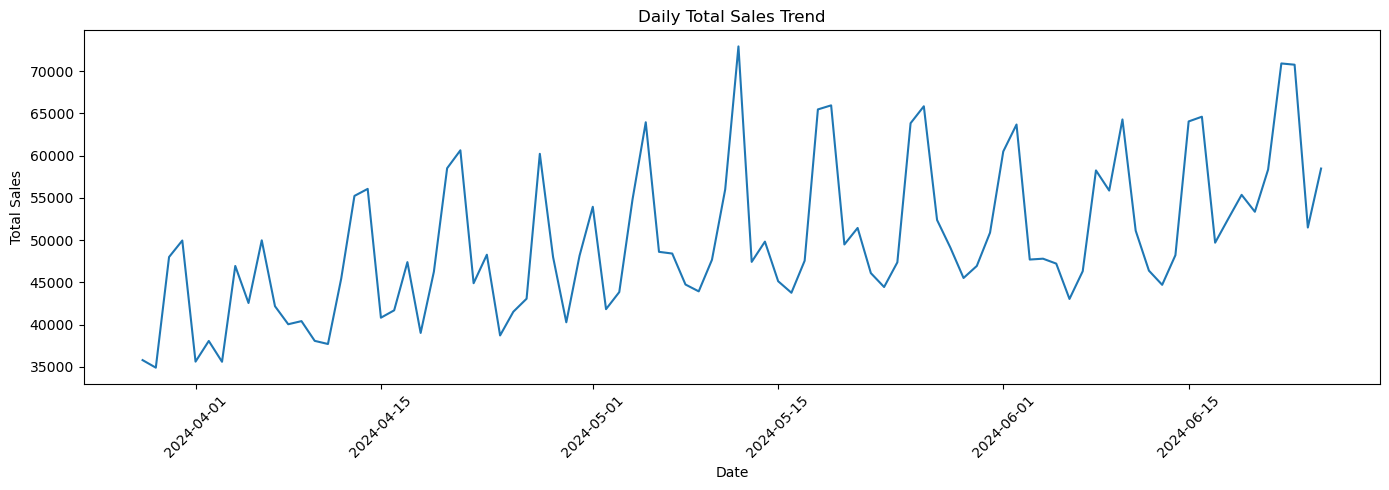

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_demand_summary["dt"], daily_demand_summary["total_sales"])
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

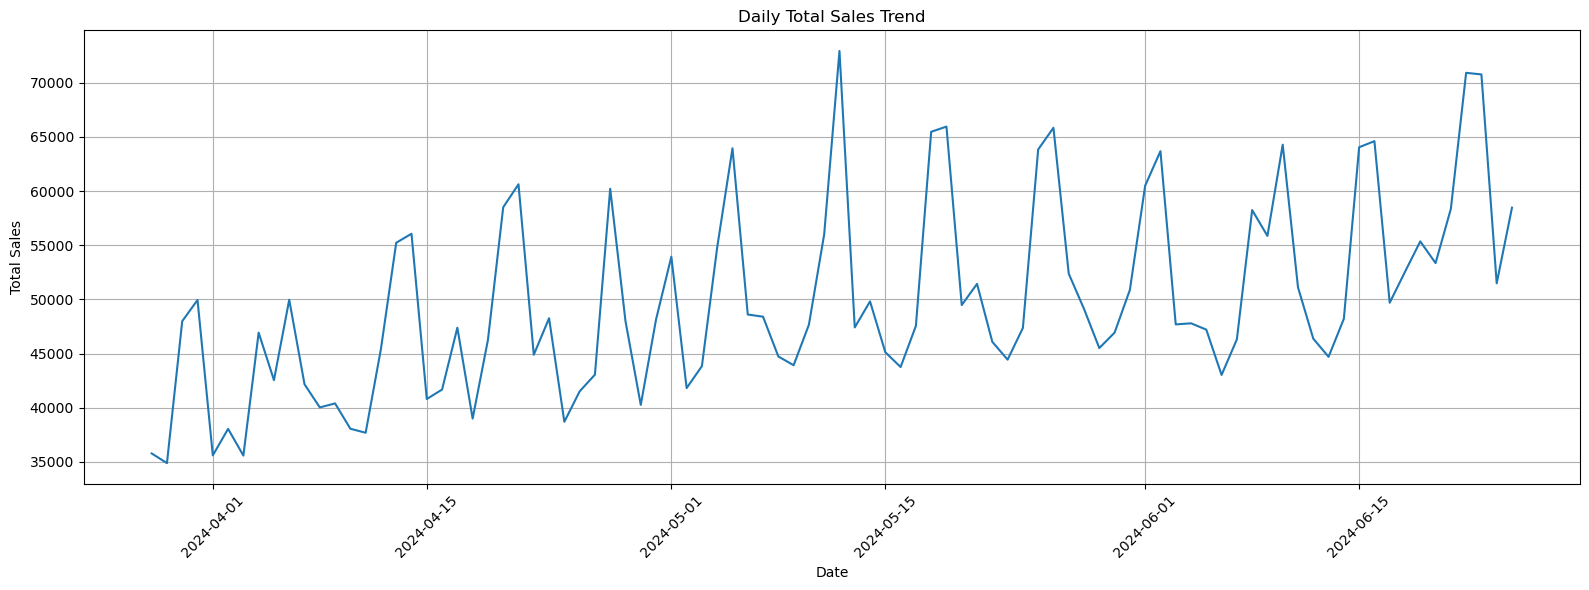

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(daily_demand_summary["dt"], daily_demand_summary["total_sales"])
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Daily Total Stockout Hours Trend

The daily stockout hours trend chart visualizes how total stockout exposure changes over time.

This chart helps identify:

- Days with high stockout pressure
- Periods where product availability may have affected observed sales
- Potential relationships between stockout exposure and demand variation

This is important because high stockout hours may cause observed sales to underestimate true customer demand.

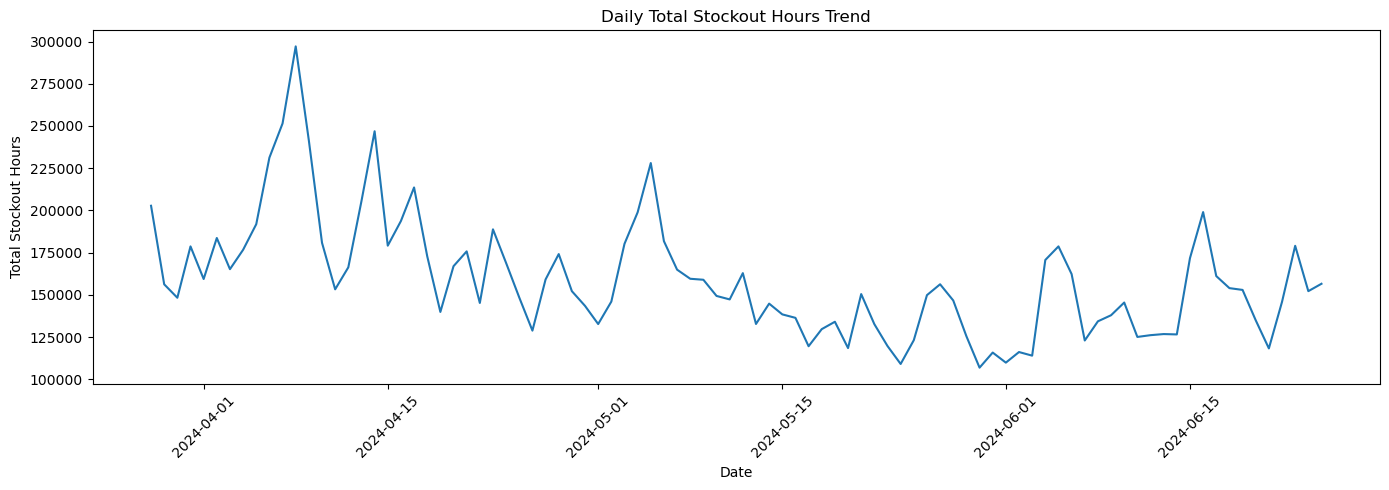

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(daily_demand_summary["dt"], daily_demand_summary["total_stockout_hours"])
plt.title("Daily Total Stockout Hours Trend")
plt.xlabel("Date")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

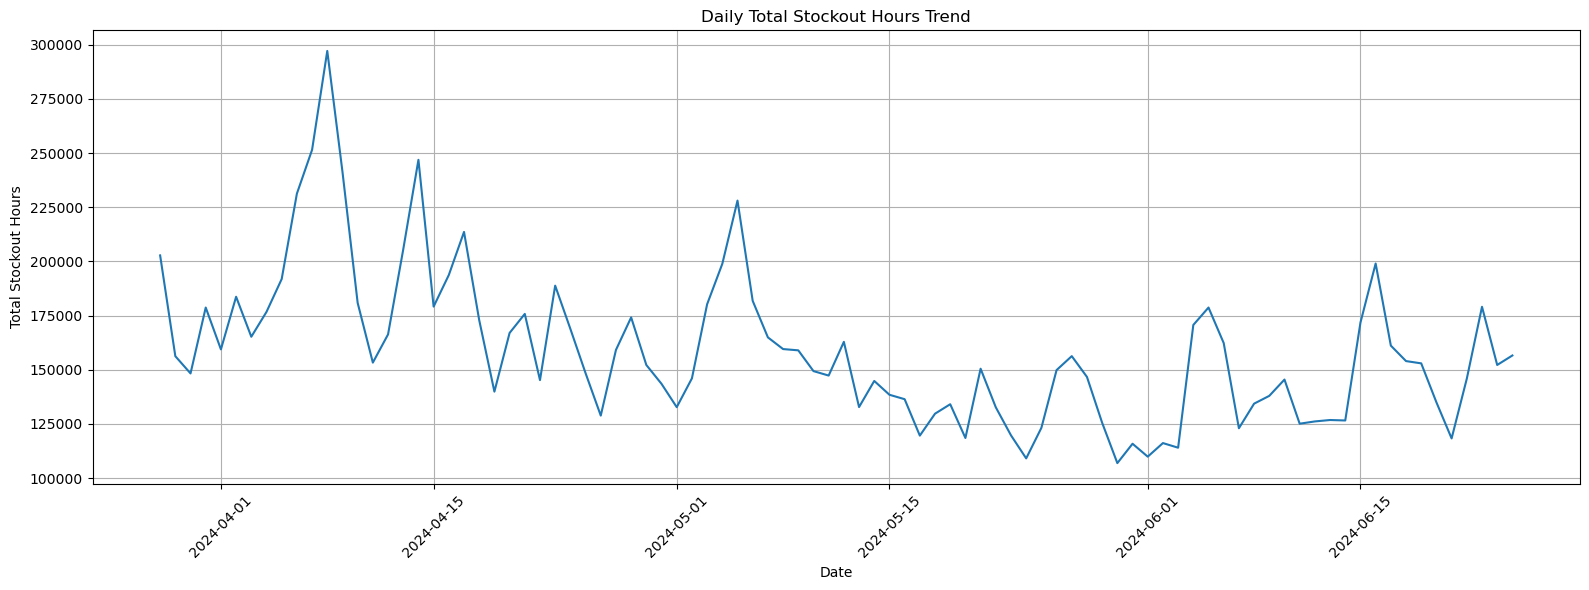

In [63]:
plt.figure(figsize=(16, 6))
plt.plot(daily_demand_summary["dt"], daily_demand_summary["total_stockout_hours"])
plt.title("Daily Total Stockout Hours Trend")
plt.xlabel("Date")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
daily_demand_summary.to_csv(
    processed_folder / "eda_daily_demand_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

overall_demand_stats.to_csv(
    processed_folder / "eda_overall_demand_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Daily demand EDA outputs saved successfully.")

Daily demand EDA outputs saved successfully.


#### Key Observations from Overall Demand Trends

The prepared training dataset shows a consistent daily structure, with 50,000 product-store observations per day across 865 products and 898 stores.

Across the training period, total sales reached approximately 4.49 million normalized sales units. Average daily total sales were approximately 49.93K, with daily sales ranging from approximately 34.89K to 72.94K.

The daily sales trend shows meaningful variation over time, with relatively lower sales at the beginning of the training period and several higher-demand days toward the later part of the period.

Stockout exposure was also substantial, with approximately 14.31 million total stockout hours across the training period and an average of approximately 159K stockout hours per day.

These findings suggest that both demand variation and product availability constraints are important factors to consider in later stages of the project, especially during feature engineering, forecasting model development, and inventory risk segmentation.

### 11.2 Seasonality Analysis

This section analyzes demand patterns across different calendar and business time dimensions.

The objective is to understand whether sales and stockout behavior change depending on the day of the week, weekend periods, holidays, and activity periods.

Seasonality analysis is important for demand forecasting because repeated time-based patterns can help improve feature engineering and model performance. If demand changes systematically by weekday, weekend, holiday, or activity status, these variables should be considered during forecasting model development.

In [64]:
# Ensure dt is in datetime format
daily_train["dt"] = pd.to_datetime(daily_train["dt"])

# Create calendar features
daily_train["day_of_week"] = daily_train["dt"].dt.day_name()
daily_train["day_of_week_num"] = daily_train["dt"].dt.dayofweek
daily_train["is_weekend"] = daily_train["day_of_week_num"].isin([5, 6]).astype(int)

display(daily_train[["dt", "day_of_week", "day_of_week_num", "is_weekend"]].head())

,dt,day_of_week,day_of_week_num,is_weekend
0,2024-03-28,Thursday,3,0
1,2024-03-29,Friday,4,0
2,2024-03-30,Saturday,5,1
3,2024-03-31,Sunday,6,1
4,2024-04-01,Monday,0,0


#### Demand by Day of Week

This analysis compares total sales, average sales, and stockout exposure across weekdays.

The goal is to identify whether specific days of the week consistently show higher or lower demand.

In [66]:
weekday_summary = (
    daily_train
    .groupby(["day_of_week_num", "day_of_week"])
    .agg(
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_observations=("sale_amount", "count"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
    .sort_values("day_of_week_num")
)

display(weekday_summary)

,day_of_week_num,day_of_week,total_sales,avg_sales,median_sales,total_observations,total_stockout_hours,avg_stockout_hours,avg_discount
0,0,Monday,612677.022,0.942580,0.60,650000,2095125,3.223269,0.913299
1,1,Tuesday,625290.406,0.961985,0.66,650000,2164227,3.329580,0.911459
2,2,Wednesday,544130.431,0.906884,0.60,600000,1875118,3.125197,0.909696
3,3,Thursday,562923.368,0.866036,0.60,650000,1946039,2.993906,0.912630
4,4,Friday,602403.771,0.926775,0.60,650000,1825039,2.807752,0.914645
5,5,Saturday,765784.513,1.178130,0.80,650000,2072062,3.187788,0.907451
6,6,Sunday,780451.276,1.200694,0.80,650000,2333926,3.590655,0.908697


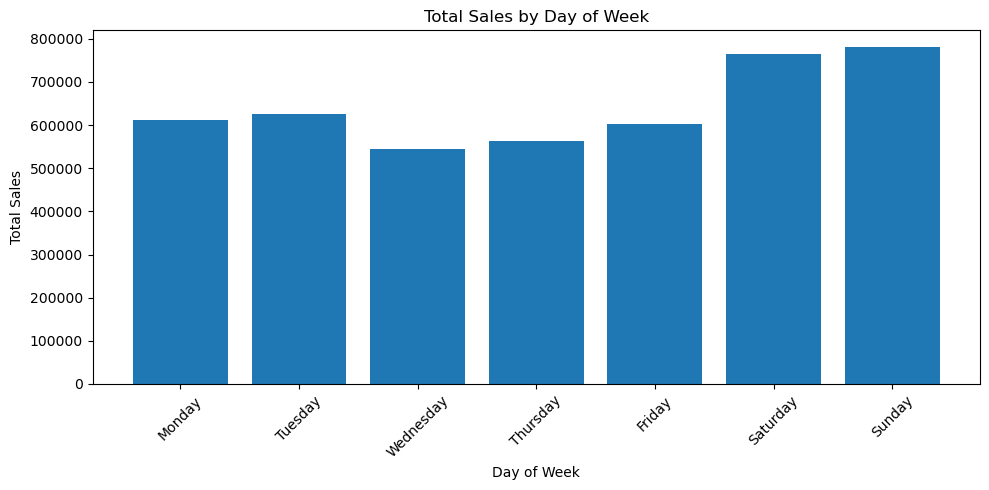

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(weekday_summary["day_of_week"], weekday_summary["total_sales"])
plt.title("Total Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

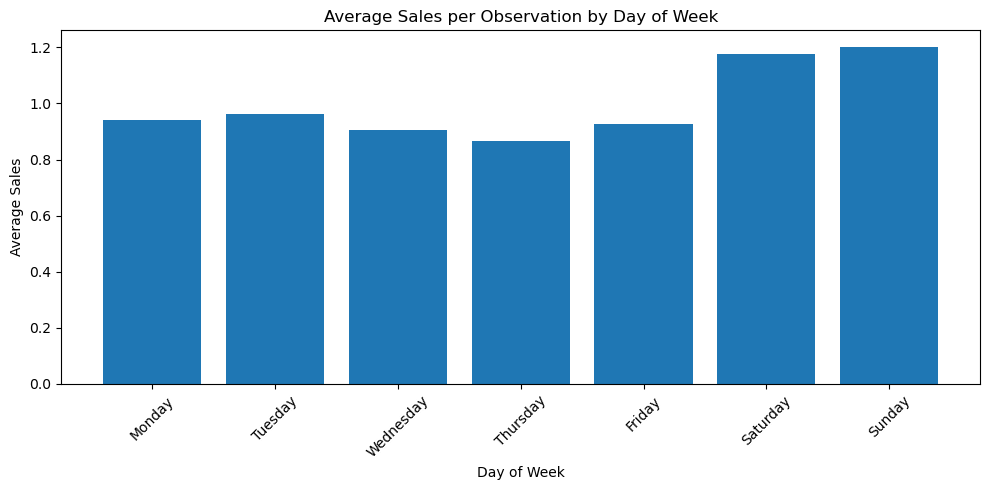

In [68]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_summary["day_of_week"], weekday_summary["avg_sales"])
plt.title("Average Sales per Observation by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Weekend vs Weekday Demand

This analysis compares demand between weekdays and weekends.

The goal is to determine whether weekend days show stronger or weaker demand compared to regular weekdays.

In [70]:
weekend_summary = (
    daily_train
    .groupby("is_weekend")
    .agg(
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_observations=("sale_amount", "count"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

weekend_summary["period_type"] = weekend_summary["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_summary = weekend_summary[
    [
        "period_type",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_observations",
        "total_stockout_hours",
        "avg_stockout_hours",
        "avg_discount"
    ]
]

display(weekend_summary)

,period_type,total_sales,avg_sales,median_sales,total_observations,total_stockout_hours,avg_stockout_hours,avg_discount
0,Weekday,2947424.998,0.921070,0.6,3200000,9905548,3.095484,0.912387
1,Weekend,1546235.789,1.189412,0.8,1300000,4405988,3.389222,0.908074


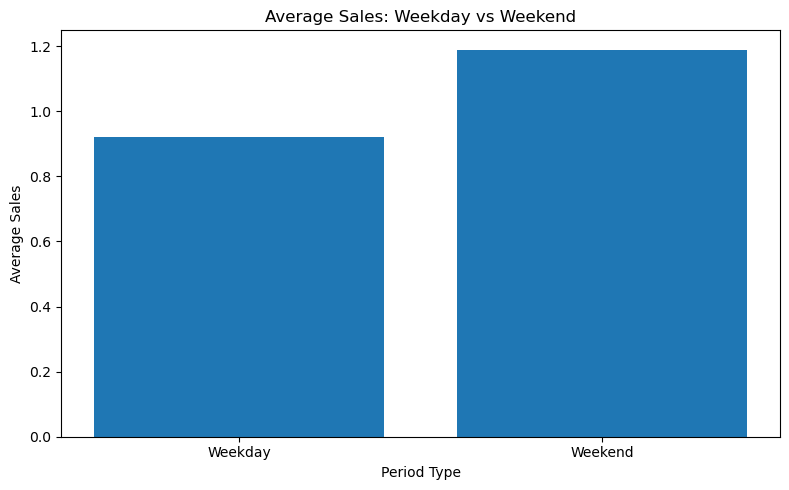

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(weekend_summary["period_type"], weekend_summary["avg_sales"])
plt.title("Average Sales: Weekday vs Weekend")
plt.xlabel("Period Type")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Holiday Demand Analysis

This analysis compares demand behavior between holiday and non-holiday observations.

The purpose is to understand whether holidays are associated with higher sales, lower sales, or different stockout exposure.

In [72]:
holiday_summary = (
    daily_train
    .groupby("holiday_flag")
    .agg(
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_observations=("sale_amount", "count"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

holiday_summary["holiday_status"] = holiday_summary["holiday_flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

holiday_summary = holiday_summary[
    [
        "holiday_status",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_observations",
        "total_stockout_hours",
        "avg_stockout_hours",
        "avg_discount"
    ]
]

display(holiday_summary)

,holiday_status,total_sales,avg_sales,median_sales,total_observations,total_stockout_hours,avg_stockout_hours,avg_discount
0,Non-Holiday,2696208.536,0.913969,0.6,2950000,9184109,3.113257,0.912082
1,Holiday,1797452.251,1.159647,0.8,1550000,5127427,3.308017,0.909351


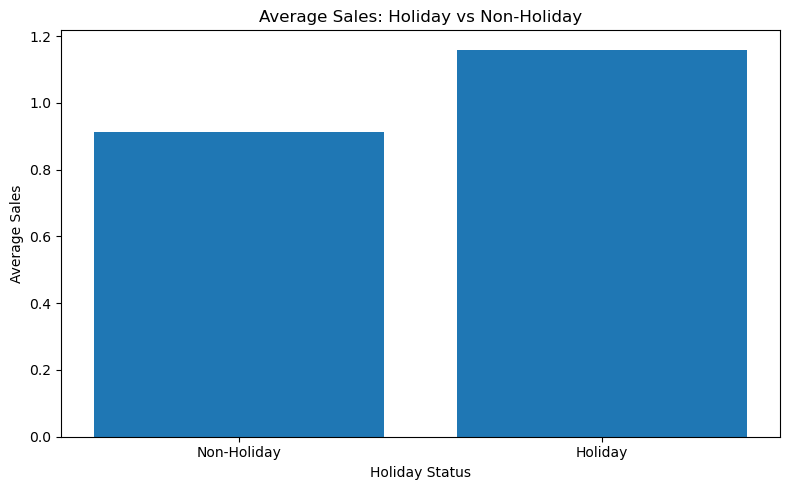

In [73]:
plt.figure(figsize=(8, 5))
plt.bar(holiday_summary["holiday_status"], holiday_summary["avg_sales"])
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Status")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Activity Period Demand Analysis

This analysis compares demand behavior between observations with and without activity periods.

The purpose is to evaluate whether activity periods are associated with higher sales, higher stockout exposure, or different average discount levels.

In [75]:
activity_summary = (
    daily_train
    .groupby("activity_flag")
    .agg(
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_observations=("sale_amount", "count"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

activity_summary["activity_status"] = activity_summary["activity_flag"].map({
    0: "No Activity",
    1: "Activity"
})

activity_summary = activity_summary[
    [
        "activity_status",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_observations",
        "total_stockout_hours",
        "avg_stockout_hours",
        "avg_discount"
    ]
]

display(activity_summary)

,activity_status,total_sales,avg_sales,median_sales,total_observations,total_stockout_hours,avg_stockout_hours,avg_discount
0,No Activity,2768190.609,0.989662,0.6,2797107,8709473,3.113743,0.978828
1,Activity,1725470.178,1.013258,0.7,1702893,5602063,3.289733,0.799961


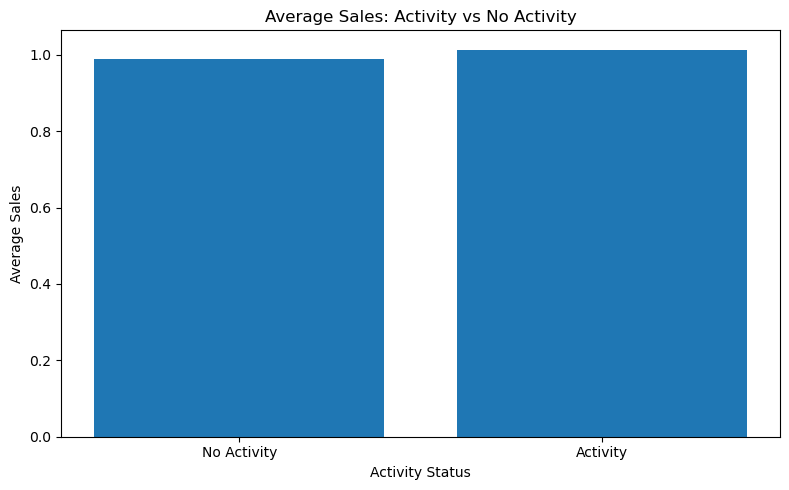

In [76]:
plt.figure(figsize=(8, 5))
plt.bar(activity_summary["activity_status"], activity_summary["avg_sales"])
plt.title("Average Sales: Activity vs No Activity")
plt.xlabel("Activity Status")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Save Seasonality Analysis Outputs

The seasonality analysis outputs are saved locally to support reporting, dashboard development, and reproducibility.

In [77]:
weekday_summary.to_csv(
    processed_folder / "eda_weekday_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

weekend_summary.to_csv(
    processed_folder / "eda_weekend_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

holiday_summary.to_csv(
    processed_folder / "eda_holiday_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

activity_summary.to_csv(
    processed_folder / "eda_activity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Seasonality analysis outputs saved successfully.")

Seasonality analysis outputs saved successfully.


#### 11.2 Seasonality Analysis — Key Findings

The seasonality analysis showed clear calendar-based demand patterns in the prepared training dataset.

Demand varied noticeably by day of week. Weekend days recorded the highest average sales per observation, with **Sunday** showing the highest average sales at approximately **1.20**, followed by **Saturday** at approximately **1.18**. Mid-week days showed lower average demand, especially **Thursday** with an average sales value of approximately **0.87** and **Wednesday** with approximately **0.91**.

The weekday versus weekend comparison confirmed that demand is stronger during weekends. Weekday observations recorded average sales of approximately **0.92**, while weekend observations recorded higher average sales of approximately **1.19**. Weekend periods also showed higher average stockout hours, with approximately **3.39** average stockout hours compared with **3.10** during weekdays. This suggests that weekend demand may create stronger pressure on inventory availability.

Holiday observations also showed stronger demand than non-holiday observations. Non-holiday records had average sales of approximately **0.91**, while holiday records had average sales of approximately **1.16**. Holiday periods also had slightly higher stockout exposure, which indicates that increased demand during holidays may contribute to higher product availability risk.

Activity-period analysis showed a smaller difference in average sales. Observations without activity periods recorded average sales of approximately **0.99**, while activity-period observations recorded average sales of approximately **1.01**. Although the sales uplift is modest, activity-period observations had a much lower average discount factor, suggesting that activity periods are likely associated with stronger promotional or discount activity.

Overall, the seasonality analysis indicates that calendar-based features are important for this project. Weekend indicators, holiday flags, activity flags, and day-of-week features should be considered during feature engineering and forecasting model development. These variables may help the model capture repeated demand patterns and improve future sales predictions.

#### 11.2 Seasonality Analysis — Key Findings

The seasonality analysis showed clear calendar-based demand patterns in the prepared training dataset.

Demand varied noticeably by day of week. Weekend days recorded the highest average sales per observation, with **Sunday** showing the highest average sales at approximately **1.20**, followed by **Saturday** at approximately **1.18**. Mid-week days showed lower average demand, especially **Thursday** with an average sales value of approximately **0.87** and **Wednesday** with approximately **0.91**.

The weekday versus weekend comparison confirmed that demand is stronger during weekends. Weekday observations recorded average sales of approximately **0.92**, while weekend observations recorded higher average sales of approximately **1.19**. Weekend periods also showed higher average stockout hours, with approximately **3.39** average stockout hours compared with **3.10** during weekdays. This suggests that weekend demand may create stronger pressure on inventory availability.

Holiday observations also showed stronger demand than non-holiday observations. Non-holiday records had average sales of approximately **0.91**, while holiday records had average sales of approximately **1.16**. Holiday periods also had slightly higher stockout exposure, which indicates that increased demand during holidays may contribute to higher product availability risk.

Activity-period analysis showed a smaller difference in average sales. Observations without activity periods recorded average sales of approximately **0.99**, while activity-period observations recorded average sales of approximately **1.01**. Although the sales uplift is modest, activity-period observations had a much lower average discount factor, suggesting that activity periods are likely associated with stronger promotional or discount activity.

Overall, the seasonality analysis indicates that calendar-based features are important for this project. Weekend indicators, holiday flags, activity flags, and day-of-week features should be considered during feature engineering and forecasting model development. These variables may help the model capture repeated demand patterns and improve future sales predictions.

### 11.3 Product Performance Analysis

This section analyzes product-level demand behavior across the prepared training dataset.

The objective is to identify high-performing products, low-demand products, products with high stockout exposure, and products that may require closer inventory monitoring.

Product performance analysis is important because inventory and replenishment decisions are often made at the product level. Understanding product-level sales contribution, demand frequency, and stockout exposure helps support ABC analysis, inventory risk segmentation, and forecasting prioritization.

In [78]:
product_performance = (
    daily_train
    .groupby([
        "product_id",
        "management_group_id",
        "first_category_id",
        "second_category_id",
        "third_category_id"
    ])
    .agg(
        total_observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        sales_std=("sale_amount", "std"),
        active_sales_days=("sale_amount", lambda x: (x > 0).sum()),
        zero_sales_days=("sale_amount", lambda x: (x == 0).sum()),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_days=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

product_performance["zero_sales_rate"] = (
    product_performance["zero_sales_days"] / product_performance["total_observations"] * 100
)

product_performance["stockout_day_rate"] = (
    product_performance["stockout_days"] / product_performance["total_observations"] * 100
)

display(product_performance.head())

,product_id,management_group_id,first_category_id,second_category_id,third_category_id,total_observations,total_sales,avg_sales,median_sales,max_sales,sales_std,active_sales_days,zero_sales_days,total_stockout_hours,avg_stockout_hours,stockout_days,avg_discount,zero_sales_rate,stockout_day_rate
0,0,2,31,79,227,1170,910.50,0.778205,0.7,4.4,0.575352,1147,23,3075,2.628205,471,0.914677,1.965812,40.256410
1,1,6,20,58,74,4770,8936.06,1.873388,1.6,13.4,1.307406,4597,173,12366,2.592453,1839,0.976623,3.626834,38.553459
2,2,0,5,6,65,4320,2020.00,0.467593,0.4,3.0,0.346358,4025,295,11101,2.569676,1821,0.962673,6.828704,42.152778
3,3,0,28,72,218,720,976.20,1.355833,1.0,8.0,1.269584,606,114,1277,1.773611,107,0.926319,15.833333,14.861111
4,4,2,29,78,82,70470,183265.30,2.600614,1.7,27.0,2.791802,67546,2924,212618,3.017142,33838,0.873084,4.149283,48.017596


#### Top Products by Total Sales

This analysis identifies the products that contribute the most to total sales across the training period.

High-sales products are important because they may represent key demand drivers and should receive priority attention in forecasting, replenishment planning, and inventory monitoring.

In [79]:
top_products_sales = (
    product_performance
    .sort_values("total_sales", ascending=False)
    .head(20)
)

display(top_products_sales[
    [
        "product_id",
        "total_sales",
        "avg_sales",
        "max_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_day_rate",
        "avg_discount"
    ]
])

,product_id,total_sales,avg_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_day_rate,avg_discount
267,267,183395.100,15.555140,44.9,69816,5.921628,78.134012,0.031213
4,4,183265.300,2.600614,27.0,212618,3.017142,48.017596,0.873084
300,300,154505.577,4.166817,18.8,128801,3.473598,53.182309,0.977215
117,117,150032.945,3.631880,16.9,126860,3.070927,48.927620,0.958435
215,215,144031.118,2.606426,13.7,206426,3.735541,54.724937,0.729207
70,70,120042.148,3.595153,14.3,109878,3.290746,54.378556,0.938756
580,580,117250.900,1.772500,20.4,268214,4.054633,69.785336,0.956113
834,834,87215.500,1.307775,12.4,467586,7.011336,68.136152,0.991354
691,691,66486.590,3.847604,13.0,43618,2.524190,47.743056,0.974588
191,191,66122.317,2.057962,14.0,122690,3.818550,50.690943,0.862563


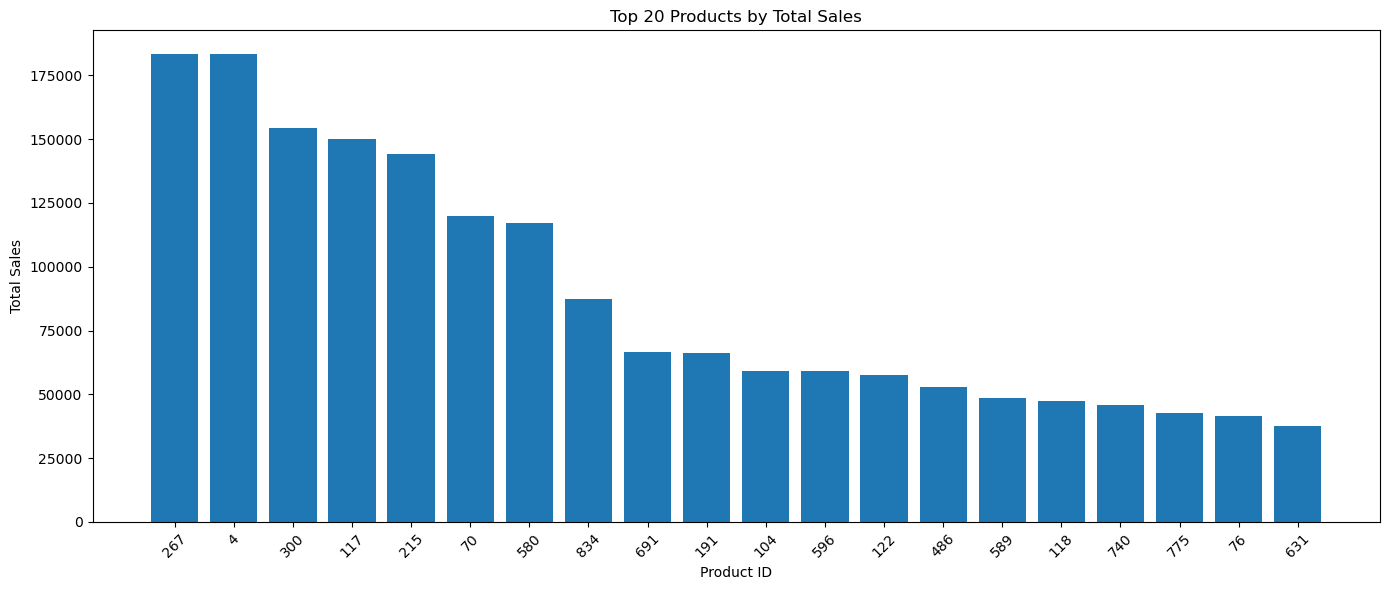

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(top_products_sales["product_id"].astype(str), top_products_sales["total_sales"])
plt.title("Top 20 Products by Total Sales")
plt.xlabel("Product ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Products with Highest Stockout Exposure

This analysis identifies products with the highest total stockout hours.

Products with high stockout exposure may represent inventory availability risks, especially if they also have strong sales performance.

In [83]:
top_products_stockout = (
    product_performance
    .sort_values("total_stockout_hours", ascending=False)
    .head(20)
)

display(top_products_stockout[
    [
        "product_id",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_day_rate",
        "zero_sales_rate"
    ]
])

,product_id,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_day_rate,zero_sales_rate
834,834,87215.500,1.307775,467586,7.011336,68.136152,12.618084
129,129,28139.730,0.730523,292575,7.595405,66.316199,26.588785
580,580,117250.900,1.772500,268214,4.054633,69.785336,0.142101
600,600,37648.900,0.841692,255505,5.712162,75.110664,2.249050
4,4,183265.300,2.600614,212618,3.017142,48.017596,4.149283
215,215,144031.118,2.606426,206426,3.735541,54.724937,4.838943
41,41,36637.220,0.827399,202289,4.568406,42.626468,16.124661
596,596,58976.900,1.147634,192658,3.748939,66.594668,0.367776
740,740,45648.500,0.922192,190093,3.840263,67.266667,0.559596
6,6,35267.160,0.715068,172392,3.495377,51.295620,2.698702


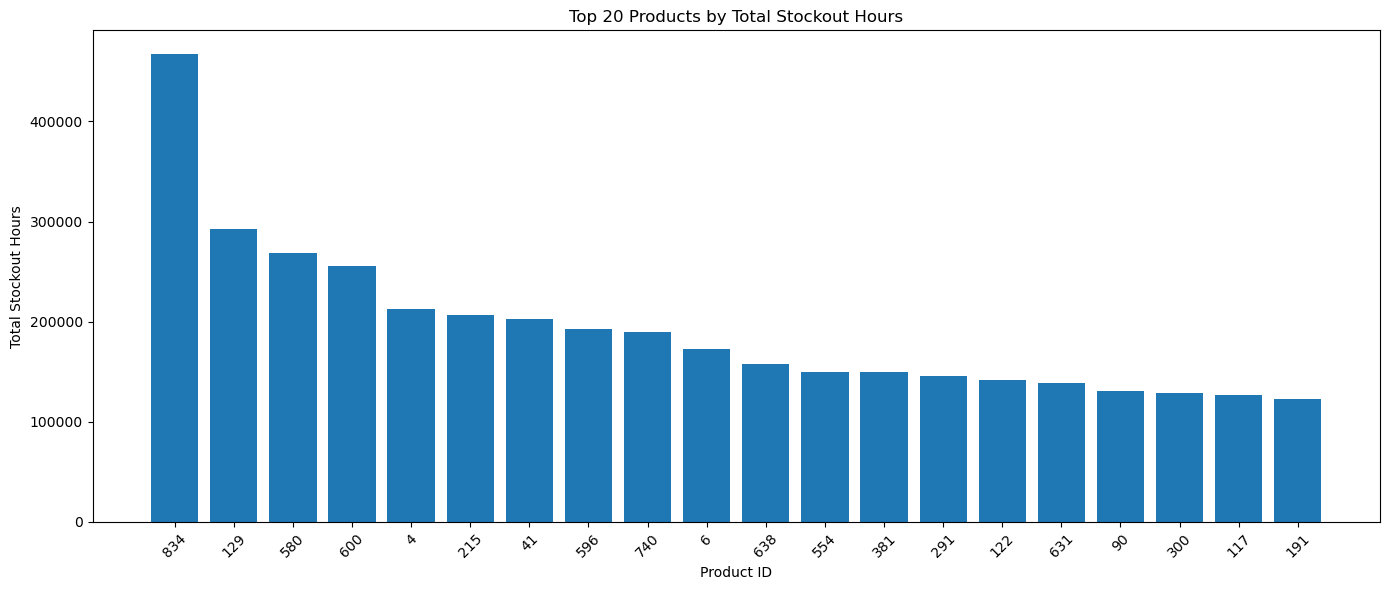

In [84]:
plt.figure(figsize=(14, 6))
plt.bar(top_products_stockout["product_id"].astype(str), top_products_stockout["total_stockout_hours"])
plt.title("Top 20 Products by Total Stockout Hours")
plt.xlabel("Product ID")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Product Sales Concentration

This step evaluates how concentrated total sales are across products.

Sales concentration is important because a small number of products may contribute a large share of total demand. This analysis helps prepare for ABC classification.

In [85]:
product_sales_contribution = product_performance.copy()

product_sales_contribution = product_sales_contribution.sort_values(
    "total_sales",
    ascending=False
).reset_index(drop=True)

product_sales_contribution["sales_share_percent"] = (
    product_sales_contribution["total_sales"] /
    product_sales_contribution["total_sales"].sum() * 100
)

product_sales_contribution["cumulative_sales_share_percent"] = (
    product_sales_contribution["sales_share_percent"].cumsum()
)

display(product_sales_contribution.head(20))

,product_id,management_group_id,first_category_id,second_category_id,third_category_id,total_observations,total_sales,avg_sales,median_sales,max_sales,...,active_sales_days,zero_sales_days,total_stockout_hours,avg_stockout_hours,stockout_days,avg_discount,zero_sales_rate,stockout_day_rate,sales_share_percent,cumulative_sales_share_percent
0,267,6,21,64,184,11790,183395.100,15.555140,17.9,44.9,...,11424,366,69816,5.921628,9212,0.031213,3.104326,78.134012,4.081196,4.081196
1,4,2,29,78,82,70470,183265.300,2.600614,1.7,27.0,...,67546,2924,212618,3.017142,33838,0.873084,4.149283,48.017596,4.078307,8.159503
2,300,6,20,50,24,37080,154505.577,4.166817,3.8,18.8,...,36132,948,128801,3.473598,19720,0.977215,2.556634,53.182309,3.438301,11.597804
3,117,6,4,28,1,41310,150032.945,3.631880,3.5,16.9,...,40168,1142,126860,3.070927,20212,0.958435,2.764464,48.927620,3.338769,14.936573
4,215,6,4,28,149,55260,144031.118,2.606426,2.5,13.7,...,52586,2674,206426,3.735541,30241,0.729207,4.838943,54.724937,3.205207,18.141780
5,70,6,4,28,81,33390,120042.148,3.595153,3.4,14.3,...,32652,738,109878,3.290746,18157,0.938756,2.210243,54.378556,2.671366,20.813146
6,580,2,29,76,60,66150,117250.900,1.772500,1.6,20.4,...,66056,94,268214,4.054633,46163,0.956113,0.142101,69.785336,2.609251,23.422397
7,834,0,28,72,154,66690,87215.500,1.307775,1.2,12.4,...,58275,8415,467586,7.011336,45440,0.991354,12.618084,68.136152,1.940856,25.363254
8,691,6,21,64,19,17280,66486.590,3.847604,3.6,13.0,...,17043,237,43618,2.524190,8250,0.974588,1.371528,47.743056,1.479564,26.842818
9,191,6,4,28,81,32130,66122.317,2.057962,1.8,14.0,...,29996,2134,122690,3.818550,16287,0.862563,6.641768,50.690943,1.471458,28.314275


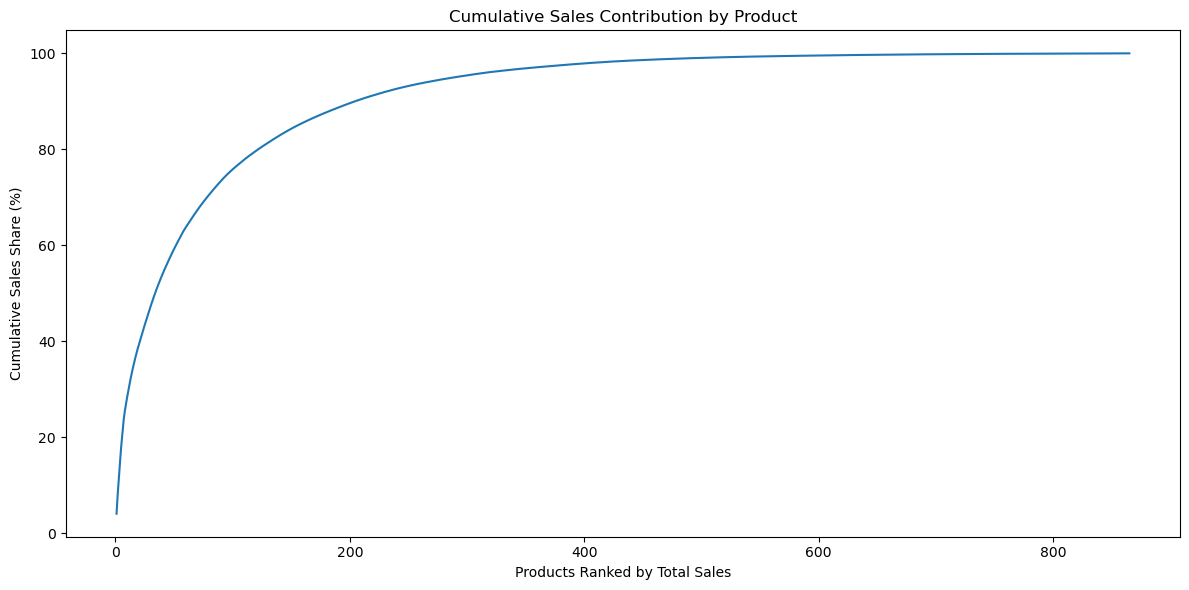

In [87]:
plt.figure(figsize=(12, 6))
plt.plot(
    range(1, len(product_sales_contribution) + 1),
    product_sales_contribution["cumulative_sales_share_percent"]
)
plt.title("Cumulative Sales Contribution by Product")
plt.xlabel("Products Ranked by Total Sales")
plt.ylabel("Cumulative Sales Share (%)")
plt.tight_layout()
plt.show()

#### Product ABC Classification

ABC classification groups products based on cumulative sales contribution.

A common approach is:

- **A products:** products contributing up to 80% of total sales
- **B products:** products contributing from 80% to 95% of total sales
- **C products:** products contributing the remaining 5% of total sales

This classification helps prioritize products for inventory monitoring, forecasting, and replenishment planning.

In [88]:
def assign_abc_class(cumulative_share):
    if cumulative_share <= 80:
        return "A"
    elif cumulative_share <= 95:
        return "B"
    else:
        return "C"

product_sales_contribution["abc_class"] = product_sales_contribution[
    "cumulative_sales_share_percent"
].apply(assign_abc_class)

abc_summary = (
    product_sales_contribution
    .groupby("abc_class")
    .agg(
        product_count=("product_id", "count"),
        total_sales=("total_sales", "sum"),
        avg_sales=("avg_sales", "mean"),
        total_stockout_hours=("total_stockout_hours", "sum"),
        avg_stockout_hours=("avg_stockout_hours", "mean")
    )
    .reset_index()
)

abc_summary["sales_share_percent"] = (
    abc_summary["total_sales"] / abc_summary["total_sales"].sum() * 100
)

display(abc_summary)

,abc_class,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,sales_share_percent
0,A,121,3588724.160,1.276752,9671900,3.077395,79.861928
1,B,167,678492.400,0.749485,3476181,3.129613,15.098879
2,C,577,226444.227,0.607763,1163455,2.873766,5.039193


#### Save Product Performance Outputs

The product performance outputs are saved locally to support reporting, dashboard development, ABC analysis, and later inventory risk segmentation.

In [90]:
product_performance.to_csv(
    processed_folder / "eda_product_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

top_products_sales.to_csv(
    processed_folder / "eda_top_products_by_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

top_products_stockout.to_csv(
    processed_folder / "eda_top_products_by_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

product_sales_contribution.to_csv(
    processed_folder / "eda_product_sales_contribution_abc.csv",
    index=False,
    encoding="utf-8-sig"
)

abc_summary.to_csv(
    processed_folder / "eda_abc_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Product performance analysis outputs saved successfully.")

Product performance analysis outputs saved successfully.


#### 11.3 Product Performance Analysis — Key Findings

The product performance analysis showed that product-level demand is highly uneven across the dataset. Some products contribute a large share of total sales, while many other products contribute relatively small portions of demand.

The top products by total sales include `product_id = 267`, `product_id = 4`, `product_id = 300`, `product_id = 117`, and `product_id = 215`. Product `267` recorded the highest total sales at approximately **183,395**, followed closely by product `4` with approximately **183,265** total sales. These products represent key demand drivers and should receive higher priority in forecasting, replenishment planning, and inventory monitoring.

The stockout analysis showed that some high-demand products also experience significant stockout exposure. Product `834` recorded the highest total stockout hours at approximately **467,586**, followed by product `129` with approximately **292,575**, product `580` with approximately **268,214**, and product `600` with approximately **255,505** stockout hours. This indicates that high stockout exposure is concentrated in a subset of products and may represent important inventory availability risks.

Some products appear in both the top-sales and top-stockout rankings. For example, products such as `4`, `580`, `834`, `215`, `596`, `740`, `300`, `117`, and `191` show strong relevance in both sales and stockout exposure. These products may require closer operational monitoring because they are important from both a demand and availability perspective.

The product sales concentration analysis showed that total sales are concentrated among a relatively small number of products. The cumulative sales contribution curve rises steeply at the beginning, indicating that the highest-ranked products contribute a large share of total sales before gradually flattening across the long tail of lower-contribution products.

The ABC classification further confirmed this concentration pattern. The results showed:

- **A products:** 121 products contributing approximately **79.86%** of total sales
- **B products:** 167 products contributing approximately **15.10%** of total sales
- **C products:** 577 products contributing approximately **5.04%** of total sales

This means that around **14% of products** account for nearly **80% of total sales**, while the majority of products contribute only a small share of demand. This supports the need for differentiated inventory and forecasting strategies by product class.

A-class products should receive the highest priority for forecasting accuracy, replenishment planning, and stockout monitoring. B-class products require moderate monitoring, while C-class products may be managed with simpler inventory rules unless they show specific stockout or business-critical behavior.

#### Product Sales vs Stockout Relationship

This analysis compares product-level sales performance with stockout exposure.

The objective is to understand whether products with high stockout hours are also strong sales contributors, or whether stockout exposure is associated with lower observed sales.

This is important because low sales combined with high stockout hours may indicate constrained or censored demand, while high sales combined with high stockout hours may indicate high-priority products that require stronger replenishment monitoring.

In [91]:
product_sales_stockout_corr = product_performance[
    ["total_sales", "total_stockout_hours", "avg_sales", "avg_stockout_hours", "zero_sales_rate", "stockout_day_rate"]
].corr()

display(product_sales_stockout_corr)

,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,zero_sales_rate,stockout_day_rate
total_sales,1.000000,0.716616,0.526460,0.113004,-0.088749,0.161454
total_stockout_hours,0.716616,1.000000,0.167734,0.258769,-0.043421,0.224055
avg_sales,0.526460,0.167734,1.000000,0.054383,-0.044658,0.079684
avg_stockout_hours,0.113004,0.258769,0.054383,1.000000,0.107793,0.770210
zero_sales_rate,-0.088749,-0.043421,-0.044658,0.107793,1.000000,-0.335653
stockout_day_rate,0.161454,0.224055,0.079684,0.770210,-0.335653,1.000000


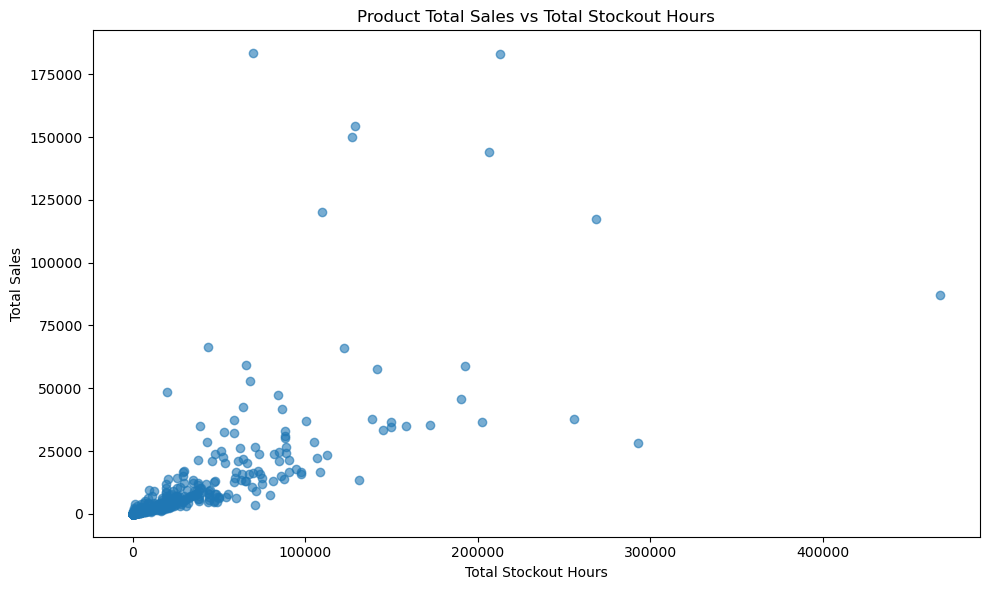

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(
    product_performance["total_stockout_hours"],
    product_performance["total_sales"],
    alpha=0.6
)

plt.title("Product Total Sales vs Total Stockout Hours")
plt.xlabel("Total Stockout Hours")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [93]:
sales_threshold = product_performance["total_sales"].median()
stockout_threshold = product_performance["total_stockout_hours"].median()

def classify_sales_stockout(row):
    if row["total_sales"] >= sales_threshold and row["total_stockout_hours"] >= stockout_threshold:
        return "High Sales / High Stockout"
    elif row["total_sales"] >= sales_threshold and row["total_stockout_hours"] < stockout_threshold:
        return "High Sales / Low Stockout"
    elif row["total_sales"] < sales_threshold and row["total_stockout_hours"] >= stockout_threshold:
        return "Low Sales / High Stockout"
    else:
        return "Low Sales / Low Stockout"

product_performance["sales_stockout_segment"] = product_performance.apply(
    classify_sales_stockout,
    axis=1
)

sales_stockout_segment_summary = (
    product_performance
    .groupby("sales_stockout_segment")
    .agg(
        product_count=("product_id", "count"),
        total_sales=("total_sales", "sum"),
        total_stockout_hours=("total_stockout_hours", "sum"),
        avg_sales=("avg_sales", "mean"),
        avg_stockout_hours=("avg_stockout_hours", "mean"),
        avg_zero_sales_rate=("zero_sales_rate", "mean")
    )
    .reset_index()
)

display(sales_stockout_segment_summary)

,sales_stockout_segment,product_count,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,avg_zero_sales_rate
0,High Sales / High Stockout,408,4393555.329,13888772,0.810040,3.053103,4.813243
1,High Sales / Low Stockout,25,28829.150,38195,2.208922,2.304393,7.160777
2,Low Sales / High Stockout,25,11486.424,84671,0.494889,3.728881,3.393196
3,Low Sales / Low Stockout,407,59789.884,299898,0.570610,2.841954,7.799251


#### Product Sales vs Stockout Relationship — Key Findings

The product-level sales and stockout relationship analysis showed a strong positive relationship between total sales and total stockout hours.

The correlation between `total_sales` and `total_stockout_hours` was approximately **0.72**, indicating that higher-selling products also tend to experience higher stockout exposure. This suggests that stockout risk is not limited to weak or slow-moving products. Instead, many high-demand products also face meaningful availability pressure.

The product segmentation analysis grouped products into four sales-stockout segments:

- **High Sales / High Stockout**
- **High Sales / Low Stockout**
- **Low Sales / High Stockout**
- **Low Sales / Low Stockout**

The largest and most business-critical segment was **High Sales / High Stockout**, containing **408 products**. This group contributed approximately **4.39 million** total sales and approximately **13.89 million** stockout hours. These products represent strong demand drivers but also carry high product availability risk.

The **Low Sales / High Stockout** segment contained **25 products**. Although this group contributed relatively low observed sales, it accumulated approximately **84,671 stockout hours**. These products require further investigation because their low sales may not necessarily indicate weak demand. Instead, sales may be constrained by product unavailability.

The analysis confirms that stockout exposure should be interpreted together with sales performance. High stockout hours do not automatically mean that a product is low-performing. In many cases, high stockout exposure is associated with high demand products, making those products important candidates for replenishment prioritization and inventory risk monitoring.

### 11.4 Store Performance Analysis

This section analyzes store-level demand behavior across the prepared training dataset.

The objective is to identify high-performing stores, stores with weak demand, stores with high stockout exposure, and stores that may require closer operational monitoring.

Store performance analysis is important because demand and stockout risk may vary significantly across store locations. A product may perform strongly in one store and weakly in another, so store-level analysis helps support operational decisions, replenishment planning, and Power BI dashboard development.

In [95]:
store_performance = (
    daily_train
    .groupby(["city_id", "store_id"])
    .agg(
        total_observations=("sale_amount", "count"),
        active_products=("product_id", "nunique"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        sales_std=("sale_amount", "std"),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22 Fox_cnt", "count") if False else ("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

store_performance["zero_sales_rate"] = (
    store_performance["zero_sales_observations"] /
    store_performance["total_observations"] * 100
)

store_performance["stockout_observation_rate"] = (
    store_performance["stockout_observations"] /
    store_performance["total_observations"] * 100
)

display(store_performance.head())

,city_id,store_id,total_observations,active_products,total_sales,avg_sales,median_sales,max_sales,sales_std,zero_sales_observations,total_stockout_hours,avg_stockout_hours,stockout_observations,avg_discount,zero_sales_rate,stockout_observation_rate
0,0,0,6660,74,7181.57,1.078314,0.7,12.0,1.164989,235,22353,3.356306,3202,0.909727,3.528529,48.078078
1,0,1,11880,132,13436.56,1.131024,0.7,21.3,1.456688,321,37509,3.157323,5494,0.921574,2.702020,46.245791
2,0,2,7650,85,7684.45,1.004503,0.7,18.0,1.113750,206,23663,3.093203,3365,0.914497,2.692810,43.986928
3,0,8,6300,70,5698.96,0.904597,0.7,8.0,0.851363,174,18724,2.972063,2663,0.900024,2.761905,42.269841
4,0,12,4860,54,4614.00,0.949383,0.7,11.8,0.937637,235,15497,3.188683,2202,0.906650,4.835391,45.308642


#### Top Stores by Total Sales

This analysis identifies the stores with the highest total sales during the training period.

High-sales stores may represent important demand centers and should receive closer attention in inventory planning, stockout monitoring, and Power BI reporting.

In [96]:
top_stores_sales = (
    store_performance
    .sort_values("total_sales", ascending=False)
    .head(20)
)

display(top_stores_sales[
    [
        "city_id",
        "store_id",
        "active_products",
        "total_sales",
        "avg_sales",
        "max_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "avg_discount"
    ]
])

,city_id,store_id,active_products,total_sales,avg_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,avg_discount
123,0,235,162,17510.530,1.200997,25.8,44966,3.084088,43.758573,0.923671
141,0,263,161,17407.810,1.201367,15.9,46330,3.197378,43.547274,0.918994
85,0,182,160,17269.840,1.199294,21.6,46063,3.198819,46.847222,0.921073
5,0,18,164,16878.290,1.143516,17.6,48841,3.309011,45.359079,0.925844
222,0,555,147,15693.479,1.186204,17.6,39636,2.995918,40.952381,0.919821
51,0,145,148,15666.470,1.176161,24.2,42614,3.199249,44.977477,0.919939
164,0,343,152,15643.140,1.143504,17.4,43263,3.162500,40.972222,0.920566
111,0,212,140,14673.620,1.164573,20.8,40205,3.190873,45.087302,0.914937
224,0,557,135,14592.450,1.201025,19.7,38126,3.137942,45.621399,0.916476
223,0,556,141,14388.140,1.133817,16.9,39337,3.099842,41.702128,0.916001


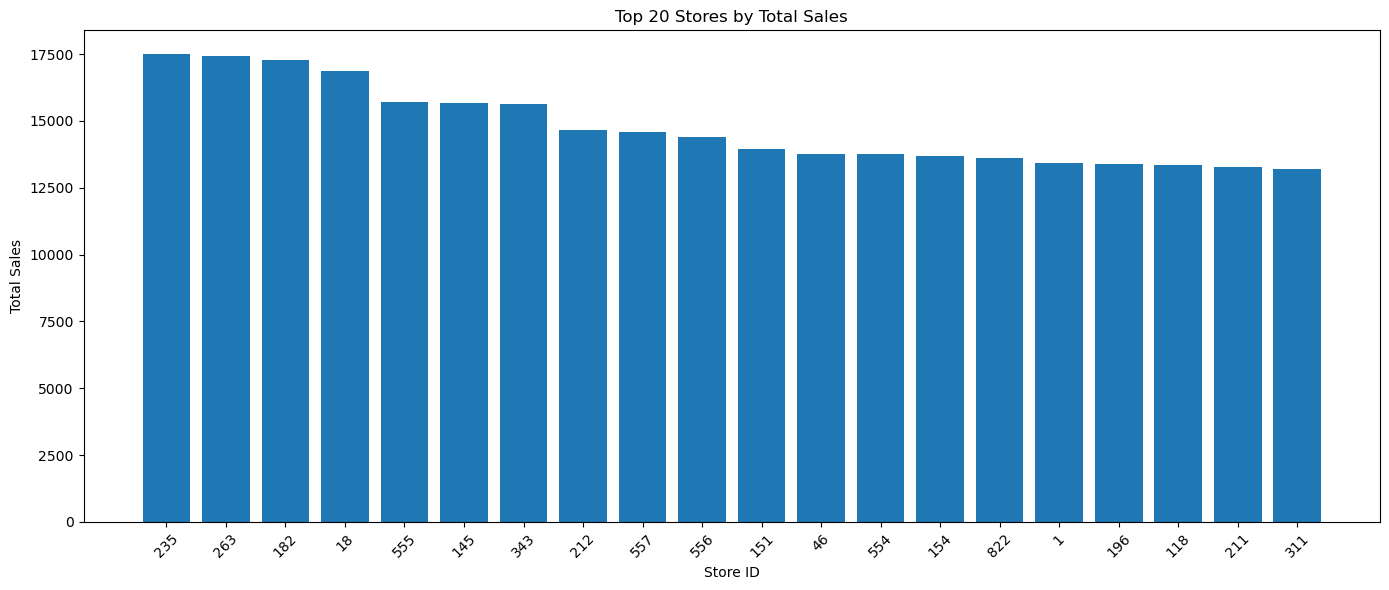

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(top_stores_sales["store_id"].astype(str), top_stores_sales["total_sales"])
plt.title("Top 20 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Stores with Highest Stockout Exposure

This analysis identifies stores with the highest total stockout hours.

Stores with high stockout exposure may represent operational locations where replenishment, availability monitoring, or demand planning should be improved.

In [98]:
top_stores_stockout = (
    store_performance
    .sort_values("total_stockout_hours", ascending=False)
    .head(20)
)

display(top_stores_stockout[
    [
        "city_id",
        "store_id",
        "active_products",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,city_id,store_id,active_products,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
5,0,18,164,16878.290,1.143516,48841,3.309011,45.359079,2.764228
650,12,409,116,11904.215,1.140250,46671,4.470402,40.296935,22.270115
141,0,263,161,17407.810,1.201367,46330,3.197378,43.547274,2.070393
85,0,182,160,17269.840,1.199294,46063,3.198819,46.847222,2.354167
123,0,235,162,17510.530,1.200997,44966,3.084088,43.758573,1.886145
164,0,343,152,15643.140,1.143504,43263,3.162500,40.972222,2.514620
57,0,151,141,13935.290,1.098132,43092,3.395745,45.539795,3.089046
51,0,145,148,15666.470,1.176161,42614,3.199249,44.977477,3.025526
111,0,212,140,14673.620,1.164573,40205,3.190873,45.087302,2.833333
36,0,118,140,13344.650,1.059099,39731,3.153254,44.960317,1.960317


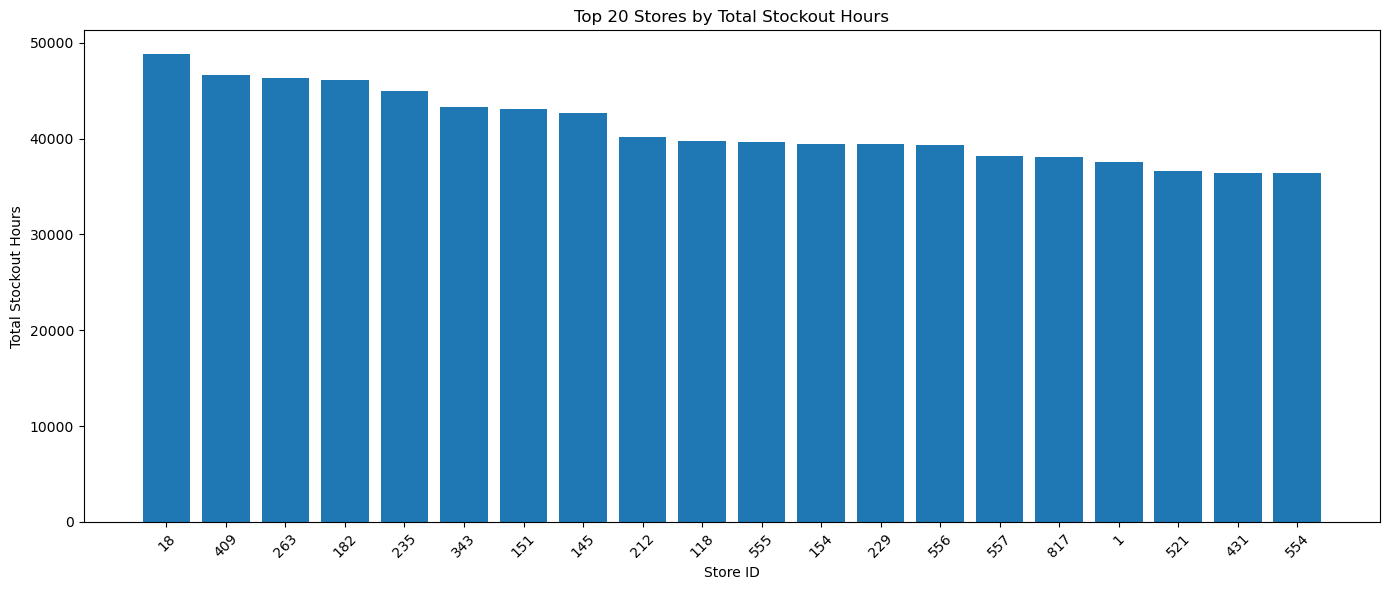

In [99]:
plt.figure(figsize=(14, 6))
plt.bar(top_stores_stockout["store_id"].astype(str), top_stores_stockout["total_stockout_hours"])
plt.title("Top 20 Stores by Total Stockout Hours")
plt.xlabel("Store ID")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Store Sales vs Stockout Relationship

This analysis compares store-level total sales with total stockout hours.

The objective is to determine whether high-sales stores also tend to experience higher stockout exposure, or whether stockout risk is concentrated in lower-performing stores.

In [100]:
store_sales_stockout_corr = store_performance[
    [
        "total_sales",
        "total_stockout_hours",
        "avg_sales",
        "avg_stockout_hours",
        "zero_sales_rate",
        "stockout_observation_rate"
    ]
].corr()

display(store_sales_stockout_corr)

,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,zero_sales_rate,stockout_observation_rate
total_sales,1.000000,0.962549,0.364958,-0.403789,-0.610520,-0.053355
total_stockout_hours,0.962549,1.000000,0.160982,-0.344831,-0.550616,-0.082525
avg_sales,0.364958,0.160982,1.000000,-0.283412,-0.418931,0.168068
avg_stockout_hours,-0.403789,-0.344831,-0.283412,1.000000,0.772504,0.471519
zero_sales_rate,-0.610520,-0.550616,-0.418931,0.772504,1.000000,0.010434
stockout_observation_rate,-0.053355,-0.082525,0.168068,0.471519,0.010434,1.000000


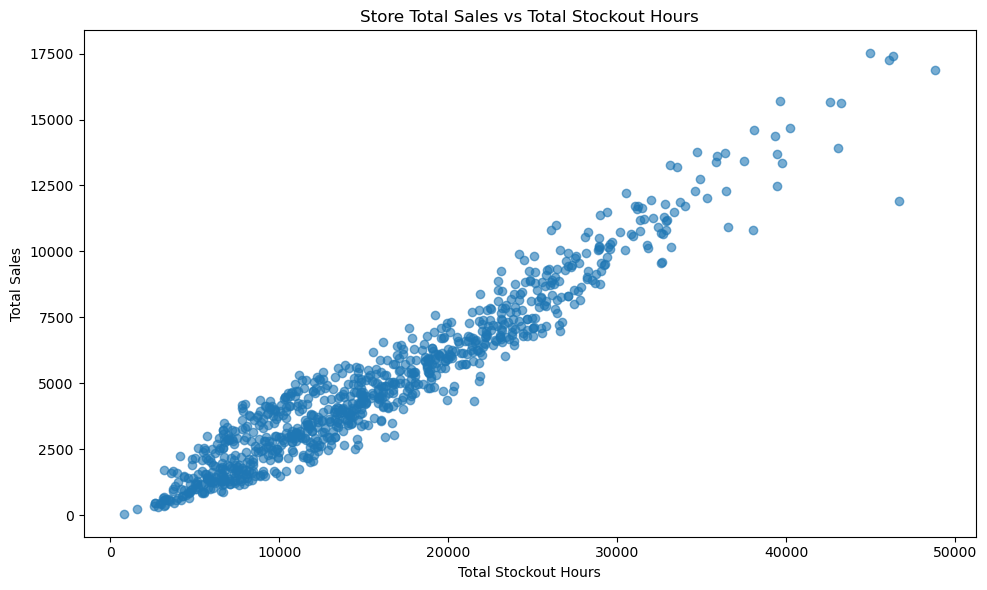

In [101]:
plt.figure(figsize=(10, 6))
plt.scatter(
    store_performance["total_stockout_hours"],
    store_performance["total_sales"],
    alpha=0.6
)

plt.title("Store Total Sales vs Total Stockout Hours")
plt.xlabel("Total Stockout Hours")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

#### Store Sales-Stockout Segmentation

Stores are segmented into four groups based on total sales and total stockout hours:

- High Sales / High Stockout
- High Sales / Low Stockout
- Low Sales / High Stockout
- Low Sales / Low Stockout

This segmentation helps identify stores that are both commercially important and operationally risky.

In [102]:
store_sales_threshold = store_performance["total_sales"].median()
store_stockout_threshold = store_performance["total_stockout_hours"].median()

def classify_store_sales_stockout(row):
    if row["total_sales"] >= store_sales_threshold and row["total_stockout_hours"] >= store_stockout_threshold:
        return "High Sales / High Stockout"
    elif row["total_sales"] >= store_sales_threshold and row["total_stockout_hours"] < store_stockout_threshold:
        return "High Sales / Low Stockout"
    elif row["total_sales"] < store_sales_threshold and row["total_stockout_hours"] >= store_stockout_threshold:
        return "Low Sales / High Stockout"
    else:
        return "Low Sales / Low Stockout"

store_performance["sales_stockout_segment"] = store_performance.apply(
    classify_store_sales_stockout,
    axis=1
)

store_segment_summary = (
    store_performance
    .groupby("sales_stockout_segment")
    .agg(
        store_count=("store_id", "count"),
        total_sales=("total_sales", "sum"),
        total_stockout_hours=("total_stockout_hours", "sum"),
        avg_sales=("avg_sales", "mean"),
        avg_stockout_hours=("avg_stockout_hours", "mean"),
        avg_zero_sales_rate=("zero_sales_rate", "mean")
    )
    .reset_index()
)

display(store_segment_summary)

,sales_stockout_segment,store_count,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,avg_zero_sales_rate
0,High Sales / High Stockout,406,3113898.142,9565843,1.007170,3.129819,3.675316
1,High Sales / Low Stockout,43,210166.645,529003,1.256060,3.143660,5.068899
2,Low Sales / High Stockout,43,168871.301,681956,0.817019,3.305803,6.321163
3,Low Sales / Low Stockout,406,1000724.699,3534734,0.935728,3.395068,7.299224


#### City-Level Store Performance

This analysis aggregates store performance at city level.

The objective is to identify cities with higher total sales, higher average store demand, and higher stockout exposure.

In [103]:
city_performance = (
    store_performance
    .groupby("city_id")
    .agg(
        store_count=("store_id", "count"),
        total_sales=("total_sales", "sum"),
        avg_store_sales=("total_sales", "mean"),
        total_stockout_hours=("total_stockout_hours", "sum"),
        avg_store_stockout_hours=("total_stockout_hours", "mean"),
        avg_zero_sales_rate=("zero_sales_rate", "mean"),
        avg_stockout_observation_rate=("stockout_observation_rate", "mean")
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)

display(city_performance)

,city_id,store_count,total_sales,avg_store_sales,total_stockout_hours,avg_store_stockout_hours,avg_zero_sales_rate,avg_stockout_observation_rate
0,0,290,2374623.838,8188.358062,7142894,24630.668966,3.022277,44.215029
12,12,107,429614.580,4015.089533,1516785,14175.560748,6.239606,44.889741
16,16,89,402280.885,4520.009944,1295752,14559.011236,4.787200,44.535117
6,6,43,221633.112,5154.258419,711744,16552.186047,6.358805,45.038822
13,13,90,209188.069,2324.311878,721357,8015.077778,5.785539,47.418109
11,11,38,190952.319,5025.061026,531727,13992.815789,4.206361,44.079710
3,3,101,161878.525,1602.757673,860244,8517.267327,11.720502,41.615044
4,4,34,136821.517,4024.162265,314278,9243.470588,6.016131,41.842462
15,15,17,68081.183,4004.775471,232837,13696.294118,5.518982,46.741389
5,5,15,53397.982,3559.865467,191414,12760.933333,5.239785,42.245668


plt.figure(figsize=(12, 6))
plt.bar(city_performance["city_id"].astype(str), city_performance["total_sales"])
plt.title("Total Sales by City")
plt.xlabel("City ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Save Store Performance Outputs

The store performance analysis outputs are saved locally to support reporting, Power BI dashboard development, and later inventory risk segmentation.

In [105]:
store_performance.to_csv(
    processed_folder / "eda_store_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

top_stores_sales.to_csv(
    processed_folder / "eda_top_stores_by_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

top_stores_stockout.to_csv(
    processed_folder / "eda_top_stores_by_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

store_segment_summary.to_csv(
    processed_folder / "eda_store_sales_stockout_segment_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

city_performance.to_csv(
    processed_folder / "eda_city_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Store performance analysis outputs saved successfully.")

Store performance analysis outputs saved successfully.


#### 11.4 Store Performance Analysis — Key Findings

The store performance analysis showed that sales and stockout exposure vary significantly across stores and cities.

The top-performing stores by total sales include stores such as `235`, `263`, `182`, `18`, and `555`. Store `235` recorded the highest total sales at approximately **17,510**, followed by store `263` with approximately **17,408**, and store `182` with approximately **17,270**. These stores represent important demand locations and should receive priority attention in store-level monitoring and replenishment planning.

The stockout exposure analysis showed that some of the highest-selling stores also experience high stockout hours. Store `18` recorded the highest total stockout hours at approximately **48,841**, followed by store `409` with approximately **46,671**, store `263` with approximately **46,330**, and store `182` with approximately **46,063**. This suggests that stockout risk is concentrated in stores with strong operational demand.

The store-level correlation analysis showed a very strong positive relationship between `total_sales` and `total_stockout_hours`, with a correlation of approximately **0.96**. This indicates that stores with higher total sales also tend to accumulate higher total stockout hours. This pattern suggests that stockout exposure is strongly connected to store activity and demand volume.

However, average stockout hours showed a negative relationship with total sales. This indicates that while high-sales stores accumulate more total stockout hours, some lower-sales stores may still experience relatively high average stockout pressure per observation. Therefore, both total stockout hours and average stockout hours should be considered when assessing store-level inventory risk.

The sales-stockout segmentation grouped stores into four categories:

- **High Sales / High Stockout**
- **High Sales / Low Stockout**
- **Low Sales / High Stockout**
- **Low Sales / Low Stockout**

The largest critical group was **High Sales / High Stockout**, containing **406 stores**. This segment contributed approximately **3.11 million** total sales and approximately **9.57 million** stockout hours. These stores are commercially important but also exposed to high product availability risk.

The **Low Sales / High Stockout** segment contained **43 stores**. Although these stores generated lower sales, they accumulated approximately **681,956** stockout hours. These stores may require operational investigation because lower observed sales could be partially related to availability constraints rather than weak demand alone.

City-level analysis showed that `city_id = 0` dominates total sales and stockout exposure. This city contains **290 stores**, generating approximately **2.37 million** total sales and approximately **7.14 million** stockout hours. Because this city has many more stores than other cities, both total sales and total stockout hours are naturally higher. Therefore, city-level analysis should consider both total values and average store-level metrics.

Overall, the store performance analysis confirms that store-level demand and stockout risk are closely connected. High-performing stores should be prioritized for replenishment monitoring, while stores with lower sales but high stockout exposure should be reviewed for potential availability or operational issues.

### 11.5 Category Performance Analysis

This section analyzes demand and stockout behavior across product hierarchy levels.

The dataset contains multiple category levels:

- `management_group_id`
- `first_category_id`
- `second_category_id`
- `third_category_id`

The objective is to understand which categories contribute the most to total sales, which categories experience the highest stockout exposure, and whether high-demand categories are also associated with higher inventory availability risk.

Category-level analysis is important because business teams often manage assortment, replenishment, and performance monitoring at category level rather than individual product level only.

In [106]:
management_group_performance = (
    daily_train
    .groupby("management_group_id")
    .agg(
        product_count=("product_id", "nunique"),
        total_observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

management_group_performance["stockout_observation_rate"] = (
    management_group_performance["stockout_observations"] /
    management_group_performance["total_observations"] * 100
)

management_group_performance["zero_sales_rate"] = (
    management_group_performance["zero_sales_observations"] /
    management_group_performance["total_observations"] * 100
)

management_group_performance = management_group_performance.sort_values(
    "total_sales",
    ascending=False
)

display(management_group_performance)

,management_group_id,product_count,total_observations,total_sales,avg_sales,median_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_discount,stockout_observation_rate,zero_sales_rate
6,6,367,2373300,2721947.509,1.146904,0.7,44.9,7462012,3.144150,1003169,114338,0.898340,42.268950,4.817680
5,5,182,949320,661201.278,0.696500,0.6,9.5,2915555,3.071204,457037,11525,0.919414,48.143619,1.214027
2,2,74,580230,635904.930,1.095953,0.7,27.0,2050260,3.533530,313916,14988,0.945726,54.101994,2.583114
0,0,108,331110,304789.418,0.920508,0.7,22.4,1194627,3.607946,117240,47702,0.900780,35.408173,14.406693
3,3,45,116640,87167.988,0.747325,0.6,12.2,298383,2.558153,41291,6952,0.966165,35.400377,5.960219
1,1,62,99000,53862.764,0.544068,0.5,5.2,254559,2.571303,35993,3902,0.947418,36.356566,3.941414
4,4,27,50400,28786.900,0.571169,0.5,4.0,136140,2.701190,23360,1353,0.829436,46.349206,2.684524


#### First-Level Category Performance

This analysis summarizes performance at the first category level.

The goal is to identify which broad product categories contribute most to total sales and which categories have higher stockout exposure.

In [107]:
first_category_performance = (
    daily_train
    .groupby("first_category_id")
    .agg(
        product_count=("product_id", "nunique"),
        total_observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

first_category_performance["stockout_observation_rate"] = (
    first_category_performance["stockout_observations"] /
    first_category_performance["total_observations"] * 100
)

first_category_performance["zero_sales_rate"] = (
    first_category_performance["zero_sales_observations"] /
    first_category_performance["total_observations"] * 100
)

first_category_performance = first_category_performance.sort_values(
    "total_sales",
    ascending=False
)

display(first_category_performance.head(20))

,first_category_id,product_count,total_observations,total_sales,avg_sales,median_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_discount,stockout_observation_rate,zero_sales_rate
4,4,95,979920,1159854.288,1.183621,0.8,16.9,3138317,3.202626,419671,45224,0.889106,42.827068,4.615071
20,20,75,497970,639484.020,1.284182,0.9,18.8,1579152,3.171179,217350,27101,0.881747,43.647208,5.442296
16,16,90,645930,472320.130,0.731225,0.6,9.5,2074616,3.211828,332329,5197,0.916986,51.449693,0.804576
29,29,10,314640,461595.600,1.467059,1.0,27.0,1297652,4.124244,204922,6568,0.937612,65.129036,2.087465
21,21,62,255870,459301.910,1.795060,0.6,44.9,787818,3.078978,119665,8640,0.869420,46.767890,3.376715
10,10,48,255420,189768.209,0.742965,0.6,27.5,892659,3.494867,99165,23749,0.938118,38.824289,9.298019
28,28,34,179820,186314.400,1.036116,0.9,22.4,799046,4.443588,74805,22954,0.957326,41.599933,12.764987
8,8,44,259650,181494.600,0.698997,0.6,5.8,738049,2.842476,97073,7629,0.918332,37.386097,2.938186
18,18,48,211410,125891.888,0.595487,0.5,7.1,575459,2.722005,87017,3749,0.931515,41.160305,1.773331
31,31,31,172080,118634.700,0.689416,0.6,6.4,486275,2.825866,67550,5700,0.961897,39.254998,3.312413


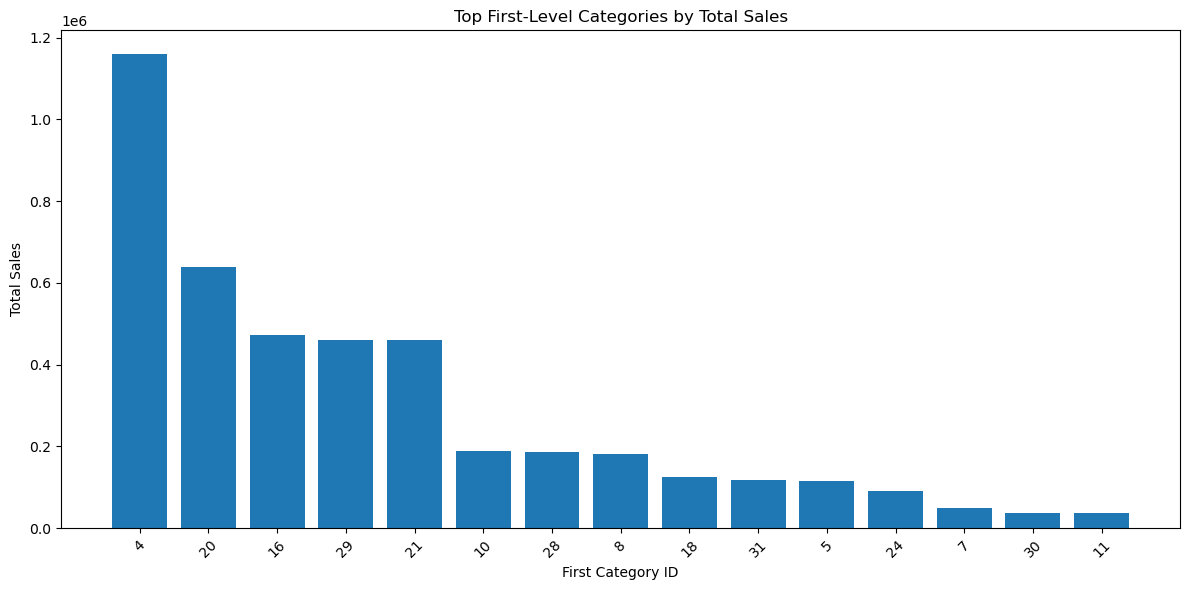

In [108]:
import matplotlib.pyplot as plt

top_first_categories_sales = first_category_performance.head(15)

plt.figure(figsize=(12, 6))
plt.bar(
    top_first_categories_sales["first_category_id"].astype(str),
    top_first_categories_sales["total_sales"]
)
plt.title("Top First-Level Categories by Total Sales")
plt.xlabel("First Category ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### First-Level Categories with Highest Stockout Exposure

This analysis identifies the first-level categories with the highest total stockout hours.

Categories with high stockout exposure may require closer monitoring because they may represent operational risk areas in the product hierarchy.
``

In [109]:
top_first_categories_stockout = (
    first_category_performance
    .sort_values("total_stockout_hours", ascending=False)
    .head(15)
)

display(top_first_categories_stockout[
    [
        "first_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate",
        "avg_discount"
    ]
])

,first_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate,avg_discount
4,4,95,1159854.288,1.183621,3138317,3.202626,42.827068,4.615071,0.889106
16,16,90,472320.130,0.731225,2074616,3.211828,51.449693,0.804576,0.916986
20,20,75,639484.020,1.284182,1579152,3.171179,43.647208,5.442296,0.881747
29,29,10,461595.600,1.467059,1297652,4.124244,65.129036,2.087465,0.937612
10,10,48,189768.209,0.742965,892659,3.494867,38.824289,9.298019,0.938118
28,28,34,186314.400,1.036116,799046,4.443588,41.599933,12.764987,0.957326
21,21,62,459301.910,1.795060,787818,3.078978,46.767890,3.376715,0.869420
8,8,44,181494.600,0.698997,738049,2.842476,37.386097,2.938186,0.918332
18,18,48,125891.888,0.595487,575459,2.722005,41.160305,1.773331,0.931515
31,31,31,118634.700,0.689416,486275,2.825866,39.254998,3.312413,0.961897


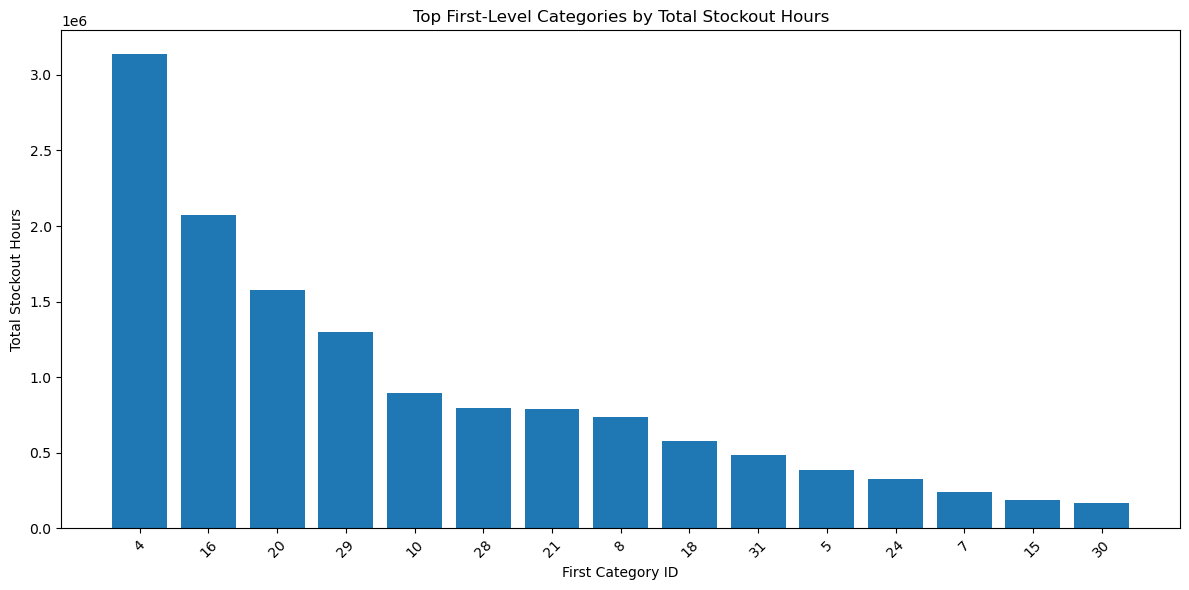

In [110]:
plt.figure(figsize=(12, 6))
plt.bar(
    top_first_categories_stockout["first_category_id"].astype(str),
    top_first_categories_stockout["total_stockout_hours"]
)
plt.title("Top First-Level Categories by Total Stockout Hours")
plt.xlabel("First Category ID")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Second-Level Category Performance

This analysis summarizes demand and stockout behavior at the second category level.

The second category level provides a more detailed view than the first category level, while still being broader than the third category level. This makes it useful for identifying mid-level category groups that drive sales, experience high stockout exposure, or require closer inventory monitoring.

The objective is to understand which second-level categories contribute most to total demand and whether these categories also carry higher stockout risk.

In [121]:
second_category_performance = (
    daily_train
    .groupby(["first_category_id", "second_category_id"])
    .agg(
        product_count=("product_id", "nunique"),
        total_observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

second_category_performance["stockout_observation_rate"] = (
    second_category_performance["stockout_observations"] /
    second_category_performance["total_observations"] * 100
)

second_category_performance["zero_sales_rate"] = (
    second_category_performance["zero_sales_observations"] /
    second_category_performance["total_observations"] * 100
)

second_category_performance = second_category_performance.sort_values(
    "total_sales",
    ascending=False
)

display(second_category_performance.head(20))


,first_category_id,second_category_id,product_count,total_observations,total_sales,avg_sales,median_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_discount,stockout_observation_rate,zero_sales_rate
7,4,28,77,756270,997477.088,1.318943,0.9,16.9,2300916,3.042453,325160,24048,0.880279,42.995227,3.179817
50,21,64,46,179820,416849.410,2.318148,0.8,44.9,548892,3.052452,80837,7132,0.833440,44.954399,3.966188
45,20,50,25,238500,354995.975,1.488453,0.9,18.8,900983,3.777706,115205,19497,0.878684,48.303983,8.174843
35,16,25,58,404730,289463.350,0.715201,0.6,9.5,1286964,3.179809,209164,3050,0.918606,51.679885,0.753589
77,29,76,7,199350,240606.100,1.206953,1.0,20.4,829243,4.159734,137447,2624,0.952652,68.947580,1.316278
78,29,78,3,115290,220989.500,1.916814,1.0,27.0,468409,4.062876,67475,3944,0.911606,58.526325,3.420939
18,8,29,36,239130,167924.110,0.702229,0.6,5.8,691215,2.890541,90844,7041,0.915960,37.989378,2.944424
8,4,53,18,223650,162377.200,0.726033,0.6,6.5,837401,3.744248,94511,21176,0.918956,42.258440,9.468366
37,16,27,26,205650,161341.310,0.784543,0.6,6.4,657769,3.198488,104081,1810,0.914320,50.610746,0.880136
76,28,72,11,123840,142996.300,1.154686,1.0,17.8,613691,4.955515,58453,13948,0.959977,47.200420,11.262920


#### Top Second-Level Categories by Sales

This analysis identifies the highest-performing second-level categories by total sales.

These categories may represent important mid-level product groups that should be considered in dashboard reporting, forecasting prioritization, and replenishment planning.

In [122]:
top_second_categories_sales = second_category_performance.head(20)

display(top_second_categories_sales[
    [
        "first_category_id",
        "second_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,first_category_id,second_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
7,4,28,77,997477.088,1.318943,2300916,3.042453,42.995227,3.179817
50,21,64,46,416849.410,2.318148,548892,3.052452,44.954399,3.966188
45,20,50,25,354995.975,1.488453,900983,3.777706,48.303983,8.174843
35,16,25,58,289463.350,0.715201,1286964,3.179809,51.679885,0.753589
77,29,76,7,240606.100,1.206953,829243,4.159734,68.947580,1.316278
78,29,78,3,220989.500,1.916814,468409,4.062876,58.526325,3.420939
18,8,29,36,167924.110,0.702229,691215,2.890541,37.989378,2.944424
8,4,53,18,162377.200,0.726033,837401,3.744248,42.258440,9.468366
37,16,27,26,161341.310,0.784543,657769,3.198488,50.610746,0.880136
76,28,72,11,142996.300,1.154686,613691,4.955515,47.200420,11.262920


In [123]:
top_second_categories_sales = second_category_performance.head(20)

display(top_second_categories_sales[
    [
        "first_category_id",
        "second_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,first_category_id,second_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
7,4,28,77,997477.088,1.318943,2300916,3.042453,42.995227,3.179817
50,21,64,46,416849.410,2.318148,548892,3.052452,44.954399,3.966188
45,20,50,25,354995.975,1.488453,900983,3.777706,48.303983,8.174843
35,16,25,58,289463.350,0.715201,1286964,3.179809,51.679885,0.753589
77,29,76,7,240606.100,1.206953,829243,4.159734,68.947580,1.316278
78,29,78,3,220989.500,1.916814,468409,4.062876,58.526325,3.420939
18,8,29,36,167924.110,0.702229,691215,2.890541,37.989378,2.944424
8,4,53,18,162377.200,0.726033,837401,3.744248,42.258440,9.468366
37,16,27,26,161341.310,0.784543,657769,3.198488,50.610746,0.880136
76,28,72,11,142996.300,1.154686,613691,4.955515,47.200420,11.262920


#### Top Second-Level Categories by Stockout Exposure

This analysis identifies second-level categories with the highest stockout exposure.

Categories with high stockout hours may represent important inventory risk areas, especially when they also contribute strongly to total sales.

In [124]:
top_second_categories_stockout = (
    second_category_performance
    .sort_values("total_stockout_hours", ascending=False)
    .head(20)
)

top_second_categories_stockout["category_label"] = (
    top_second_categories_stockout["first_category_id"].astype(str)
    + "-"
    + top_second_categories_stockout["second_category_id"].astype(str)
)

display(top_second_categories_stockout[
    [
        "first_category_id",
        "second_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,first_category_id,second_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
7,4,28,77,997477.088,1.318943,2300916,3.042453,42.995227,3.179817
35,16,25,58,289463.350,0.715201,1286964,3.179809,51.679885,0.753589
45,20,50,25,354995.975,1.488453,900983,3.777706,48.303983,8.174843
8,4,53,18,162377.200,0.726033,837401,3.744248,42.258440,9.468366
77,29,76,7,240606.100,1.206953,829243,4.159734,68.947580,1.316278
18,8,29,36,167924.110,0.702229,691215,2.890541,37.989378,2.944424
20,10,33,34,142191.559,0.796725,688858,3.859797,39.422872,11.974001
37,16,27,26,161341.310,0.784543,657769,3.198488,50.610746,0.880136
76,28,72,11,142996.300,1.154686,613691,4.955515,47.200420,11.262920
41,18,80,45,121343.978,0.599230,553373,2.732706,41.621728,1.790617


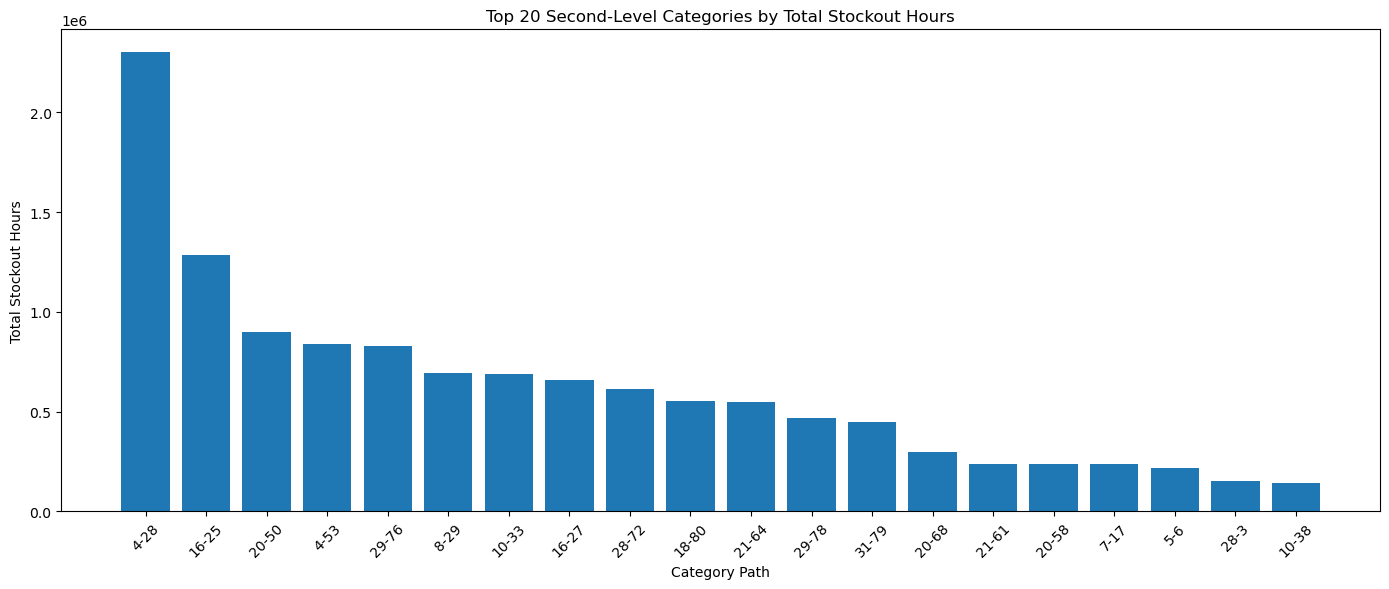

In [125]:
plt.figure(figsize=(14, 6))
plt.bar(
    top_second_categories_stockout["category_label"],
    top_second_categories_stockout["total_stockout_hours"]
)
plt.title("Top 20 Second-Level Categories by Total Stockout Hours")
plt.xlabel("Category Path")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Second-Level Category Sales vs Stockout Relationship

This analysis compares total sales and total stockout hours at the second category level.

The objective is to evaluate whether high-sales second-level categories are also associated with high stockout exposure.

In [126]:
second_category_sales_stockout_corr = second_category_performance[
    [
        "total_sales",
        "total_stockout_hours",
        "avg_sales",
        "avg_stockout_hours",
        "zero_sales_rate",
        "stockout_observation_rate"
    ]
].corr()

display(second_category_sales_stockout_corr)

,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,zero_sales_rate,stockout_observation_rate
total_sales,1.000000,0.937884,0.614930,0.308283,-0.155503,0.260025
total_stockout_hours,0.937884,1.000000,0.497591,0.396524,-0.173436,0.311205
avg_sales,0.614930,0.497591,1.000000,0.353815,-0.125079,0.249980
avg_stockout_hours,0.308283,0.396524,0.353815,1.000000,-0.137591,0.675580
zero_sales_rate,-0.155503,-0.173436,-0.125079,-0.137591,1.000000,-0.639335
stockout_observation_rate,0.260025,0.311205,0.249980,0.675580,-0.639335,1.000000


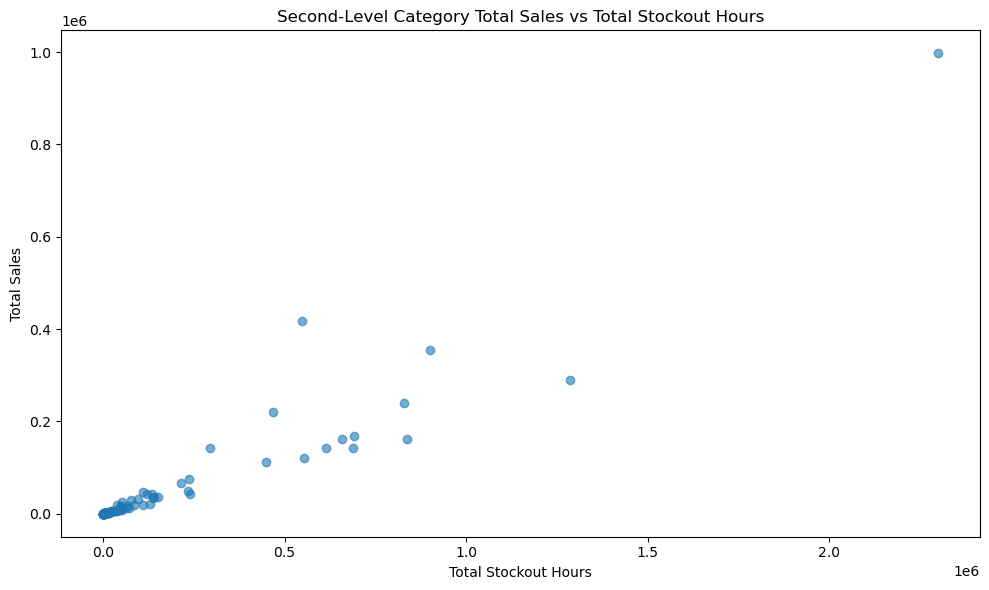

In [128]:
plt.figure(figsize=(10, 6))
plt.scatter(
    second_category_performance["total_stockout_hours"],
    second_category_performance["total_sales"],
    alpha=0.6
)

plt.title("Second-Level Category Total Sales vs Total Stockout Hours")
plt.xlabel("Total Stockout Hours")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

#### Third-Level Category Performance

The third category level provides a more granular view of product grouping.

This analysis helps identify more specific category groups that drive demand or experience high stockout exposure.

In [111]:
third_category_performance = (
    daily_train
    .groupby([
        "first_category_id",
        "second_category_id",
        "third_category_id"
    ])
    .agg(
        product_count=("product_id", "nunique"),
        total_observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        max_sales=("sale_amount", "max"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

third_category_performance["stockout_observation_rate"] = (
    third_category_performance["stockout_observations"] /
    third_category_performance["total_observations"] * 100
)

third_category_performance["zero_sales_rate"] = (
    third_category_performance["zero_sales_observations"] /
    third_category_performance["total_observations"] * 100
)

third_category_performance = third_category_performance.sort_values(
    "total_sales",
    ascending=False
)

display(third_category_performance.head(20))

,first_category_id,second_category_id,third_category_id,product_count,total_observations,total_sales,avg_sales,median_sales,max_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_discount,stockout_observation_rate,zero_sales_rate
19,4,28,81,13,135720,251195.111,1.850833,1.3,14.3,499262,3.678618,71245,4237,0.941449,52.494106,3.121869
158,21,64,184,7,32940,242669.324,7.367010,1.5,44.9,150023,4.554432,20930,1413,0.511135,63.539769,4.289617
210,29,76,60,5,181080,228735.700,1.263175,1.1,20.4,702649,3.880324,123178,992,0.954074,68.024078,0.547824
212,29,78,82,2,70560,183340.600,2.598365,1.7,27.0,212904,3.017347,33878,2938,0.873181,48.013039,4.163832
17,4,28,1,4,59760,173107.903,2.896719,2.7,16.9,176758,2.957798,27140,1686,0.923955,45.414993,2.821285
126,20,50,24,3,39420,155611.767,3.947533,3.7,18.8,138554,3.514815,21045,1010,0.978359,53.386606,2.562151
22,4,28,149,3,60660,151874.418,2.503700,2.3,13.7,220963,3.642648,32431,2858,0.748662,53.463567,4.711507
208,28,72,154,6,98910,127540.000,1.289455,1.2,17.8,546504,5.525265,52848,10620,0.988868,53.430391,10.737034
60,8,29,113,18,160020,120419.110,0.752525,0.6,5.3,498609,3.115917,65500,4829,0.908630,40.932383,3.017748
155,21,64,123,20,110340,93257.968,0.845187,0.7,10.2,300811,2.726219,43951,4733,0.888901,39.832336,4.289469


#### Top Third-Level Categories by Sales

This analysis identifies the most important granular categories by total sales.

These categories may be strong demand drivers and should be considered in category-level dashboarding and forecasting prioritization.

In [112]:
top_third_categories_sales = third_category_performance.head(20)

display(top_third_categories_sales[
    [
        "first_category_id",
        "second_category_id",
        "third_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,first_category_id,second_category_id,third_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
19,4,28,81,13,251195.111,1.850833,499262,3.678618,52.494106,3.121869
158,21,64,184,7,242669.324,7.367010,150023,4.554432,63.539769,4.289617
210,29,76,60,5,228735.700,1.263175,702649,3.880324,68.024078,0.547824
212,29,78,82,2,183340.600,2.598365,212904,3.017347,48.013039,4.163832
17,4,28,1,4,173107.903,2.896719,176758,2.957798,45.414993,2.821285
126,20,50,24,3,155611.767,3.947533,138554,3.514815,53.386606,2.562151
22,4,28,149,3,151874.418,2.503700,220963,3.642648,53.463567,4.711507
208,28,72,154,6,127540.000,1.289455,546504,5.525265,53.430391,10.737034
60,8,29,113,18,120419.110,0.752525,498609,3.115917,40.932383,3.017748
155,21,64,123,20,93257.968,0.845187,300811,2.726219,39.832336,4.289469


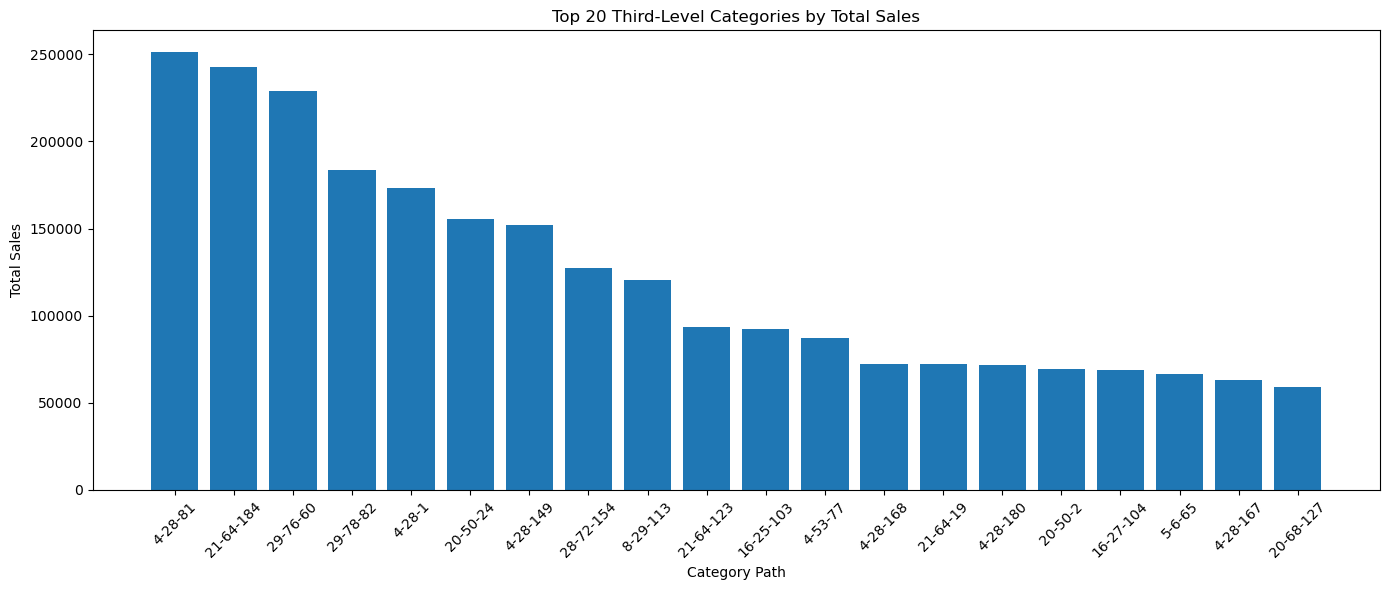

In [113]:
top_third_categories_sales["category_label"] = (
    top_third_categories_sales["first_category_id"].astype(str)
    + "-"
    + top_third_categories_sales["second_category_id"].astype(str)
    + "-"
    + top_third_categories_sales["third_category_id"].astype(str)
)

plt.figure(figsize=(14, 6))
plt.bar(
    top_third_categories_sales["category_label"],
    top_third_categories_sales["total_sales"]
)
plt.title("Top 20 Third-Level Categories by Total Sales")
plt.xlabel("Category Path")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Top Third-Level Categories by Stockout Exposure

This analysis identifies the granular categories with the highest total stockout exposure.

Categories with both high sales and high stockout exposure may represent important inventory risk areas.

In [115]:
top_third_categories_stockout = (
    third_category_performance
    .sort_values("total_stockout_hours", ascending=False)
    .head(20)
)

top_third_categories_stockout["category_label"] = (
    top_third_categories_stockout["first_category_id"].astype(str)
    + "-"
    + top_third_categories_stockout["second_category_id"].astype(str)
    + "-"
    + top_third_categories_stockout["third_category_id"].astype(str)
)

display(top_third_categories_stockout[
    [
        "first_category_id",
        "second_category_id",
        "third_category_id",
        "product_count",
        "total_sales",
        "avg_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate"
    ]
])

,first_category_id,second_category_id,third_category_id,product_count,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate
210,29,76,60,5,228735.700,1.263175,702649,3.880324,68.024078,0.547824
208,28,72,154,6,127540.000,1.289455,546504,5.525265,53.430391,10.737034
19,4,28,81,13,251195.111,1.850833,499262,3.678618,52.494106,3.121869
60,8,29,113,18,120419.110,0.752525,498609,3.115917,40.932383,3.017748
34,4,53,77,6,87015.780,0.745445,470956,4.034576,41.973786,12.757646
72,10,33,181,9,45260.050,0.663443,386663,5.667883,49.673116,21.523014
103,16,25,103,14,92374.090,0.747545,380419,3.078571,49.940924,0.746945
155,21,64,123,20,93257.968,0.845187,300811,2.726219,39.832336,4.289469
100,16,25,94,13,56070.610,0.714457,258915,3.299121,52.668196,0.986239
26,4,28,168,3,72424.670,0.878514,257167,3.119444,38.936196,3.067686


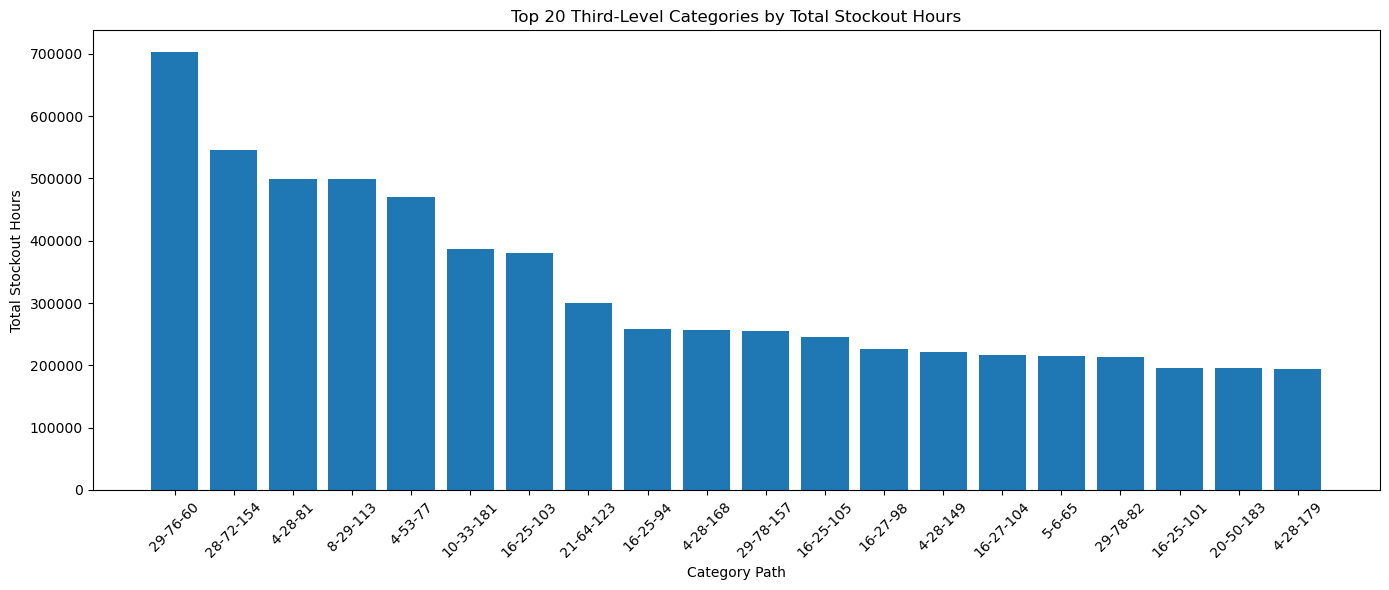

In [116]:
plt.figure(figsize=(14, 6))
plt.bar(
    top_third_categories_stockout["category_label"],
    top_third_categories_stockout["total_stockout_hours"]
)
plt.title("Top 20 Third-Level Categories by Total Stockout Hours")
plt.xlabel("Category Path")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Category Sales vs Stockout Relationship

This analysis compares category-level sales with stockout exposure.

The objective is to understand whether the highest-selling categories are also the categories with the highest stockout risk.

In [117]:
category_sales_stockout_corr = third_category_performance[
    [
        "total_sales",
        "total_stockout_hours",
        "avg_sales",
        "avg_stockout_hours",
        "zero_sales_rate",
        "stockout_observation_rate"
    ]
].corr()

display(category_sales_stockout_corr)

,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,zero_sales_rate,stockout_observation_rate
total_sales,1.000000,0.801974,0.717354,0.258430,-0.159765,0.320843
total_stockout_hours,0.801974,1.000000,0.290257,0.388673,-0.130336,0.363701
avg_sales,0.717354,0.290257,1.000000,0.159785,-0.072881,0.185126
avg_stockout_hours,0.258430,0.388673,0.159785,1.000000,0.056257,0.719318
zero_sales_rate,-0.159765,-0.130336,-0.072881,0.056257,1.000000,-0.466840
stockout_observation_rate,0.320843,0.363701,0.185126,0.719318,-0.466840,1.000000


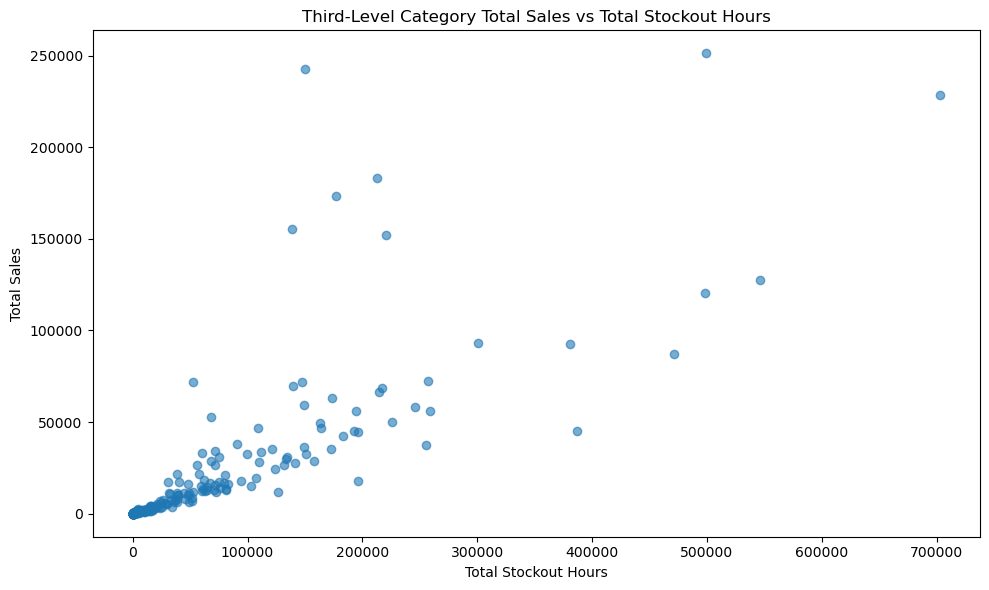

In [118]:
plt.figure(figsize=(10, 6))
plt.scatter(
    third_category_performance["total_stockout_hours"],
    third_category_performance["total_sales"],
    alpha=0.6
)

plt.title("Third-Level Category Total Sales vs Total Stockout Hours")
plt.xlabel("Total Stockout Hours")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

#### Category Sales-Stockout Segmentation

Third-level categories are segmented into four groups based on total sales and total stockout hours:

- High Sales / High Stockout
- High Sales / Low Stockout
- Low Sales / High Stockout
- Low Sales / Low Stockout

This segmentation helps identify category groups that are both commercially important and operationally risky.

In [119]:
category_sales_threshold = third_category_performance["total_sales"].median()
category_stockout_threshold = third_category_performance["total_stockout_hours"].median()

def classify_category_sales_stockout(row):
    if row["total_sales"] >= category_sales_threshold and row["total_stockout_hours"] >= category_stockout_threshold:
        return "High Sales / High Stockout"
    elif row["total_sales"] >= category_sales_threshold and row["total_stockout_hours"] < category_stockout_threshold:
        return "High Sales / Low Stockout"
    elif row["total_sales"] < category_sales_threshold and row["total_stockout_hours"] >= category_stockout_threshold:
        return "Low Sales / High Stockout"
    else:
        return "Low Sales / Low Stockout"

third_category_performance["sales_stockout_segment"] = third_category_performance.apply(
    classify_category_sales_stockout,
    axis=1
)

category_segment_summary = (
    third_category_performance
    .groupby("sales_stockout_segment")
    .agg(
        category_count=("third_category_id", "count"),
        product_count=("product_count", "sum"),
        total_sales=("total_sales", "sum"),
        total_stockout_hours=("total_stockout_hours", "sum"),
        avg_sales=("avg_sales", "mean"),
        avg_stockout_hours=("avg_stockout_hours", "mean"),
        avg_zero_sales_rate=("zero_sales_rate", "mean")
    )
    .reset_index()
)

display(category_segment_summary)

,sales_stockout_segment,category_count,product_count,total_sales,total_stockout_hours,avg_sales,avg_stockout_hours,avg_zero_sales_rate
0,High Sales / High Stockout,113,626,4380197.277,13739054,0.918481,3.035893,4.493677
1,High Sales / Low Stockout,4,10,16337.340,61985,0.633586,2.400636,3.751483
2,Low Sales / High Stockout,4,16,11728.520,78841,0.477941,3.256032,2.394582
3,Low Sales / Low Stockout,112,213,85397.650,431656,0.555025,2.703941,8.914698


#### Save Category Performance Outputs

The category performance outputs are saved locally to support reporting, Power BI dashboard development, and later inventory risk segmentation.

In [129]:
management_group_performance.to_csv(
    processed_folder / "eda_management_group_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

first_category_performance.to_csv(
    processed_folder / "eda_first_category_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

third_category_performance.to_csv(
    processed_folder / "eda_third_category_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

top_first_categories_stockout.to_csv(
    processed_folder / "eda_top_first_categories_by_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

second_category_performance.to_csv(
    processed_folder / "eda_second_category_performance.csv",
    index=False,
    encoding="utf-8-sig"
)

top_second_categories_sales.to_csv(
    processed_folder / "eda_top_second_categories_by_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

top_second_categories_stockout.to_csv(
    processed_folder / "eda_top_second_categories_by_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Second-level category performance outputs saved successfully.")
top_third_categories_sales.to_csv(
    processed_folder / "eda_top_third_categories_by_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

top_third_categories_stockout.to_csv(
    processed_folder / "eda_top_third_categories_by_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

category_segment_summary.to_csv(
    processed_folder / "eda_category_sales_stockout_segment_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Category performance analysis outputs saved successfully.")

Second-level category performance outputs saved successfully.
Category performance analysis outputs saved successfully.


#### 11.5 Category Performance Analysis — Key Findings

The category performance analysis showed that demand and stockout exposure are concentrated across specific product hierarchy groups. The dataset includes four product hierarchy levels: management group, first-level category, second-level category, and third-level category.

At the management group level, `management_group_id = 6` was the strongest contributor to total sales, generating approximately **2.72 million** total sales across **367 products**. This group also recorded the highest stockout exposure, with approximately **7.46 million** total stockout hours. This indicates that management group `6` is both a major demand driver and a major source of inventory availability risk.

At the first-category level, `first_category_id = 4` was the highest-performing category by total sales, generating approximately **1.16 million** total sales. It also recorded the highest total stockout hours at approximately **3.14 million**, showing that this category combines strong demand contribution with high stockout exposure.

Other important first-level categories included `first_category_id = 20`, `16`, `29`, and `21`. Category `20` generated approximately **639K** total sales, while category `16` generated approximately **472K** total sales. Category `29` generated approximately **462K** total sales and showed very high stockout exposure, with a stockout observation rate of approximately **65.13%**.

At the second-category level, category path `4-28` was the strongest performer by total sales, generating approximately **997K** total sales across **77 products**. This same second-level category also recorded the highest total stockout exposure, with approximately **2.30 million** stockout hours. This makes `4-28` one of the most important mid-level category groups from both a demand and inventory risk perspective.

Other high-performing second-level categories included `21-64`, `20-50`, `16-25`, `29-76`, and `29-78`. Category `21-64` generated approximately **417K** total sales with a high average sales value of approximately **2.32**, while category `20-50` generated approximately **355K** total sales and approximately **901K** stockout hours.

The second-level stockout analysis showed that category `16-25` had very high stockout exposure at approximately **1.29 million** stockout hours, despite generating lower total sales than the leading categories. Category `29-76` also showed strong inventory risk, with approximately **829K** stockout hours and a very high stockout observation rate of approximately **68.95%**. This suggests that some mid-level categories may require closer monitoring even if their total sales are not the highest.

The relationship between second-level category sales and stockout exposure was very strong. The correlation between `total_sales` and `total_stockout_hours` at the second-category level was approximately **0.94**, indicating that higher-selling second-level categories generally also experience higher stockout exposure. This confirms that inventory risk is strongly connected to category demand volume.

At the third-category level, the strongest category by total sales was category path `4-28-81`, generating approximately **251K** total sales. Other strong third-level categories included `21-64-184`, `29-76-60`, `29-78-82`, and `4-28-1`.

Stockout exposure at the third-category level was also concentrated. Category path `29-76-60` recorded the highest total stockout hours at approximately **703K**, followed by `28-72-154` with approximately **547K**, and `4-28-81` with approximately **499K** stockout hours.

The third-category sales and stockout relationship also showed a strong positive correlation. The correlation between `total_sales` and `total_stockout_hours` was approximately **0.80**, indicating that high-demand granular categories tend to experience higher stockout exposure.

The category sales-stockout segmentation showed that the most important segment was **High Sales / High Stockout**, containing **113 third-level categories** and **626 products**. This segment contributed approximately **4.38 million** total sales and approximately **13.74 million** stockout hours. This confirms that most category-level demand and stockout exposure are concentrated in commercially important categories.

The **Low Sales / High Stockout** segment contained only **4 categories** and **16 products**, generating approximately **11.7K** total sales and approximately **78.8K** stockout hours. These categories may require further investigation because observed sales may be constrained by product availability.

Overall, category performance analysis confirms that product hierarchy plays an important role in demand concentration and stockout risk. High-performing categories, especially those with high stockout exposure, should be prioritized in forecasting, replenishment planning, stockout monitoring, and Power BI dashboard design.

### 11.6 Stockout Analysis

This section analyzes stockout behavior across the prepared training dataset.

The objective is to understand how frequently stockouts occur, where stockout exposure is concentrated, and how product availability issues may affect observed sales behavior.

Stockout analysis is a core part of this project because observed sales may not always represent true customer demand. When a product is unavailable, recorded sales can be artificially low, creating a censored demand problem. Therefore, stockout indicators are essential for interpreting demand, building forecasting features, and designing an inventory risk framework.

In [130]:
stockout_summary = pd.DataFrame({
    "metric": [
        "total_observations",
        "observations_with_stockout",
        "observations_without_stockout",
        "stockout_observation_percent",
        "total_stockout_hours",
        "avg_stockout_hours",
        "median_stockout_hours",
        "max_stockout_hours"
    ],
    "value": [
        len(daily_train),
        (daily_train["stock_hour6_22_cnt"] > 0).sum(),
        (daily_train["stock_hour6_22_cnt"] == 0).sum(),
        (daily_train["stock_hour6_22_cnt"] > 0).mean() * 100,
        daily_train["stock_hour6_22_cnt"].sum(),
        daily_train["stock_hour6_22_cnt"].mean(),
        daily_train["stock_hour6_22_cnt"].median(),
        daily_train["stock_hour6_22_cnt"].max()
    ]
})

display(stockout_summary)

,metric,value
0,total_observations,4.500000e+06
1,observations_with_stockout,1.992006e+06
2,observations_without_stockout,2.507994e+06
3,stockout_observation_percent,4.426680e+01
4,total_stockout_hours,1.431154e+07
5,avg_stockout_hours,3.180341e+00
6,median_stockout_hours,0.000000e+00
7,max_stockout_hours,1.600000e+01


#### Stockout Severity Buckets

This step groups stockout observations into severity buckets based on the number of out-of-stock hours between 06:00 and 22:00.

The buckets are defined as:

- No Stockout: 0 hours
- Low Stockout: 1–4 hours
- Medium Stockout: 5–8 hours
- High Stockout: 9–15 hours
- Full-Day Stockout: 16 hours

This helps distinguish minor availability issues from severe product unavailability.

In [131]:
def classify_stockout_severity(hours):
    if hours == 0:
        return "No Stockout"
    elif hours <= 4:
        return "Low Stockout"
    elif hours <= 8:
        return "Medium Stockout"
    elif hours <= 15:
        return "High Stockout"
    else:
        return "Full-Day Stockout"

daily_train["stockout_severity"] = daily_train["stock_hour6_22_cnt"].apply(
    classify_stockout_severity
)

stockout_severity_summary = (
    daily_train
    .groupby("stockout_severity")
    .agg(
        observations=("stock_hour6_22_cnt", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum())
    )
    .reset_index()
)

stockout_severity_summary["observation_percent"] = (
    stockout_severity_summary["observations"] / len(daily_train) * 100
)

stockout_severity_summary["zero_sales_rate"] = (
    stockout_severity_summary["zero_sales_observations"] /
    stockout_severity_summary["observations"] * 100
)

display(stockout_severity_summary)

,stockout_severity,observations,total_sales,avg_sales,total_stockout_hours,avg_stockout_hours,zero_sales_observations,observation_percent,zero_sales_rate
0,Full-Day Stockout,181791,8366.040,0.046020,2908656,16.000000,148045,4.039800,81.436925
1,High Stockout,495641,379982.360,0.766648,5461849,11.019768,3052,11.014244,0.615768
2,Low Stockout,614871,855525.657,1.391390,1619266,2.633505,1814,13.663800,0.295021
3,Medium Stockout,699703,805700.259,1.151489,4321765,6.176571,905,15.548956,0.129341
4,No Stockout,2507994,2444086.471,0.974518,0,0.000000,46944,55.733200,1.871775


#### Daily Stockout Trend

This step analyzes stockout exposure by date.

The objective is to identify days with unusually high stockout pressure and understand how stockout exposure changes over time.

In [132]:
daily_stockout_summary = (
    daily_train
    .groupby("dt")
    .agg(
        total_observations=("stock_hour6_22_cnt", "count"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum())
    )
    .reset_index()
)

daily_stockout_summary["stockout_observation_rate"] = (
    daily_stockout_summary["stockout_observations"] /
    daily_stockout_summary["total_observations"] * 100
)

daily_stockout_summary["zero_sales_rate"] = (
    daily_stockout_summary["zero_sales_observations"] /
    daily_stockout_summary["total_observations"] * 100
)

display(daily_stockout_summary.head())
display(daily_stockout_summary.tail())

,dt,total_observations,stockout_observations,total_stockout_hours,avg_stockout_hours,total_sales,avg_sales,zero_sales_observations,stockout_observation_rate,zero_sales_rate
0,2024-03-28,50000,26294,202760,4.05520,35787.337,0.715747,3256,52.588,6.512
1,2024-03-29,50000,20871,156239,3.12478,34893.476,0.697870,3528,41.742,7.056
2,2024-03-30,50000,20072,148289,2.96578,47995.157,0.959903,2362,40.144,4.724
3,2024-03-31,50000,23100,178697,3.57394,49950.534,0.999011,2450,46.200,4.900
4,2024-04-01,50000,21756,159387,3.18774,35607.989,0.712160,3428,43.512,6.856


,dt,total_observations,stockout_observations,total_stockout_hours,avg_stockout_hours,total_sales,avg_sales,zero_sales_observations,stockout_observation_rate,zero_sales_rate
85,2024-06-21,50000,18189,118293,2.36586,58356.629,1.167133,1588,36.378,3.176
86,2024-06-22,50000,20550,145876,2.91752,70919.014,1.418380,1708,41.100,3.416
87,2024-06-23,50000,24581,179043,3.58086,70770.293,1.415406,1901,49.162,3.802
88,2024-06-24,50000,21854,152195,3.04390,51491.231,1.029825,2800,43.708,5.600
89,2024-06-25,50000,22791,156570,3.13140,58473.343,1.169467,2126,45.582,4.252


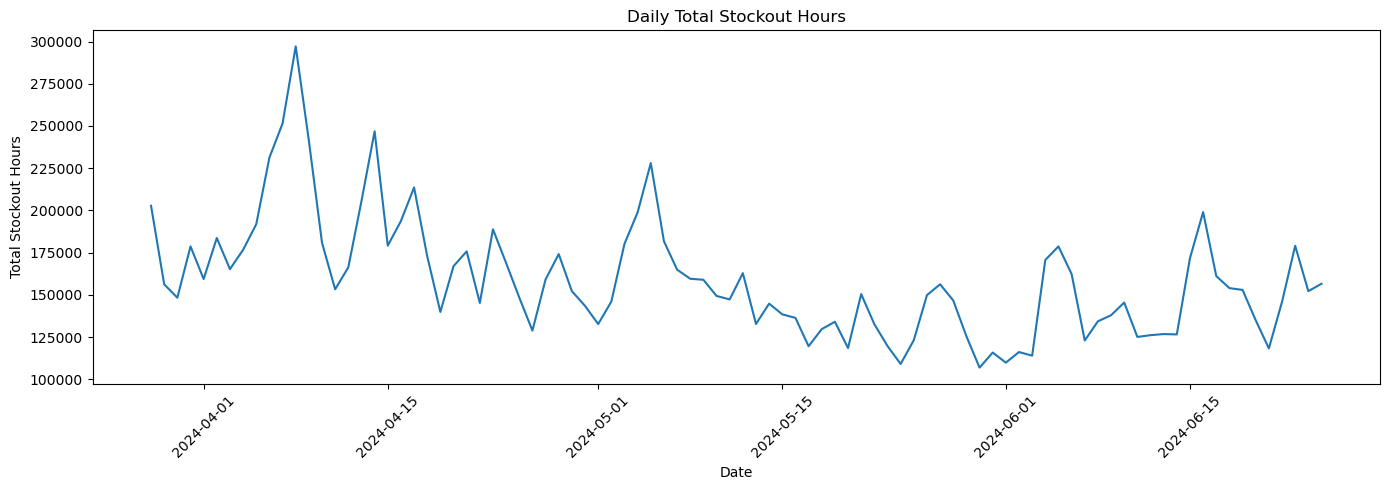

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_stockout_summary["dt"], daily_stockout_summary["total_stockout_hours"])
plt.title("Daily Total Stockout Hours")
plt.xlabel("Date")
plt.ylabel("Total Stockout Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Top Product-Store Combinations by Stockout Exposure

This analysis identifies the product-store combinations with the highest stockout exposure.

This level is important because inventory decisions are often made at the product-store level. A product may have high stockout risk in some stores but not in others.

In [134]:
product_store_stockout = (
    daily_train
    .groupby(["city_id", "store_id", "product_id"])
    .agg(
        total_days=("dt", "nunique"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        zero_sales_days=("sale_amount", lambda x: (x == 0).sum()),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_days=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        max_stockout_hours=("stock_hour6_22_cnt", "max")
    )
    .reset_index()
)

product_store_stockout["stockout_day_rate"] = (
    product_store_stockout["stockout_days"] /
    product_store_stockout["total_days"] * 100
)

product_store_stockout["zero_sales_rate"] = (
    product_store_stockout["zero_sales_days"] /
    product_store_stockout["total_days"] * 100
)

top_product_store_stockout = (
    product_store_stockout
    .sort_values("total_stockout_hours", ascending=False)
    .head(30)
)

display(top_product_store_stockout)

,city_id,store_id,product_id,total_days,total_sales,avg_sales,zero_sales_days,total_stockout_hours,avg_stockout_hours,stockout_days,max_stockout_hours,stockout_day_rate,zero_sales_rate
47622,16,519,151,90,58.00,0.644444,2,1397,15.522222,89,16,98.888889,2.222222
37414,12,230,757,90,32.70,0.363333,65,1193,13.255556,84,16,93.333333,72.222222
33327,6,805,129,90,33.80,0.375556,50,1155,12.833333,84,16,93.333333,55.555556
27371,3,712,333,90,42.26,0.469556,53,1155,12.833333,81,16,90.000000,58.888889
32597,6,508,757,90,33.40,0.371111,60,1149,12.766667,82,16,91.111111,66.666667
41070,12,484,757,90,33.30,0.370000,65,1141,12.677778,81,16,90.000000,72.222222
41566,12,876,757,90,34.10,0.378889,59,1117,12.411111,76,16,84.444444,65.555556
30989,5,734,757,90,19.98,0.222000,61,1114,12.377778,77,16,85.555556,67.777778
15446,0,382,129,90,45.70,0.507778,42,1110,12.333333,83,16,92.222222,46.666667
32196,6,493,757,90,41.40,0.460000,58,1107,12.300000,78,16,86.666667,64.444444


#### Stockout vs Sales Relationship

This analysis compares stockout exposure with observed sales.

The objective is to understand whether higher stockout exposure is associated with lower observed sales or whether stockout exposure is concentrated in high-demand areas.

In [135]:
stockout_sales_corr = daily_train[
    [
        "sale_amount",
        "stock_hour6_22_cnt",
        "discount",
        "holiday_flag",
        "activity_flag",
        "precpt",
        "avg_temperature",
        "avg_humidity",
        "avg_wind_level"
    ]
].corr()

display(stockout_sales_corr)

,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
sale_amount,1.000000,-0.100773,-0.332888,0.082988,0.008135,0.037044,0.056425,0.043337,-0.007699
stock_hour6_22_cnt,-0.100773,1.000000,-0.020071,0.020134,0.018569,0.007734,-0.062855,0.009143,-0.000808
discount,-0.332888,-0.020071,1.000000,-0.010126,-0.676811,-0.037313,-0.071303,-0.011006,-0.005156
holiday_flag,0.082988,0.020134,-0.010126,1.000000,0.017542,-0.026200,-0.001271,0.029452,-0.043259
activity_flag,0.008135,0.018569,-0.676811,0.017542,1.000000,0.013519,0.027347,0.009710,-0.024168
precpt,0.037044,0.007734,-0.037313,-0.026200,0.013519,1.000000,0.484788,0.488533,-0.039755
avg_temperature,0.056425,-0.062855,-0.071303,-0.001271,0.027347,0.484788,1.000000,0.058027,-0.069984
avg_humidity,0.043337,0.009143,-0.011006,0.029452,0.009710,0.488533,0.058027,1.000000,0.169846
avg_wind_level,-0.007699,-0.000808,-0.005156,-0.043259,-0.024168,-0.039755,-0.069984,0.169846,1.000000


In [136]:
sales_by_stockout_severity = (
    daily_train
    .groupby("stockout_severity")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean")
    )
    .reset_index()
)

sales_by_stockout_severity["zero_sales_rate"] = (
    sales_by_stockout_severity["zero_sales_observations"] /
    sales_by_stockout_severity["observations"] * 100
)

display(sales_by_stockout_severity)

,stockout_severity,observations,total_sales,avg_sales,median_sales,zero_sales_observations,avg_stockout_hours,zero_sales_rate
0,Full-Day Stockout,181791,8366.040,0.046020,0.00,148045,16.000000,81.436925
1,High Stockout,495641,379982.360,0.766648,0.50,3052,11.019768,0.615768
2,Low Stockout,614871,855525.657,1.391390,0.90,1814,2.633505,0.295021
3,Medium Stockout,699703,805700.259,1.151489,0.80,905,6.176571,0.129341
4,No Stockout,2507994,2444086.471,0.974518,0.68,46944,0.000000,1.871775


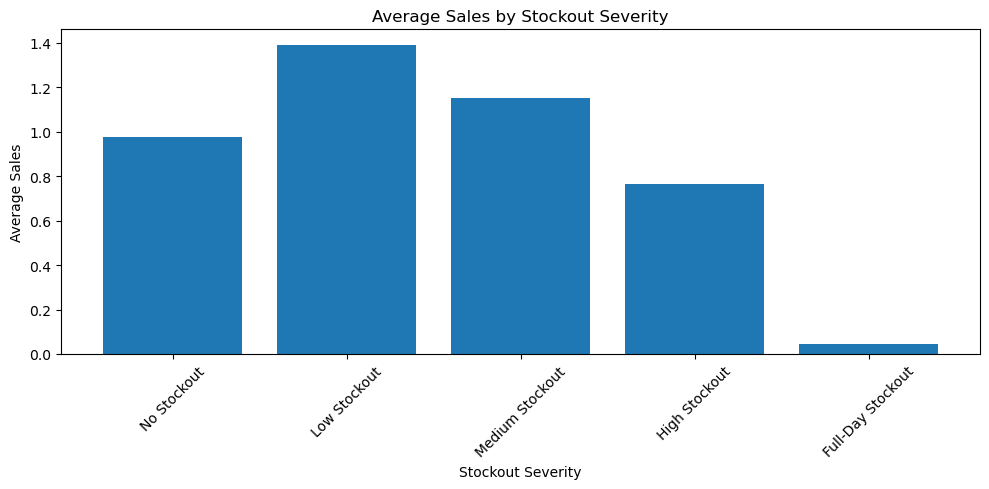

In [137]:
severity_order = [
    "No Stockout",
    "Low Stockout",
    "Medium Stockout",
    "High Stockout",
    "Full-Day Stockout"
]

sales_by_stockout_severity["stockout_severity"] = pd.Categorical(
    sales_by_stockout_severity["stockout_severity"],
    categories=severity_order,
    ordered=True
)

sales_by_stockout_severity = sales_by_stockout_severity.sort_values("stockout_severity")

plt.figure(figsize=(10, 5))
plt.bar(
    sales_by_stockout_severity["stockout_severity"],
    sales_by_stockout_severity["avg_sales"]
)
plt.title("Average Sales by Stockout Severity")
plt.xlabel("Stockout Severity")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Save Stockout Analysis Outputs

The stockout analysis outputs are saved locally to support report writing, Power BI dashboard development, and later inventory risk segmentation.

In [138]:
stockout_summary.to_csv(
    processed_folder / "eda_stockout_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

stockout_severity_summary.to_csv(
    processed_folder / "eda_stockout_severity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

daily_stockout_summary.to_csv(
    processed_folder / "eda_daily_stockout_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

product_store_stockout.to_csv(
    processed_folder / "eda_product_store_stockout_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

top_product_store_stockout.to_csv(
    processed_folder / "eda_top_product_store_stockout.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_by_stockout_severity.to_csv(
    processed_folder / "eda_sales_by_stockout_severity.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Stockout analysis outputs saved successfully.")

Stockout analysis outputs saved successfully.


#### 11.6 Stockout Analysis — Key Findings

The stockout analysis showed that stockout exposure is a significant operational issue in the prepared training dataset.

Out of **4.5 million observations**, approximately **1.99 million observations** recorded at least one stockout hour. This represents approximately **44.27%** of all product-store-date observations. Total stockout exposure reached approximately **14.31 million stockout hours**, with an average of **3.18 stockout hours** per observation. The maximum possible value of `stock_hour6_22_cnt` is **16**, which represents full stockout across the monitored window from 06:00 to 22:00.

The stockout severity analysis showed that **55.73%** of observations had no stockout. However, a large share of observations experienced some level of product unavailability. Low stockout cases represented approximately **13.66%** of observations, medium stockout cases represented approximately **15.55%**, high stockout cases represented approximately **11.01%**, and full-day stockout cases represented approximately **4.04%**.

Full-day stockout observations showed the strongest relationship with zero sales. In the full-day stockout bucket, average sales dropped to only **0.046**, and the zero-sales rate reached approximately **81.44%**. This indicates that when products are unavailable for the full monitored window, observed sales are heavily suppressed.

In contrast, low and medium stockout observations still recorded relatively strong sales. Low stockout observations had the highest average sales at approximately **1.39**, while medium stockout observations had average sales of approximately **1.15**. This suggests that mild or moderate stockout exposure may occur in situations with active demand, while full-day stockout is much more likely to suppress observed sales.

The daily stockout trend showed meaningful variation over time. Daily stockout hours ranged from relatively lower levels around **118K–156K** toward the later part of the training period to higher pressure days above **200K**, especially earlier in the period. The trend chart indicates that stockout exposure is not constant and should be considered as a time-varying operational signal.

At the product-store level, the highest stockout-risk combinations showed very severe availability issues. The most severe product-store combination recorded **1,397 stockout hours** over 90 days, averaging approximately **15.52 stockout hours per day**, with stockout occurring on **98.89%** of days. Several top product-store combinations had stockout day rates above **90%**, indicating repeated and persistent availability constraints.

The relationship between stockout hours and observed sales at the row level was slightly negative, with a correlation of approximately **-0.10** between `sale_amount` and `stock_hour6_22_cnt`. This indicates that higher stockout hours are generally associated with lower observed sales at the individual product-store-date level. However, earlier product, store, and category analyses showed that high-demand products, stores, and categories may still accumulate high total stockout exposure due to demand pressure.

Overall, the stockout analysis confirms that product availability is a major factor in interpreting sales behavior. Full-day stockouts strongly suppress observed sales and create censored demand risk, while partial stockouts may occur in high-demand situations. These findings support the need to include stockout-related features in forecasting and to build an inventory risk framework that combines demand strength with availability constraints.

### 11.7 Discount, Activity, and Holiday Impact

This section analyzes how discount levels, activity periods, and holidays are associated with sales demand and stockout exposure.

The objective is to understand whether business events such as promotional activity, holidays, and price changes are linked to higher sales, higher stockout risk, or different demand behavior.

This analysis is important because discount, activity, and holiday variables may become important features in the forecasting model and may also support business recommendations related to promotion planning and inventory preparation.

#### Discount Bucket Creation

The `discount` field is converted into grouped discount buckets to make the analysis easier to interpret.

Since values around 1 usually indicate standard pricing or no major discount, lower values may represent stronger discounting or promotional pricing.

In [139]:
def classify_discount_bucket(discount):
    if discount == 1:
        return "Standard Price"
    elif discount < 0.7:
        return "High Discount"
    elif discount < 0.9:
        return "Medium Discount"
    elif discount < 1:
        return "Low Discount"
    else:
        return "Above Standard"

daily_train["discount_bucket"] = daily_train["discount"].apply(classify_discount_bucket)

discount_bucket_counts = (
    daily_train["discount_bucket"]
    .value_counts()
    .reset_index()
)

discount_bucket_counts.columns = ["discount_bucket", "observations"]

display(discount_bucket_counts)

,discount_bucket,observations
0,Standard Price,2181121
1,Medium Discount,1276809
2,Low Discount,724658
3,High Discount,317378
4,Above Standard,34


#### Discount Impact Analysis

This analysis compares sales and stockout behavior across discount buckets.

The goal is to determine whether stronger discounting is associated with higher demand, higher stockout exposure, or different zero-sales behavior.

In [140]:
discount_impact_summary = (
    daily_train
    .groupby("discount_bucket")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

discount_impact_summary["stockout_observation_rate"] = (
    discount_impact_summary["stockout_observations"] /
    discount_impact_summary["observations"] * 100
)

discount_impact_summary["zero_sales_rate"] = (
    discount_impact_summary["zero_sales_observations"] /
    discount_impact_summary["observations"] * 100
)

display(discount_impact_summary)

,discount_bucket,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_discount,stockout_observation_rate,zero_sales_rate
0,Above Standard,34,21.600,0.635294,0.55,92,2.705882,14,0,1.070471,41.176471,0.000000
1,High Discount,317378,656658.600,2.069011,1.10,1064228,3.353188,148821,11473,0.584549,46.890774,3.614932
2,Low Discount,724658,742073.409,1.024033,0.70,2005735,2.767837,315410,15069,0.945472,43.525360,2.079464
3,Medium Discount,1276809,1278118.762,1.001026,0.70,4172095,3.267595,589232,42311,0.821040,46.148798,3.313808
4,Standard Price,2181121,1816788.416,0.832961,0.60,7069386,3.241171,938529,131907,1.000000,43.029662,6.047670


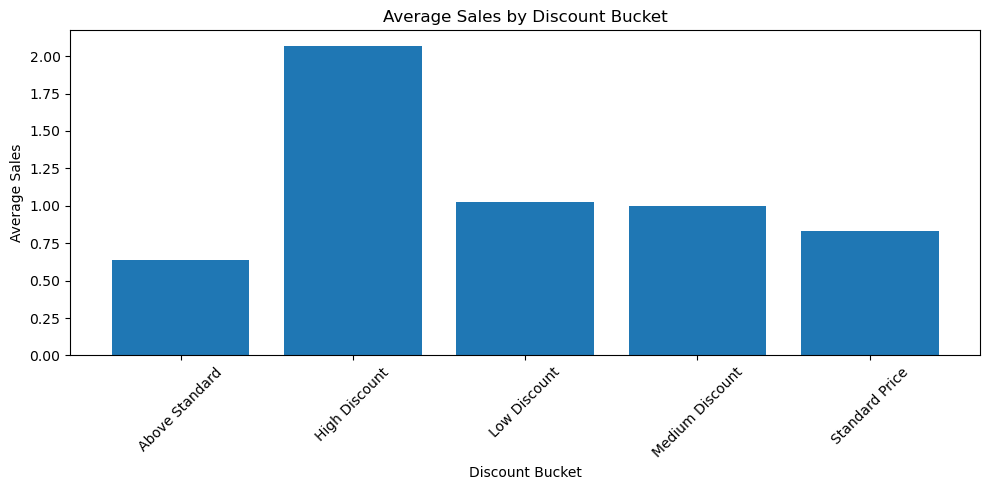

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(
    discount_impact_summary["discount_bucket"],
    discount_impact_summary["avg_sales"]
)
plt.title("Average Sales by Discount Bucket")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Activity Period Impact Analysis

This analysis compares demand and stockout behavior between activity and non-activity periods.

The goal is to evaluate whether activity periods are associated with higher sales, higher stockout exposure, or different discount behavior.

In [142]:
activity_impact_summary = (
    daily_train
    .groupby("activity_flag")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

activity_impact_summary["activity_status"] = activity_impact_summary["activity_flag"].map({
    0: "No Activity",
    1: "Activity"
})

activity_impact_summary["stockout_observation_rate"] = (
    activity_impact_summary["stockout_observations"] /
    activity_impact_summary["observations"] * 100
)

activity_impact_summary["zero_sales_rate"] = (
    activity_impact_summary["zero_sales_observations"] /
    activity_impact_summary["observations"] * 100
)

activity_impact_summary = activity_impact_summary[
    [
        "activity_status",
        "observations",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate",
        "avg_discount"
    ]
]

display(activity_impact_summary)

,activity_status,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate,avg_discount
0,No Activity,2797107,2768190.609,0.989662,0.6,8709473,3.113743,42.909978,5.100377,0.978828
1,Activity,1702893,1725470.178,1.013258,0.7,5602063,3.289733,46.495464,3.411665,0.799961


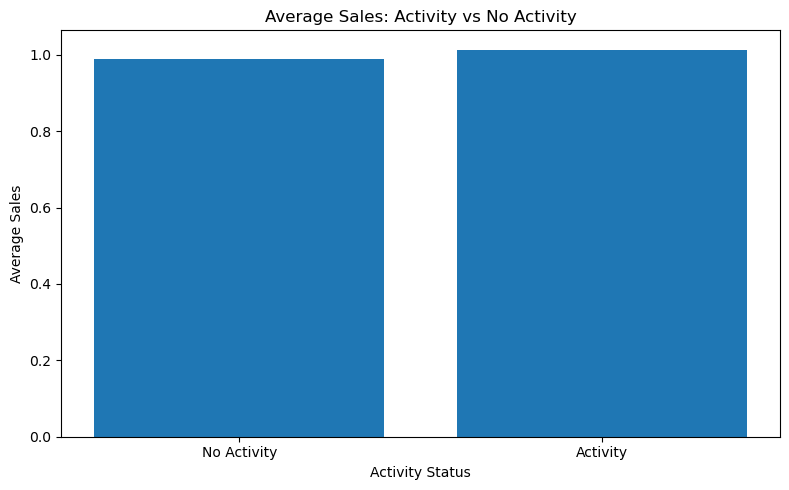

In [143]:
plt.figure(figsize=(8, 5))
plt.bar(
    activity_impact_summary["activity_status"],
    activity_impact_summary["avg_sales"]
)
plt.title("Average Sales: Activity vs No Activity")
plt.xlabel("Activity Status")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Holiday Impact Analysis

This analysis compares demand and stockout behavior between holiday and non-holiday observations.

The goal is to determine whether holidays are associated with higher demand and whether this higher demand creates additional stockout pressure.

In [144]:
holiday_impact_summary = (
    daily_train
    .groupby("holiday_flag")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

holiday_impact_summary["holiday_status"] = holiday_impact_summary["holiday_flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

holiday_impact_summary["stockout_observation_rate"] = (
    holiday_impact_summary["stockout_observations"] /
    holiday_impact_summary["observations"] * 100
)

holiday_impact_summary["zero_sales_rate"] = (
    holiday_impact_summary["zero_sales_observations"] /
    holiday_impact_summary["observations"] * 100
)

holiday_impact_summary = holiday_impact_summary[
    [
        "holiday_status",
        "observations",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate",
        "avg_discount"
    ]
]

display(holiday_impact_summary)

,holiday_status,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate,avg_discount
0,Non-Holiday,2950000,2696208.536,0.913969,0.6,9184109,3.113257,44.178271,4.735424,0.912082
1,Holiday,1550000,1797452.251,1.159647,0.8,5127427,3.308017,44.435290,3.939677,0.909351


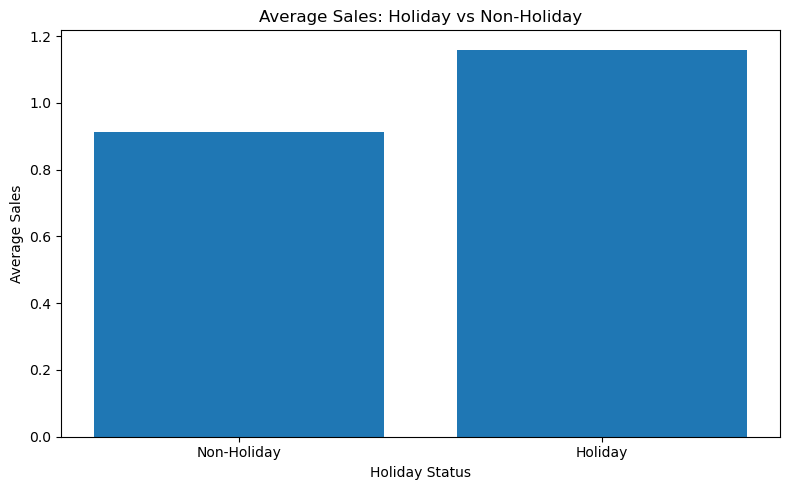

In [146]:
plt.figure(figsize=(8, 5))
plt.bar(
    holiday_impact_summary["holiday_status"],
    holiday_impact_summary["avg_sales"]
)
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Status")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

#### Combined Holiday and Activity Impact

This analysis evaluates the combined relationship between holiday status and activity periods.

The goal is to understand whether demand changes more strongly when holidays and activity periods overlap.

In [147]:
holiday_activity_summary = (
    daily_train
    .groupby(["holiday_flag", "activity_flag"])
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

holiday_activity_summary["holiday_status"] = holiday_activity_summary["holiday_flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

holiday_activity_summary["activity_status"] = holiday_activity_summary["activity_flag"].map({
    0: "No Activity",
    1: "Activity"
})

holiday_activity_summary["segment"] = (
    holiday_activity_summary["holiday_status"] + " / " +
    holiday_activity_summary["activity_status"]
)

holiday_activity_summary["stockout_observation_rate"] = (
    holiday_activity_summary["stockout_observations"] /
    holiday_activity_summary["observations"] * 100
)

holiday_activity_summary["zero_sales_rate"] = (
    holiday_activity_summary["zero_sales_observations"] /
    holiday_activity_summary["observations"] * 100
)

holiday_activity_summary = holiday_activity_summary[
    [
        "segment",
        "observations",
        "total_sales",
        "avg_sales",
        "median_sales",
        "total_stockout_hours",
        "avg_stockout_hours",
        "stockout_observation_rate",
        "zero_sales_rate",
        "avg_discount"
    ]
]

display(holiday_activity_summary)

,segment,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observation_rate,zero_sales_rate,avg_discount
0,Non-Holiday / No Activity,1851852,1673549.423,0.903717,0.6,5688170,3.071612,43.068993,5.370948,0.979330
1,Non-Holiday / Activity,1098148,1022659.113,0.931258,0.7,3495939,3.183486,46.048893,3.663714,0.798679
2,Holiday / No Activity,945255,1094641.186,1.158038,0.7,3021303,3.196284,42.598452,4.570301,0.977845
3,Holiday / Activity,604745,702811.065,1.162161,0.8,2106124,3.482665,47.306385,2.953972,0.802289


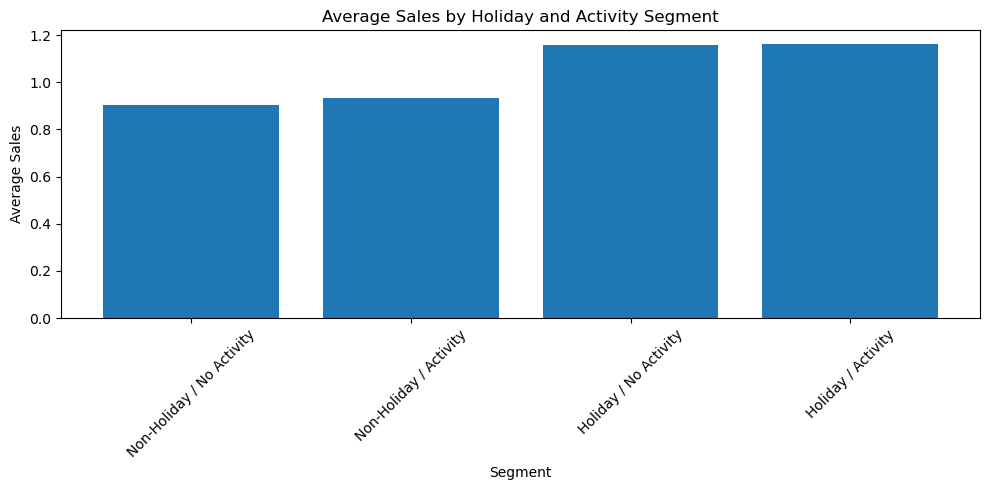

In [148]:
plt.figure(figsize=(10, 5))
plt.bar(
    holiday_activity_summary["segment"],
    holiday_activity_summary["avg_sales"]
)
plt.title("Average Sales by Holiday and Activity Segment")
plt.xlabel("Segment")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Sales Relationship with Discount, Activity, and Holiday Variables

This analysis reviews the correlation between sales and key business variables.

The goal is to understand whether discount, activity, and holiday indicators show meaningful relationships with sales and stockout behavior.

In [149]:
business_driver_corr = daily_train[
    [
        "sale_amount",
        "discount",
        "holiday_flag",
        "activity_flag",
        "stock_hour6_22_cnt"
    ]
].corr()

display(business_driver_corr)

,sale_amount,discount,holiday_flag,activity_flag,stock_hour6_22_cnt
sale_amount,1.000000,-0.332888,0.082988,0.008135,-0.100773
discount,-0.332888,1.000000,-0.010126,-0.676811,-0.020071
holiday_flag,0.082988,-0.010126,1.000000,0.017542,0.020134
activity_flag,0.008135,-0.676811,0.017542,1.000000,0.018569
stock_hour6_22_cnt,-0.100773,-0.020071,0.020134,0.018569,1.000000


#### Save Discount, Activity, and Holiday Impact Outputs

The outputs from this analysis are saved locally to support reporting, Power BI dashboard development, and later feature engineering.

In [150]:
discount_impact_summary.to_csv(
    processed_folder / "eda_discount_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

activity_impact_summary.to_csv(
    processed_folder / "eda_activity_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

holiday_impact_summary.to_csv(
    processed_folder / "eda_holiday_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

holiday_activity_summary.to_csv(
    processed_folder / "eda_holiday_activity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

business_driver_corr.to_csv(
    processed_folder / "eda_business_driver_correlation.csv",
    encoding="utf-8-sig"
)

print("Discount, activity, and holiday impact outputs saved successfully.")

Discount, activity, and holiday impact outputs saved successfully.


#### 11.7 Discount, Activity, and Holiday Impact — Key Findings

The discount, activity, and holiday impact analysis showed that business context variables are strongly relevant to demand behavior and stockout exposure.

The discount bucket analysis showed that stronger discounting is associated with higher average sales. The **High Discount** bucket recorded the highest average sales at approximately **2.07**, compared with approximately **0.83** for the **Standard Price** bucket. This suggests that stronger discounts are associated with higher observed demand.

The **High Discount** bucket also showed higher stockout exposure, with an average of approximately **3.35 stockout hours** and a stockout observation rate of approximately **46.89%**. This indicates that stronger discounting may increase demand pressure and contribute to product availability risk.

The **Standard Price** bucket represented the largest share of observations, with approximately **2.18 million records**. However, this bucket had the lowest average sales at approximately **0.83** and the highest zero-sales rate among the main buckets at approximately **6.05%**. This suggests that non-discounted observations may include more low-demand or slower-moving cases.

Activity-period analysis showed only a modest increase in average sales. Observations without activity periods recorded average sales of approximately **0.99**, while activity-period observations recorded average sales of approximately **1.01**. However, activity periods were associated with a much lower average discount factor, approximately **0.80** compared with **0.98** for non-activity periods. This suggests that activity periods are strongly linked to promotional pricing or deeper discounts.

Activity periods also showed slightly higher stockout exposure. Activity observations had an average of approximately **3.29 stockout hours**, compared with **3.11** for non-activity observations. The stockout observation rate was also higher during activity periods, at approximately **46.50%** compared with **42.91%** for non-activity periods.

Holiday analysis showed a clearer demand uplift. Holiday observations recorded average sales of approximately **1.16**, compared with approximately **0.91** for non-holiday observations. This indicates that holidays are associated with stronger demand. Holidays also showed slightly higher stockout exposure, with average stockout hours of approximately **3.31** compared with **3.11** for non-holidays.

The combined holiday and activity analysis showed that holiday periods had higher average sales regardless of activity status. The highest average sales appeared in the **Holiday / Activity** segment at approximately **1.16**, followed closely by **Holiday / No Activity** at approximately **1.16**. Non-holiday segments showed lower average sales, with **Non-Holiday / No Activity** at approximately **0.90** and **Non-Holiday / Activity** at approximately **0.93**.

The correlation analysis supported these findings. The correlation between `sale_amount` and `discount` was approximately **-0.33**. Since lower discount values represent deeper discounting, this negative correlation indicates that stronger discounts are associated with higher sales. The correlation between `sale_amount` and `holiday_flag` was positive at approximately **0.08**, suggesting a mild positive relationship between holidays and sales. The correlation between `sale_amount` and `activity_flag` was very small at approximately **0.01**, indicating that activity periods alone have limited direct association with sales after aggregation.

Overall, the analysis confirms that discounting and holidays are meaningful demand drivers. Strong discounts are associated with higher average sales and higher stockout exposure, while holidays are linked to higher demand and slightly higher inventory pressure. These variables should be considered during feature engineering, forecasting model development, and promotion-related inventory planning.

### 11.8 Weather Impact Analysis

This section analyzes the relationship between weather-related variables and demand behavior.

The reviewed weather variables are:

- `precpt`
- `avg_temperature`
- `avg_humidity`
- `avg_wind_level`

The objective is to understand whether weather conditions are associated with changes in sales demand, stockout exposure, or zero-sales behavior.

Weather analysis is important because external conditions may influence fresh retail demand. If weather variables show meaningful relationships with sales or stockout behavior, they may be useful later in feature engineering and forecasting model development.

#### Weather Variable Summary

This step summarizes the distribution of weather variables in the training dataset.

The purpose is to understand the basic range, average, and variability of each weather field before analyzing its relationship with demand.

In [151]:
weather_cols = [
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level"
]

weather_summary = daily_train[weather_cols].agg([
    "min",
    "max",
    "mean",
    "median",
    "std"
]).T.reset_index()

weather_summary = weather_summary.rename(columns={"index": "weather_variable"})

display(weather_summary)

,weather_variable,min,max,mean,median,std
0,precpt,0.00,42.50,3.698385,2.2977,3.683960
1,avg_temperature,12.06,30.88,22.279108,22.5000,3.593264
2,avg_humidity,27.35,100.00,74.450463,76.3600,10.098311
3,avg_wind_level,0.97,3.85,1.724542,1.6400,0.384573


#### Weather Correlation with Sales and Stockout

This step reviews the correlation between weather variables, sales, and stockout exposure.

The goal is to identify whether weather conditions show a meaningful relationship with demand or inventory availability issues.


In [152]:
weather_corr = daily_train[
    [
        "sale_amount",
        "stock_hour6_22_cnt",
        "precpt",
        "avg_temperature",
        "avg_humidity",
        "avg_wind_level"
    ]
].corr()

display(weather_corr)

,sale_amount,stock_hour6_22_cnt,precpt,avg_temperature,avg_humidity,avg_wind_level
sale_amount,1.000000,-0.100773,0.037044,0.056425,0.043337,-0.007699
stock_hour6_22_cnt,-0.100773,1.000000,0.007734,-0.062855,0.009143,-0.000808
precpt,0.037044,0.007734,1.000000,0.484788,0.488533,-0.039755
avg_temperature,0.056425,-0.062855,0.484788,1.000000,0.058027,-0.069984
avg_humidity,0.043337,0.009143,0.488533,0.058027,1.000000,0.169846
avg_wind_level,-0.007699,-0.000808,-0.039755,-0.069984,0.169846,1.000000


#### Temperature Bucket Analysis

Temperature is converted into buckets to make the relationship between temperature and demand easier to interpret.

This helps compare sales and stockout behavior across colder, moderate, and warmer temperature ranges.

In [153]:
daily_train["temperature_bucket"] = pd.cut(
    daily_train["avg_temperature"],
    bins=[-float("inf"), 18, 24, float("inf")],
    labels=["Low Temperature", "Medium Temperature", "High Temperature"]
)

temperature_impact_summary = (
    daily_train
    .groupby("temperature_bucket")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_temperature=("avg_temperature", "mean")
    )
    .reset_index()
)

temperature_impact_summary["stockout_observation_rate"] = (
    temperature_impact_summary["stockout_observations"] /
    temperature_impact_summary["observations"] * 100
)

temperature_impact_summary["zero_sales_rate"] = (
    temperature_impact_summary["zero_sales_observations"] /
    temperature_impact_summary["observations"] * 100
)

display(temperature_impact_summary)

,temperature_bucket,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_temperature,stockout_observation_rate,zero_sales_rate
0,Low Temperature,680031,586130.375,0.861917,0.6,2639141,3.880913,349645,35909,16.757395,51.416038,5.280495
1,Medium Temperature,2250217,2220708.099,0.986886,0.7,6954921,3.090778,967996,99679,21.183266,43.017896,4.429751
2,High Temperature,1569752,1686822.313,1.074579,0.7,4717474,3.005235,674365,65172,26.242039,42.959971,4.151739


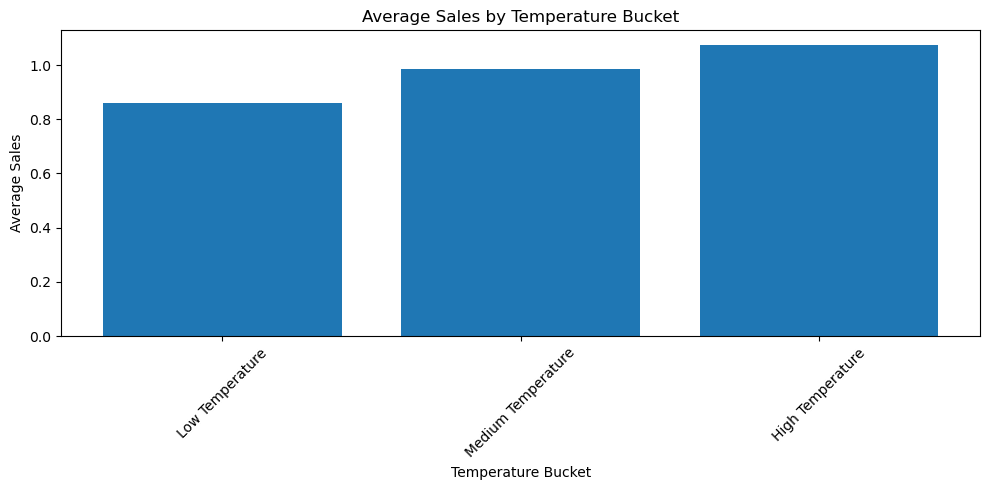

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(
    temperature_impact_summary["temperature_bucket"].astype(str),
    temperature_impact_summary["avg_sales"]
)
plt.title("Average Sales by Temperature Bucket")
plt.xlabel("Temperature Bucket")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Precipitation Bucket Analysis

Precipitation is grouped into buckets to compare demand behavior across different precipitation levels.

This helps evaluate whether higher precipitation is associated with changes in sales or stockout exposure.

In [155]:
daily_train["precpt_bucket"] = pd.cut(
    daily_train["precpt"],
    bins=[-float("inf"), 0, 2, 10, float("inf")],
    labels=["No Precipitation", "Low Precipitation", "Medium Precipitation", "High Precipitation"]
)

precpt_impact_summary = (
    daily_train
    .groupby("precpt_bucket")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_precpt=("precpt", "mean")
    )
    .reset_index()
)

precpt_impact_summary["stockout_observation_rate"] = (
    precpt_impact_summary["stockout_observations"] /
    precpt_impact_summary["observations"] * 100
)

precpt_impact_summary["zero_sales_rate"] = (
    precpt_impact_summary["zero_sales_observations"] /
    precpt_impact_summary["observations"] * 100
)

display(precpt_impact_summary)

,precpt_bucket,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_precpt,stockout_observation_rate,zero_sales_rate
0,No Precipitation,8353,6256.771,0.749045,0.50,29063,3.479349,3489,780,0.000000,41.769424,9.337962
1,Low Precipitation,1866937,1822125.962,0.975998,0.68,5833169,3.124459,805977,80547,1.237056,43.171087,4.314393
2,Medium Precipitation,2262344,2253887.747,0.996262,0.70,7254173,3.206485,1010553,103705,4.182329,44.668406,4.583962
3,High Precipitation,362366,411390.307,1.135289,0.70,1195131,3.298132,171987,15728,13.443205,47.462234,4.340363


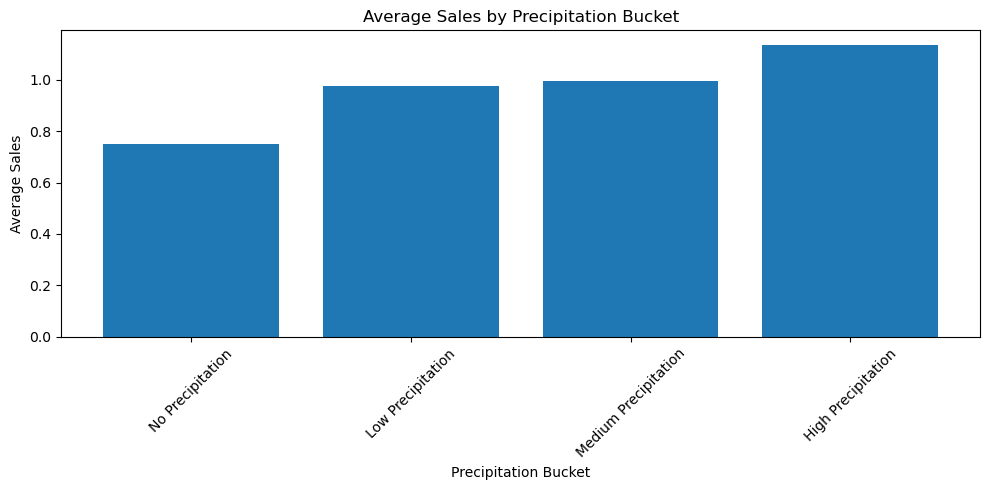

In [156]:
plt.figure(figsize=(10, 5))
plt.bar(
    precpt_impact_summary["precpt_bucket"].astype(str),
    precpt_impact_summary["avg_sales"]
)
plt.title("Average Sales by Precipitation Bucket")
plt.xlabel("Precipitation Bucket")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Humidity Bucket Analysis

Humidity is grouped into buckets to evaluate whether different humidity levels are associated with changes in sales or stockout exposure.

In [157]:
daily_train["humidity_bucket"] = pd.cut(
    daily_train["avg_humidity"],
    bins=[-float("inf"), 60, 80, float("inf")],
    labels=["Low Humidity", "Medium Humidity", "High Humidity"]
)

humidity_impact_summary = (
    daily_train
    .groupby("humidity_bucket")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_humidity=("avg_humidity", "mean")
    )
    .reset_index()
)

humidity_impact_summary["stockout_observation_rate"] = (
    humidity_impact_summary["stockout_observations"] /
    humidity_impact_summary["observations"] * 100
)

humidity_impact_summary["zero_sales_rate"] = (
    humidity_impact_summary["zero_sales_observations"] /
    humidity_impact_summary["observations"] * 100
)

display(humidity_impact_summary)

,humidity_bucket,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_humidity,stockout_observation_rate,zero_sales_rate
0,Low Humidity,256103,181475.337,0.708603,0.6,912456,3.562848,104824,27452,41.425538,40.930407,10.719125
1,Medium Humidity,2950513,2947511.051,0.998983,0.7,9097212,3.083265,1286679,110598,73.478615,43.608654,3.748433
2,High Humidity,1293384,1364674.399,1.055119,0.7,4301868,3.326056,600503,62710,83.206743,46.428825,4.848521


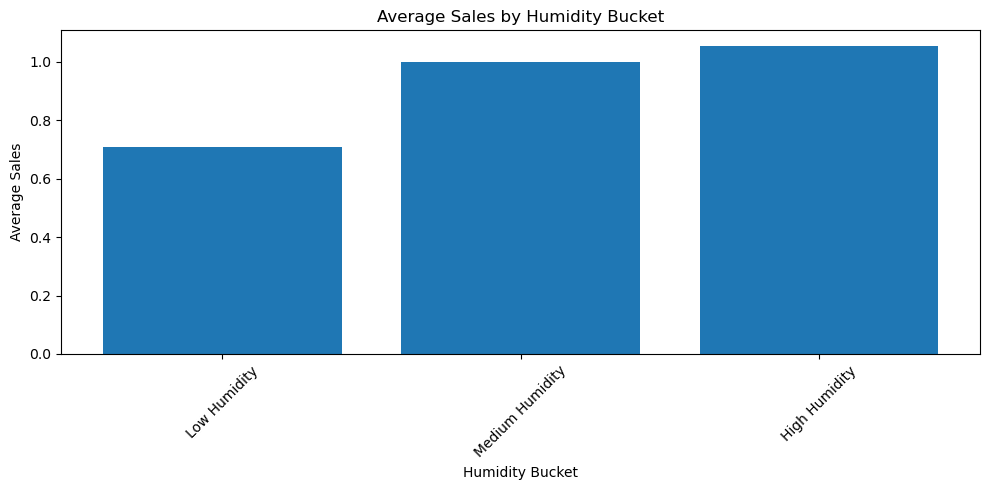

In [158]:
plt.figure(figsize=(10, 5))
plt.bar(
    humidity_impact_summary["humidity_bucket"].astype(str),
    humidity_impact_summary["avg_sales"]
)
plt.title("Average Sales by Humidity Bucket")
plt.xlabel("Humidity Bucket")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Wind Level Bucket Analysis

Wind level is grouped into buckets to evaluate whether wind conditions are associated with differences in demand or stockout exposure.

In [159]:
daily_train["wind_bucket"] = pd.cut(
    daily_train["avg_wind_level"],
    bins=[-float("inf"), 1.5, 2.5, float("inf")],
    labels=["Low Wind", "Medium Wind", "High Wind"]
)

wind_impact_summary = (
    daily_train
    .groupby("wind_bucket")
    .agg(
        observations=("sale_amount", "count"),
        total_sales=("sale_amount", "sum"),
        avg_sales=("sale_amount", "mean"),
        median_sales=("sale_amount", "median"),
        total_stockout_hours=("stock_hour6_22_cnt", "sum"),
        avg_stockout_hours=("stock_hour6_22_cnt", "mean"),
        stockout_observations=("stock_hour6_22_cnt", lambda x: (x > 0).sum()),
        zero_sales_observations=("sale_amount", lambda x: (x == 0).sum()),
        avg_wind_level=("avg_wind_level", "mean")
    )
    .reset_index()
)

wind_impact_summary["stockout_observation_rate"] = (
    wind_impact_summary["stockout_observations"] /
    wind_impact_summary["observations"] * 100
)

wind_impact_summary["zero_sales_rate"] = (
    wind_impact_summary["zero_sales_observations"] /
    wind_impact_summary["observations"] * 100
)

display(wind_impact_summary)

,wind_bucket,observations,total_sales,avg_sales,median_sales,total_stockout_hours,avg_stockout_hours,stockout_observations,zero_sales_observations,avg_wind_level,stockout_observation_rate,zero_sales_rate
0,Low Wind,1511350,1499684.352,0.992281,0.7,4886086,3.232928,672059,67048,1.358609,44.467463,4.436299
1,Medium Wind,2782673,2801659.272,1.006823,0.7,8719134,3.133366,1225809,120170,1.851540,44.051493,4.318510
2,High Wind,205977,192317.163,0.933683,0.6,706316,3.429101,94138,13542,2.693876,45.703161,6.574520


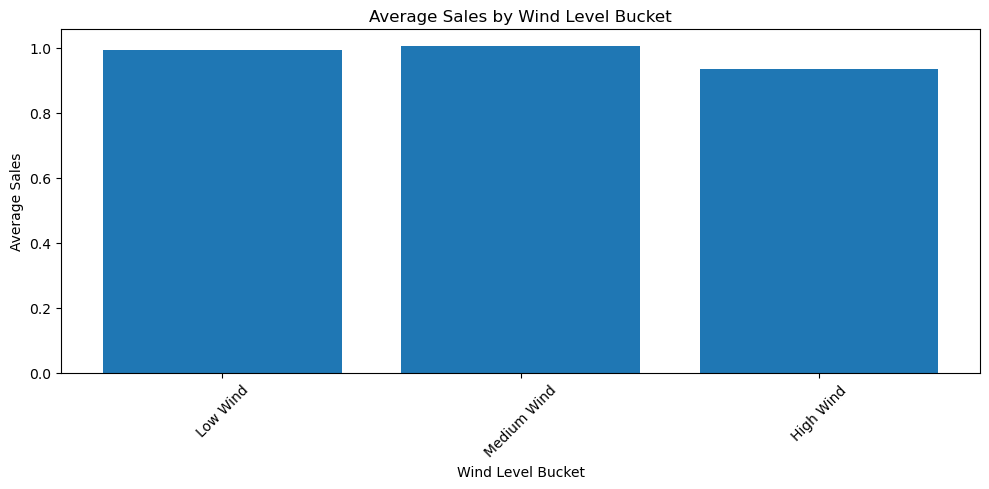

In [160]:
plt.figure(figsize=(10, 5))
plt.bar(
    wind_impact_summary["wind_bucket"].astype(str),
    wind_impact_summary["avg_sales"]
)
plt.title("Average Sales by Wind Level Bucket")
plt.xlabel("Wind Level Bucket")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Save Weather Impact Outputs

The weather impact analysis outputs are saved locally to support reporting, Power BI dashboard development, and later feature engineering.

In [161]:
weather_summary.to_csv(
    processed_folder / "eda_weather_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

weather_corr.to_csv(
    processed_folder / "eda_weather_correlation.csv",
    encoding="utf-8-sig"
)

temperature_impact_summary.to_csv(
    processed_folder / "eda_temperature_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

precpt_impact_summary.to_csv(
    processed_folder / "eda_precipitation_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

humidity_impact_summary.to_csv(
    processed_folder / "eda_humidity_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

wind_impact_summary.to_csv(
    processed_folder / "eda_wind_impact_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Weather impact analysis outputs saved successfully.")

Weather impact analysis outputs saved successfully.


#### 11.8 Weather Impact Analysis — Key Findings

The weather impact analysis evaluated the relationship between weather-related variables and demand behavior in the prepared training dataset.

The reviewed weather variables were precipitation, average temperature, average humidity, and average wind level. The weather summary showed that temperature ranged from approximately **12.06** to **30.88**, humidity ranged from **27.35** to **100**, precipitation ranged from **0** to **42.50**, and wind level ranged from **0.97** to **3.85**.

The correlation analysis showed that weather variables have relatively weak direct relationships with sales and stockout exposure. The strongest positive correlation with sales was observed for average temperature, with a correlation of approximately **0.056**, followed by humidity at approximately **0.043** and precipitation at approximately **0.037**. Wind level showed almost no relationship with sales, with a correlation of approximately **-0.008**.

The relationship between stockout hours and weather variables was also weak. Average temperature had a small negative correlation with stockout hours of approximately **-0.063**, while precipitation, humidity, and wind level showed near-zero correlations with stockout exposure. This suggests that weather may have some influence on demand behavior, but it is not a dominant standalone driver in the dataset.

Temperature bucket analysis showed that average sales increased as temperature increased. Low Temperature observations recorded average sales of approximately **0.86**, Medium Temperature observations recorded average sales of approximately **0.99**, and High Temperature observations recorded average sales of approximately **1.07**. At the same time, average stockout hours decreased from approximately **3.88** in the Low Temperature bucket to approximately **3.01** in the High Temperature bucket.

Precipitation bucket analysis showed that higher precipitation levels were associated with higher average sales. High Precipitation observations recorded the highest average sales at approximately **1.14**, compared with approximately **0.75** for No Precipitation observations. However, the No Precipitation bucket contained very few observations, so this result should be interpreted carefully.

Humidity bucket analysis showed that average sales increased with higher humidity. Low Humidity observations recorded average sales of approximately **0.71**, Medium Humidity observations recorded average sales of approximately **1.00**, and High Humidity observations recorded average sales of approximately **1.06**. High Humidity observations also had slightly higher stockout exposure, with an average of approximately **3.33 stockout hours**.

Wind level analysis showed limited demand variation across wind buckets. Medium Wind observations recorded the highest average sales at approximately **1.01**, while High Wind observations recorded lower average sales at approximately **0.93** and a higher zero-sales rate of approximately **6.57%**. However, wind level appears to be a weaker demand driver compared with temperature, precipitation, and humidity.

Overall, the weather impact analysis suggests that weather variables may provide useful contextual signals for forecasting, especially temperature, precipitation, and humidity. However, the direct correlations with sales and stockout exposure are relatively weak, meaning weather should be treated as a supporting feature rather than a primary demand driver.

## 11.9 EDA Key Findings

The Exploratory Data Analysis phase provided a comprehensive understanding of demand behavior, stockout exposure, product and store performance, category contribution, business event impact, and weather-related patterns.

### Overall Demand Trends

The prepared training dataset showed a stable daily structure with **50,000 product-store observations per day**, covering **865 products** across **898 stores**. Total training sales reached approximately **4.49 million normalized sales units**, with average daily sales of approximately **49.93K**. Daily sales ranged from approximately **34.89K** to **72.94K**, showing meaningful temporal variation across the training period.

Stockout exposure was also substantial, reaching approximately **14.31 million total stockout hours**, with an average of approximately **159K stockout hours per day**. This confirmed that product availability is a major factor in interpreting observed sales behavior.

### Seasonality Patterns

The seasonality analysis showed clear calendar-based demand patterns. Weekend days recorded higher average sales than weekdays. Weekend observations had average sales of approximately **1.19**, compared with approximately **0.92** for weekdays.

Holiday periods also showed stronger demand. Holiday observations recorded average sales of approximately **1.16**, compared with approximately **0.91** for non-holiday observations. Holiday and weekend periods also showed higher stockout exposure, suggesting that stronger demand may create additional inventory pressure.

### Product Performance

Product-level demand was highly concentrated. The top-selling products included `product_id = 267`, `4`, `300`, `117`, and `215`. Product `267` recorded approximately **183.4K** total sales, while product `4` recorded approximately **183.3K**.

ABC classification showed that **121 products** contributed approximately **79.86%** of total sales, while **577 products** contributed only approximately **5.04%**. This confirms that a relatively small group of products drives most of the demand and should receive higher forecasting and inventory monitoring priority.

Product-level sales and stockout exposure were strongly related. The correlation between product total sales and total stockout hours was approximately **0.72**, indicating that high-demand products often experience higher stockout exposure.

### Store Performance

Store performance analysis showed that demand and stockout exposure vary meaningfully across store locations. The highest-sales stores included stores such as `235`, `263`, `182`, `18`, and `555`.

Store-level total sales and total stockout hours had a very strong positive correlation of approximately **0.96**, suggesting that high-sales stores also tend to accumulate higher stockout exposure. The **High Sales / High Stockout** store segment contained **406 stores**, contributing approximately **3.11 million** total sales and approximately **9.57 million** stockout hours.

City-level analysis showed that `city_id = 0` dominated total sales and stockout exposure, generating approximately **2.37 million** total sales and approximately **7.14 million** stockout hours. However, this city also contained the largest number of stores, so average store-level metrics should be considered alongside total values.

### Category Performance

Category analysis confirmed that product hierarchy is strongly connected to both demand contribution and stockout risk.

At the management group level, `management_group_id = 6` was the strongest contributor, generating approximately **2.72 million** total sales and approximately **7.46 million** stockout hours.

At the first-category level, `first_category_id = 4` was the highest-performing category, generating approximately **1.16 million** total sales and approximately **3.14 million** stockout hours.

At the second-category level, category path `4-28` was the strongest category group, generating approximately **997K** total sales and approximately **2.30 million** stockout hours. The correlation between second-level category sales and stockout hours was approximately **0.94**, showing a very strong relationship between category demand and stockout exposure.

At the third-category level, category path `4-28-81` generated the highest total sales at approximately **251K**, while category path `29-76-60` recorded the highest stockout exposure at approximately **703K** stockout hours. The correlation between third-level category sales and stockout hours was approximately **0.80**.

### Stockout Analysis

Stockout analysis confirmed that product availability is a major operational issue. Approximately **1.99 million observations**, or **44.27%** of all product-store-date observations, experienced at least one stockout hour.

Stockout severity analysis showed that **55.73%** of observations had no stockout, while **4.04%** had full-day stockout. Full-day stockout observations had very low average sales of approximately **0.046** and a zero-sales rate of approximately **81.44%**. This indicates that full-day stockouts strongly suppress observed sales.

At the product-store level, some combinations experienced severe and persistent stockout. The highest-risk product-store combination recorded **1,397 stockout hours** over 90 days, with stockout occurring on approximately **98.89%** of days.

### Discount, Activity, and Holiday Impact

Discount analysis showed that stronger discounting is associated with higher average sales. The **High Discount** bucket recorded the highest average sales at approximately **2.07**, compared with approximately **0.83** for the **Standard Price** bucket.

Activity periods showed only a modest direct increase in average sales, but they were strongly associated with deeper discounts. Activity observations had an average discount of approximately **0.80**, compared with approximately **0.98** for non-activity observations.

Holiday observations showed a stronger demand uplift, with average sales of approximately **1.16**, compared with **0.91** for non-holiday observations. The combined **Holiday / Activity** segment showed the highest stockout pressure, with average stockout hours of approximately **3.48**.

### Weather Impact

Weather variables showed weak direct correlations with sales and stockout exposure. Average temperature had the strongest relationship with sales, but the correlation was only approximately **0.056**. Humidity and precipitation also showed weak positive relationships with sales, while wind level showed almost no relationship.

Bucket analysis suggested that higher temperature, higher humidity, and higher precipitation buckets were associated with slightly higher average sales. However, the overall effect was weak, so weather variables should be treated as supporting features rather than primary demand drivers.

### EDA Conclusion

The EDA confirmed that demand behavior is influenced by multiple factors, including product importance, store location, category hierarchy, stockout exposure, discounting, holidays, activity periods, and weather conditions.

The strongest and most actionable findings relate to product/store/category concentration and stockout exposure. High-demand products, stores, and categories also tend to experience higher stockout pressure. This reinforces the need for a forecasting and inventory intelligence framework that combines demand signals with product availability risk.

These EDA findings will guide the next stages of the project, including feature engineering, forecasting model development, backtesting, inventory risk segmentation, and Power BI dashboard design.
``